In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.manifold import TSNE

In [3]:
filename= 'data/bert_5fold.xlsx'
df= pd.read_excel(filename, index_col= 0)
print(df.shape)
print(df['party'].value_counts().to_markdown())
df= df[df['terms']>30]
print(df.shape)

(88219, 18)
|    |   party |
|---:|--------:|
|  0 |   24747 |
|  1 |   24063 |
|  2 |   17308 |
|  3 |   12455 |
|  5 |    4170 |
|  4 |    1942 |
|  6 |    1866 |
|  7 |    1322 |
|  8 |     346 |
(85951, 18)


In [4]:
df['speaker'] = df['speaker'].replace(to_replace="Beate Hartinger$", value="Beate Hartinger-Klein", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Karin Miklautsch$", value= "Karin Gastinger", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Helmut Moser$", value="Hans Moser", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Michael Pock$", value="Michael Bernhard", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Elisabeth Aumayr$", value= "Elisabeth Achatz", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Carmen Gartelgruber$", value= "Carmen Schimanek", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Sylvia Prettenthaler$", value= "Sylvia Rinner", regex=True)


In [5]:
df_top = df.drop(columns=['date','agenda','terms','speechnumber','k_fold','predicted_party'])#,'party'
df_count= df_top.groupby(['speaker']).agg({'text':'size',0: 'mean',1:'mean',2:'mean',3:'mean',4:'mean',5:'mean',6:'mean',7:'mean',8:'mean','party': lambda x:x.mode().iloc[0]})
df_count.shape

#df_count.to_excel("data/control_mps_2.xlsx")

(708, 11)

#### Distribution of speeches per MP

|       |     text |
|:------|---------:|
| count |  712     |
| mean  |  120.718 |
| std   |  132.617 |
| min   |    1     |
| 10%   |   11     |
| 20%   |   23.2   |
| 30%   |   40.3   |
| 50%   |   82     |
| max   | 1246     |

In [41]:
#print(df_count['text'].describe(percentiles=[0.1,0.2,0.3]).to_markdown())

In [7]:
'''Filter out the 10% of MPs with less than 11 speeches'''
mp_prob_top90 = df_count[df_count['text']>11]
mp_prob = mp_prob_top90.drop(columns=['text','party'])
mp_prob['predicted_party']= mp_prob.idxmax(axis=1).astype(int)
cols_to_use = mp_prob.columns.difference(mp_prob_top90.columns)
mp_prob = pd.merge(mp_prob_top90, mp_prob[cols_to_use],on='speaker', how='outer')
print(mp_prob.head())
print(mp_prob.shape)

                    text         0         1         2         3         4  \
speaker                                                                      
Albert Steinhauser   350  0.277499  0.075208  0.100409  0.328368  0.007213   
Alev Korun           222  0.284958  0.093178  0.109611  0.363293  0.003695   
Alfred Brader         62  0.147092  0.675356  0.121824  0.021870  0.005434   
Alfred Gusenbauer    343  0.601207  0.236040  0.083681  0.050260  0.012500   
Alfred J. Noll        52  0.165722  0.095965  0.235479  0.275093  0.009327   

                           5         6         7         8  party  \
speaker                                                             
Albert Steinhauser  0.087150  0.092593  0.010172  0.021387      3   
Alev Korun          0.029711  0.072196  0.011599  0.031760      3   
Alfred Brader       0.026644  0.000483  0.001118  0.000178      1   
Alfred Gusenbauer   0.010906  0.001925  0.002015  0.001466      0   
Alfred J. Noll      0.032506  0.127125 

In [10]:
mp_prob_low10 = df_count[df_count['text']<=11]
mp_prob_low10.to_excel('data/MPS_with_less_than_10_speeches.xlsx')

In [6]:
false_mps= mp_prob[mp_prob["predicted_party"] != mp_prob["party"]]
false_mps.shape

(83, 12)

In [12]:
cro= pd.crosstab(mp_prob["party"],mp_prob["predicted_party"])
print(cro.to_markdown())

|   party |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |
|--------:|----:|----:|----:|----:|----:|----:|----:|----:|
|       0 | 169 |  18 |   0 |   1 |   0 |   0 |   0 |   0 |
|       1 |   5 | 188 |   5 |   0 |   0 |   0 |   0 |   0 |
|       2 |   2 |   9 | 136 |   0 |   1 |   0 |   0 |   0 |
|       3 |   5 |   0 |   0 |  36 |   0 |   0 |   0 |   0 |
|       4 |   3 |   0 |   2 |   2 |   5 |   0 |   0 |   0 |
|       5 |   0 |   1 |   8 |   0 |   0 |   7 |   0 |   0 |
|       6 |   1 |   0 |   3 |   1 |   0 |   0 |   9 |   0 |
|       7 |   0 |   1 |   7 |   0 |   0 |   2 |   0 |   1 |
|       8 |   5 |   0 |   0 |   1 |   0 |   0 |   0 |   0 |


In [14]:
false_cro= pd.crosstab(false_mps["party"],false_mps["predicted_party"])
print(false_cro.to_markdown())

missclassified_cro = pd.crosstab(missclassified_mps['party'],missclassified_mps['predicted_party'])
print(missclassified_cro.to_markdown())

|   party |   0 |   1 |   2 |   3 |   4 |   5 |
|--------:|----:|----:|----:|----:|----:|----:|
|       0 |   0 |  18 |   0 |   1 |   0 |   0 |
|       1 |   5 |   0 |   5 |   0 |   0 |   0 |
|       2 |   2 |   9 |   0 |   0 |   1 |   0 |
|       3 |   5 |   0 |   0 |   0 |   0 |   0 |
|       4 |   3 |   0 |   2 |   2 |   0 |   0 |
|       5 |   0 |   1 |   8 |   0 |   0 |   0 |
|       6 |   1 |   0 |   3 |   1 |   0 |   0 |
|       7 |   0 |   1 |   7 |   0 |   0 |   2 |
|       8 |   5 |   0 |   0 |   1 |   0 |   0 |
|   party |   0 |   1 |   2 |   3 |   4 |   5 |   6 |
|--------:|----:|----:|----:|----:|----:|----:|----:|
|       0 |   0 |  19 |   0 |   2 |   0 |   0 |   1 |
|       1 |   6 |   0 |   5 |   0 |   0 |   0 |   0 |
|       2 |   2 |  15 |   0 |   0 |   1 |   0 |   0 |
|       3 |   6 |   1 |   0 |   0 |   0 |   0 |   0 |
|       4 |   3 |   0 |   2 |   2 |   0 |   0 |   0 |
|       5 |   0 |   1 |   8 |   0 |   0 |   0 |   0 |
|       6 |   1 |   0 |   3 |   1 |   0 

In [7]:
'''with all speakers'''
df_to_group = df.drop(columns=['date','agenda','party','terms','text','speechnumber','k_fold','predicted_party'])
mp_probabilities= df_to_group.groupby('speaker').mean()
mp_probabilities['predicted_party']= mp_probabilities.idxmax(axis=1).astype(int)

In [8]:
'''for all speakers'''
mp_to_party= df.drop(columns=['date','agenda','terms','speechnumber',0,1,2,3,4,5,6,7,8,'k_fold','predicted_party'])
mp_to_party= mp_to_party.groupby('speaker')['party'].agg(lambda x:x.mode().iloc[0]) #mean()
#mp_to_party.head()

In [9]:
'''all speakers merge'''
mp_probabilities= pd.merge(mp_probabilities, mp_to_party, on='speaker', how='outer')
#mp_probabilities.to_excel('data/mp_party_bert.xlsx')
#mp_probabilities.head()

In [12]:
missclassified_mps= mp_probabilities[mp_probabilities["predicted_party"] != mp_probabilities["party"]]

In [13]:
missclassified_mps.shape

(95, 11)

In [55]:
cross_tab = pd.crosstab(mp_probabilities["party"],mp_probabilities["predicted_party"])

In [56]:
print(cross_tab.to_markdown())

|   party |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |
|--------:|----:|----:|----:|----:|----:|----:|----:|----:|
|       0 | 186 |  19 |   0 |   2 |   0 |   0 |   1 |   0 |
|       1 |   6 | 211 |   5 |   0 |   0 |   0 |   0 |   0 |
|       2 |   2 |  15 | 159 |   0 |   1 |   0 |   0 |   0 |
|       3 |   6 |   1 |   0 |  37 |   0 |   0 |   0 |   0 |
|       4 |   4 |   0 |   2 |   2 |   5 |   0 |   0 |   0 |
|       5 |   0 |   1 |   8 |   0 |   0 |   7 |   0 |   0 |
|       6 |   1 |   0 |   3 |   1 |   0 |   0 |  10 |   0 |
|       7 |   0 |   1 |   7 |   0 |   0 |   2 |   0 |   2 |
|       8 |   5 |   0 |   0 |   1 |   0 |   0 |   0 |   0 |


In [125]:
'''Visualising Probabilities with t-sne'''
X= mp_prob[[0,1,2,3,4,5,6,7]].to_numpy()
X_embedded = TSNE(n_components=2, learning_rate='auto', init='random',perplexity=30,max_iter =1000).fit_transform(X)
print(X_embedded.shape)
X_all= mp_probabilities[[0,1,2,3,4,5,6,7]].to_numpy()
X_all_embedded = TSNE(n_components=2, learning_rate='auto', init='random',perplexity=30,max_iter =1000).fit_transform(X_all)
print(X_all_embedded.shape)

(637, 2)
(712, 2)


In [12]:
'''Visualising Probabilities with t-sne'''
X_3= mp_probabilities[[0,1,2,3,4,5,6,7]].to_numpy()
X_embedded_3 = TSNE(n_components=3, learning_rate='auto', init='random',perplexity=30,max_iter =1000).fit_transform(X_3)
print(X_embedded_3.shape)

(712, 3)


In [126]:
df_tsne= pd.DataFrame(X_embedded, columns = ['y','x'])
mp_prob['x'] = list(df_tsne['x'])
mp_prob['y'] = list(df_tsne['y'])
print(mp_prob.shape)

df_tsne2= pd.DataFrame(X_all_embedded, columns = ['y','x'])
mp_probabilities['x'] = list(df_tsne2['x'])
mp_probabilities['y'] = list(df_tsne2['y'])
print(mp_probabilities.shape)

(637, 14)
(712, 13)


In [13]:
df_tsne3= pd.DataFrame(X_embedded_3, columns = ['y','x','z'])
mp_probabilities['x'] = list(df_tsne3['x'])
mp_probabilities['y'] = list(df_tsne3['y'])
mp_probabilities['z'] = list(df_tsne3['z'])
print(mp_probabilities.shape)

(712, 14)


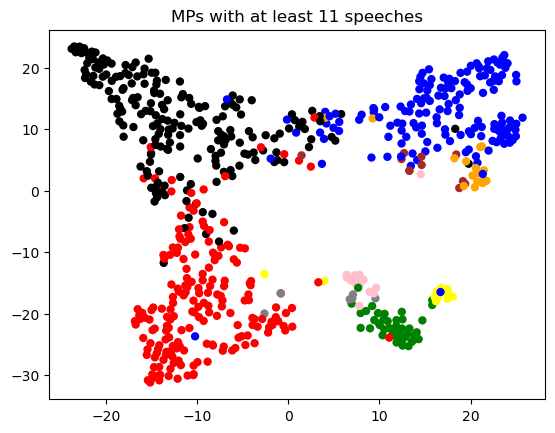

In [123]:
x = mp_prob['x']
y = mp_prob['y']

colors_map={0:'red',1:'black',2:'blue',3:'green',5:'orange',4:'yellow',6:'pink',8:'grey',7:'brown',9:'black'}
colors= [colors_map[color] for color in mp_prob['party']]

# plot
fig, ax = plt.subplots()

ax.scatter(x, y, c=colors,linewidth=0)

plt.title('MPs with at least 11 speeches')
plt.show()

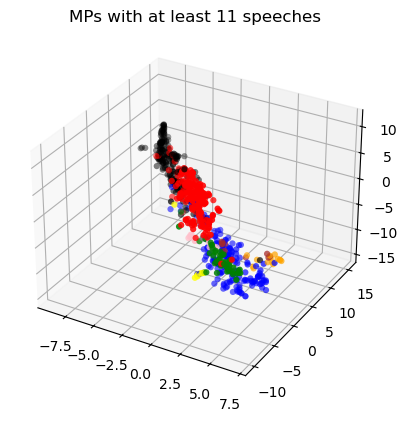

In [16]:
x = mp_probabilities['x']
y = mp_probabilities['y']
z = mp_probabilities['z']

colors_map={0:'red',1:'black',2:'blue',3:'green',5:'orange',4:'yellow',6:'pink',8:'grey',7:'brown',9:'black'}
colors= [colors_map[color] for color in mp_probabilities['party']]

# plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x, y, z, c=colors,linewidth=0)

plt.title('MPs with at least 11 speeches')
plt.show()

<IPython.core.display.Javascript object>


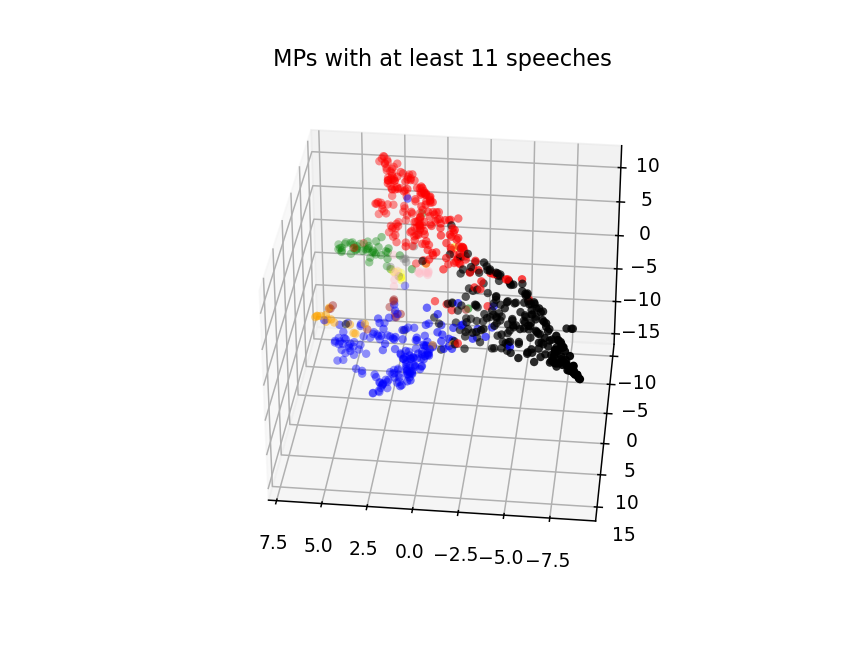

In [40]:
%matplotlib notebook
# plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x, y, z, c=colors,linewidth=0)

plt.title('MPs with at least 11 speeches')
plt.show()

In [41]:
x = mp_probabilities['x']
y = mp_probabilities['y']

colors_map={0:'red',1:'black',2:'blue',3:'green',5:'orange',4:'yellow',6:'pink',8:'grey',7:'brown',9:'black'}
colors= [colors_map[color] for color in mp_prob['party']]

# plot
fig, ax = plt.subplots()

ax.scatter(x, y, c=colors,linewidth=0)

plt.title('MPs with at least 11 speeches')
plt.show()

NameError: name 'mp_prob' is not defined

## Comparing predicted party with actual party per MP

*FOR ALL MPS*
|   party |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |
|--------:|----:|----:|----:|----:|----:|----:|----:|----:|
|       0 | 186 |  19 |   0 |   2 |   0 |   0 |   1 |   0 |
|       1 |   6 | 211 |   5 |   0 |   0 |   0 |   0 |   0 |
|       2 |   2 |  15 | 159 |   0 |   1 |   0 |   0 |   0 |
|       3 |   6 |   1 |   0 |  37 |   0 |   0 |   0 |   0 |
|       4 |   4 |   0 |   2 |   2 |   5 |   0 |   0 |   0 |
|       5 |   0 |   1 |   9 |   0 |   0 |   7 |   0 |   0 |
|       6 |   1 |   0 |   3 |   1 |   0 |   0 |  10 |   0 |
|       7 |   0 |   1 |   7 |   0 |   0 |   2 |   0 |   2 |
|       8 |   5 |   0 |   0 |   1 |   0 |   0 |   0 |   0 |


*EXCLUDING MPs with less than 11 speeches*

|   party |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |
|--------:|----:|----:|----:|----:|----:|----:|----:|----:|
|       0 | 169 |  18 |   0 |   1 |   0 |   0 |   0 |   0 |
|       1 |   5 | 188 |   5 |   0 |   0 |   0 |   0 |   0 |
|       2 |   2 |   9 | 138 |   0 |   1 |   0 |   0 |   0 |
|       3 |   5 |   0 |   0 |  36 |   0 |   0 |   0 |   0 |
|       4 |   3 |   0 |   2 |   2 |   5 |   0 |   0 |   0 |
|       5 |   0 |   1 |   8 |   0 |   0 |   7 |   0 |   0 |
|       6 |   1 |   0 |   3 |   1 |   0 |   0 |  10 |   0 |
|       7 |   0 |   1 |   7 |   0 |   0 |   2 |   0 |   1 |
|       8 |   5 |   0 |   0 |   1 |   0 |   0 |   0 |   0 |

##### Findings

> Most parties actually work well, only with STRONACH and PILZ it gets more difficult for the model to classify
> no MP was classified as PILZ and only two as STRONACH. We can also see that Parties are usually classified towards the >"same" political direction. Meaning the left parties are rather missclassified as other left parties and the right parties >are rather classified as other right parties. Also often the parties are missclassified with their predecessor party (if >they have one, like LIF and BZÖ for the FPÖ and PILZ for the Green Party). The BZÖ is an extreme example where most MPs got classified as FPÖ, not BZÖ.



In [15]:
only_s_to_n = mp_probabilities[mp_probabilities["party"]==0]
only_s_to_n = only_s_to_n[only_s_to_n['predicted_party']==6]
print(only_s_to_n.to_markdown())

| speaker        |        0 |         1 |         2 |        3 |         4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:---------------|---------:|----------:|----------:|---------:|----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Alexander Zach | 0.264245 | 0.0659577 | 0.0531116 | 0.231797 | 0.0300207 | 0.0127286 | 0.264532 | 0.0124956 | 0.0651119 |                 6 |       0 |


#### Missclassified MPs
###### SPÖ > NEOS

| speaker        |        0 |         1 |         2 |        3 |         4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:---------------|---------:|----------:|----------:|---------:|----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Alexander Zach | 0.264245 | 0.0659577 | 0.0531116 | 0.231797 | 0.0300207 | 0.0127286 | 0.264532 | 0.0124956 | 0.0651119 |                 6 |       0 |

> Alexander Zach is actually a member of the LIF, which for the elections 2006 cooperated with the SPÖ to win against a right wing majority. He was for practical reasons part of the SPÖ-Club but politically completely independent. His prediction as NEOS member is not to far away as he is being send to the ORF-board in the name of NEOS whos predecestor was LIF. 

In [16]:
only_s_to_g = mp_probabilities[mp_probabilities["party"]==0]
only_s_to_g = only_s_to_g[only_s_to_g['predicted_party']==3]
print(only_s_to_g.to_markdown())

| speaker       |        0 |         1 |        2 |        3 |          4 |          5 |          6 |          7 |           8 |   predicted_party |   party |
|:--------------|---------:|----------:|---------:|---------:|-----------:|-----------:|-----------:|-----------:|------------:|------------------:|--------:|
| Heinz Fischer | 0.275988 | 0.174291  | 0.119571 | 0.424422 | 0.00100884 | 0.00362767 | 0.00061303 | 0.00010416 | 0.000374149 |                 3 |       0 |
| Ulrike Sima   | 0.288933 | 0.0356114 | 0.155058 | 0.472308 | 0.00218008 | 0.0322092  | 0.00649202 | 0.00505115 | 0.00215763  |                 3 |       0 |


##### SPÖ > GRÜNE

| speaker       |        0 |         1 |        2 |        3 |          4 |          5 |          6 |           7 |          8 |   predicted_party |   party |
|:--------------|---------:|----------:|---------:|---------:|-----------:|-----------:|-----------:|------------:|-----------:|------------------:|--------:|
| Heinz Fischer | 0.221516 | 0.135838  | 0.14518  | 0.445491 | 0.0437853  | 0.00397594 | 0.00250451 | 0.000359772 | 0.00134918 |                 3 |       0 |
| Ulrike Sima   | 0.287023 | 0.0360455 | 0.157129 | 0.472083 | 0.00225448 | 0.0319281  | 0.00640891 | 0.0049895   | 0.00213847 |                 3 |       0 |

**Heinz Fischer**
> Regarding Heinz Fischer there are only two speeches with more then 30 words in the data set, because most of his speeches were held in the position of the president of the parliament or eben the president of Austria. Those speeches were labled one as GRÜNE and one as ÖVP. Thereof one speech is more organisational talking about something he had to respond to about an accusation of his organisational role as a president of the parliament. 

**Ulrike Sima**
> As for Ulrike Sima, she was member of the green student party as well as working for an enviromentalist NGO (Global 2000) so her association with the GRÜNE in the model is a very close reflection on the political backgroud she had when joining the SPÖ. 

In [17]:
s_to_vp = mp_probabilities[mp_probabilities["party"]==0]
s_to_vp = s_to_vp[s_to_vp['predicted_party']==1]
print(s_to_vp.to_markdown())

| speaker                |        0 |        1 |         2 |          3 |           4 |         5 |           6 |           7 |           8 |   predicted_party |   party |
|:-----------------------|---------:|---------:|----------:|-----------:|------------:|----------:|------------:|------------:|------------:|------------------:|--------:|
| Alois Stöger           | 0.37587  | 0.52417  | 0.0719186 | 0.00969949 | 0.000479166 | 0.010511  | 0.00438962  | 0.000789068 | 0.00217224  |                 1 |       0 |
| Andrea Gessl-Ranftl    | 0.416165 | 0.440942 | 0.065277  | 0.0296677  | 0.000930803 | 0.034216  | 0.002889    | 0.00782949  | 0.00208276  |                 1 |       0 |
| Christian Hursky       | 0.321331 | 0.461689 | 0.143429  | 0.0436398  | 0.000550147 | 0.0197077 | 0.00616326  | 0.00195162  | 0.00153818  |                 1 |       0 |
| Claudia Schmied        | 0.366202 | 0.581855 | 0.0162598 | 0.00966328 | 0.000275513 | 0.0164247 | 0.00566138  | 0.00206937  | 0.00158912  

| speaker                |        0 |        1 |         2 |          3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:-----------------------|---------:|---------:|----------:|-----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Alois Stöger           | 0.373255 | 0.527002 | 0.0722295 | 0.00936576 | 0.000462701 | 0.0103852  | 0.00438342  | 0.000751039 | 0.00216552  |                 1 |       0 |
| Andrea Gessl-Ranftl    | 0.417186 | 0.44375  | 0.061208  | 0.0301574  | 0.000779816 | 0.0342     | 0.00272501  | 0.00788696  | 0.00210744  |                 1 |       0 |
| Christian Hursky       | 0.321331 | 0.461689 | 0.143429  | 0.0436398  | 0.000550147 | 0.0197077  | 0.00616326  | 0.00195162  | 0.00153818  |                 1 |       0 |
| Claudia Schmied        | 0.362039 | 0.587959 | 0.0164666 | 0.00708319 | 0.000277335 | 0.0167181  | 0.00574421  | 0.00210954  | 0.00160305  |                 1 |       0 |
| Gerald Klug            | 0.385496 | 0.46194  | 0.134106  | 0.00987571 | 0.0004318   | 0.00354798 | 0.00102283  | 0.00290102  | 0.000678574 |                 1 |       0 |
| Gerhard Köfer          | 0.272508 | 0.383756 | 0.170433  | 0.00458932 | 0.000441485 | 0.151015   | 0.000904373 | 0.0157411   | 0.000612093 |                 1 |       0 |
| Harald Troch           | 0.344125 | 0.345507 | 0.154061  | 0.0771617  | 0.00275336  | 0.0398461  | 0.0210008   | 0.00315604  | 0.0123888   |                 1 |       0 |
| Johann Hechtl          | 0.354809 | 0.554298 | 0.0640444 | 0.00422928 | 0.000859262 | 0.0161093  | 0.00267273  | 0.00195093  | 0.00102641  |                 1 |       0 |
| Josef Auer             | 0.278141 | 0.291756 | 0.242425  | 0.0424681  | 0.00134857  | 0.0486358  | 0.0544203   | 0.0360982   | 0.00470605  |                 1 |       0 |
| Jürgen Schabhüttl      | 0.275253 | 0.571331 | 0.0953346 | 0.00566307 | 0.000278279 | 0.050147   | 0.000258984 | 0.00140711  | 0.000326534 |                 1 |       0 |
| Maria Berger           | 0.331375 | 0.496064 | 0.0331878 | 0.0392818  | 0.000880751 | 0.0920025  | 0.00388351  | 0.00166126  | 0.00166343  |                 1 |       0 |
| Michael Ehmann         | 0.387159 | 0.424353 | 0.109304  | 0.031801   | 0.00126268  | 0.0138315  | 0.0217763   | 0.00761611  | 0.00289602  |                 1 |       0 |
| Michael Schickhofer    | 0.372938 | 0.488151 | 0.077496  | 0.0263968  | 0.00093448  | 0.0157638  | 0.00507049  | 0.00891716  | 0.00433304  |                 1 |       0 |
| Norbert Darabos        | 0.267949 | 0.367548 | 0.279445  | 0.0412806  | 0.00290665  | 0.0335692  | 0.00523017  | 0.000915668 | 0.00115554  |                 1 |       0 |
| Peter Doskozil         | 0.139674 | 0.458184 | 0.373722  | 0.00961459 | 0.0006322   | 0.0123184  | 0.00222704  | 0.000811979 | 0.00281621  |                 1 |       0 |
| Philip Kucher          | 0.353483 | 0.4284   | 0.0614027 | 0.0565253  | 0.000913126 | 0.0255089  | 0.0324199   | 0.020567    | 0.0207804   |                 1 |       0 |
| Rudolf Hundstorfer     | 0.378939 | 0.432771 | 0.100149  | 0.0477299  | 0.000733779 | 0.0231575  | 0.0121342   | 0.00198273  | 0.00240268  |                 1 |       0 |
| Rudolf Plessl          | 0.328976 | 0.426374 | 0.155738  | 0.0286613  | 0.000897886 | 0.0230638  | 0.0101997   | 0.0174756   | 0.00861322  |                 1 |       0 |
| Sonja Steßl-Mühlbacher | 0.341061 | 0.441052 | 0.115709  | 0.0498143  | 0.00114389  | 0.0270463  | 0.0142253   | 0.00360402  | 0.00634412  |   

In [79]:
s_to_sp = mp_probabilities[mp_probabilities["party"]==0]
s_to_sp = s_to_sp[s_to_sp['predicted_party']==0]
print(s_to_sp.to_markdown())

| speaker                    |        0 |           1 |          2 |           3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------------|---------:|------------:|-----------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Alfred Gusenbauer          | 0.601207 | 0.23604     | 0.0836813  | 0.0502603   | 0.0125003   | 0.0109057   | 0.00192485  | 0.00201526  | 0.00146571  |                 0 |       0 |
| Andrea Kuntzl              | 0.456251 | 0.137818    | 0.103933   | 0.250093    | 0.00203445  | 0.0348536   | 0.00565289  | 0.00307985  | 0.00628435  |                 0 |       0 |
| Andreas Kollross           | 0.54882  | 0.0166188   | 0.0635353  | 0.202614    | 0.00208353  | 0.0156304   | 0.0471545   | 0.0331822   | 0.0703612   |                 0 |       0 |
| Andreas Schieder           | 0.518327 | 0.189275    | 0.101537   | 0.0884903   | 0.

#### SPÖ > SPÖ 

| speaker                    |        0 |           1 |          2 |           3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------------|---------:|------------:|-----------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Alfred Gusenbauer          | 0.601207 | 0.23604     | 0.0836813  | 0.0502603   | 0.0125003   | 0.0109057   | 0.00192485  | 0.00201526  | 0.00146571  |                 0 |       0 |
| Andrea Kuntzl              | 0.456251 | 0.137818    | 0.103933   | 0.250093    | 0.00203445  | 0.0348536   | 0.00565289  | 0.00307985  | 0.00628435  |                 0 |       0 |
| Andreas Kollross           | 0.54882  | 0.0166188   | 0.0635353  | 0.202614    | 0.00208353  | 0.0156304   | 0.0471545   | 0.0331822   | 0.0703612   |                 0 |       0 |
| Andreas Schieder           | 0.518327 | 0.189275    | 0.101537   | 0.0884903   | 0.00253118  | 0.0432206   | 0.0241586   | 0.013559    | 0.0189004   |                 0 |       0 |
| Angela Lueger              | 0.56676  | 0.180081    | 0.0893669  | 0.044627    | 0.00112602  | 0.0488803   | 0.0419864   | 0.0109761   | 0.0161954   |                 0 |       0 |
| Anita Fleckl               | 0.671709 | 0.178225    | 0.0493806  | 0.0549853   | 0.00212554  | 0.0320642   | 0.00175866  | 0.00695951  | 0.00279225  |                 0 |       0 |
| Anna Huber                 | 0.601255 | 0.178373    | 0.101467   | 0.0690382   | 0.0303551   | 0.0161533   | 0.000647794 | 0.00159811  | 0.00111278  |                 0 |       0 |
| Annemarie Reitsamer        | 0.565733 | 0.216134    | 0.132113   | 0.0348652   | 0.0458575   | 0.00312399  | 0.0010092   | 0.000598602 | 0.000565034 |                 0 |       0 |
| Anton Gaál                 | 0.673879 | 0.160695    | 0.117149   | 0.00675604  | 0.0284737   | 0.0119372   | 0.000594175 | 0.000302174 | 0.000213955 |                 0 |       0 |
| Anton Heinzl               | 0.541126 | 0.240026    | 0.155102   | 0.0206586   | 0.00163738  | 0.0343416   | 0.000601247 | 0.00599775  | 0.000508425 |                 0 |       0 |
| Anton Leikam               | 0.563293 | 0.212333    | 0.124709   | 0.0484342   | 0.0407198   | 0.009556    | 0.000347432 | 0.000280375 | 0.000326684 |                 0 |       0 |
| Arnold Grabner             | 0.646624 | 0.182956    | 0.128299   | 0.0155865   | 0.015382    | 0.00995246  | 0.000206347 | 0.000526925 | 0.000466162 |                 0 |       0 |
| Barbara Prammer            | 0.57522  | 0.140583    | 0.0577731  | 0.207367    | 0.00545129  | 0.0107437   | 0.000901915 | 0.000752676 | 0.00120701  |                 0 |       0 |
| Beate Schasching           | 0.646287 | 0.140662    | 0.11449    | 0.0556216   | 0.00390151  | 0.0287915   | 0.00675531  | 0.0022482   | 0.0012429   |                 0 |       0 |
| Bettina Stadlbauer         | 0.499203 | 0.123524    | 0.0962462  | 0.197471    | 0.00443499  | 0.0477982   | 0.0116628   | 0.00790878  | 0.0117506   |                 0 |       0 |
| Brigitte Ederer            | 0.616368 | 0.068683    | 0.0947746  | 0.0973129   | 0.118117    | 0.00401668  | 0.000199423 | 0.000139353 | 0.00038933  |                 0 |       0 |
| Brigitte Tegischer         | 0.520978 | 0.36414     | 0.0353406  | 0.0339059   | 0.0439221   | 0.000451793 | 0.000746124 | 0.000298905 | 0.000217133 |                 0 |       0 |
| Brunhilde Fuchs            | 0.681291 | 0.26923     | 0.0284889  | 0.00152829  | 0.0191012   | 0.000129939 | 7.48577e-05 | 8.27723e-05 | 7.26993e-05 |                 0 |       0 |
| Brunhilde Plank            | 0.698296 | 0.0354507   | 0.0746708  | 0.176805    | 0.00123772  | 0.00610477  | 0.00508823  | 0.00111343  | 0.00123388  |                 0 |       0 |
| Caspar Einem               | 0.596153 | 0.281019    | 0.0499375  | 0.0528155   | 0.00973776  | 0.00804789  | 0.00120009  | 0.000424465 | 0.000664619 |                 0 |       0 |
| Christa Krammer            | 0.527141 | 0.260004    | 0.0722672  | 0.0487698   | 0.0866016   | 0.0012195   | 0.00168642  | 0.00197809  | 0.000332219 |                 0 |       0 |
| Christian Faul             | 0.593296 | 0.0833282   | 0.211902   | 0.0355322   | 0.0032266   | 0.061474    | 0.00284137  | 0.00708124  | 0.00131885  |                 0 |       0 |
| Christian Füller           | 0.506214 | 0.373737    | 0.0666411  | 0.0311586   | 0.00375779  | 0.0119418   | 0.00268123  | 0.00293302  | 0.000934844 |                 0 |       0 |
| Christian Kern             | 0.497757 | 0.252628    | 0.0606125  | 0.0930707   | 0.0018346   | 0.0101232   | 0.04613     | 0.0155421   | 0.0223021   |                 0 |       0 |
| Christian Kovacevic        | 0.36337  | 0.167923    | 0.166043   | 0.0985535   | 0.00464611  | 0.0290661   | 0.0641579   | 0.0422132   | 0.0640273   |                 0 |       0 |
| Christian Puswald          | 0.623292 | 0.0662742   | 0.167424   | 0.108896    | 0.00397008  | 0.0212679   | 0.00185665  | 0.00562038  | 0.00139957  |                 0 |       0 |
| Christine Lapp             | 0.604356 | 0.181033    | 0.0814347  | 0.0673736   | 0.00109886  | 0.0491335   | 0.00165485  | 0.0115309   | 0.00238402  |                 0 |       0 |
| Christine Muttonen         | 0.594824 | 0.138307    | 0.0544859  | 0.161229    | 0.00593303  | 0.0138124   | 0.00869961  | 0.00741303  | 0.015297    |                 0 |       0 |
| Christoph Matznetter       | 0.481214 | 0.2333      | 0.106506   | 0.107021    | 0.00523226  | 0.0239335   | 0.0210963   | 0.0184553   | 0.00324148  |                 0 |       0 |
| Cornelia Ecker             | 0.501538 | 0.259714    | 0.0752732  | 0.0469379   | 0.00307243  | 0.0225258   | 0.0313615   | 0.0391174   | 0.0204593   |                 0 |       0 |
| Dieter Antoni              | 0.688368 | 0.151522    | 0.0888231  | 0.0253837   | 0.0363146   | 0.00754936  | 0.00090441  | 0.000601311 | 0.000533992 |                 0 |       0 |
| Dietmar Hoscher            | 0.492722 | 0.103347    | 0.165448   | 0.175037    | 0.0132384   | 0.0337215   | 0.0115492   | 0.00365802  | 0.00127914  |                 0 |       0 |
| Dietmar Keck               | 0.397987 | 0.239738    | 0.211784   | 0.0568136   | 0.00157239  | 0.0711806   | 0.00606215  | 0.0106716   | 0.00419052  |                 0 |       0 |
| Doris Bures                | 0.635176 | 0.210548    | 0.0695038  | 0.0583418   | 0.00861472  | 0.0148615   | 0.00156236  | 0.000664536 | 0.000727386 |                 0 |       0 |
| Doris Margreiter           | 0.479755 | 0.113699    | 0.0698003  | 0.089499    | 0.00302542  | 0.0189867   | 0.0895234   | 0.0281914   | 0.10752     |                 0 |       0 |
| Eleonora Hostasch          | 0.883179 | 0.0874016   | 0.0213463  | 0.00414677  | 0.00305334  | 0.000537646 | 0.000147381 | 0.000130081 | 5.82127e-05 |                 0 |       0 |
| Elisabeth Feichtinger      | 0.770529 | 0.12478     | 0.0029109  | 0.0475992   | 0.000389359 | 0.050298    | 0.000904358 | 0.000365594 | 0.00222332  |                 0 |       0 |
| Elisabeth Grossmann        | 0.469323 | 0.268945    | 0.07897    | 0.127876    | 0.00447453  | 0.0324764   | 0.00579051  | 0.00765287  | 0.00449189  |                 0 |       0 |
| Elisabeth Hakel            | 0.415986 | 0.298393    | 0.0772641  | 0.085749    | 0.00140038  | 0.0335144   | 0.0623198   | 0.0093582   | 0.0160154   |                 0 |       0 |
| Elisabeth Hlavac           | 0.583007 | 0.231761    | 0.0676154  | 0.062599    | 0.0320059   | 0.0183972   | 0.00262588  | 0.00100105  | 0.000987449 |                 0 |       0 |
| Elisabeth Pittermann       | 0.440242 | 0.314617    | 0.136085   | 0.0437598   | 0.0372946   | 0.00920771  | 0.00762464  | 0.00727851  | 0.00389076  |                 0 |       0 |
| Elmar Mayer                | 0.413598 | 0.300852    | 0.107549   | 0.0533596   | 0.00277392  | 0.0642793   | 0.0300759   | 0.0185323   | 0.00898053  |                 0 |       0 |
| Emmerich Schwemlein        | 0.653553 | 0.161255    | 0.101097   | 0.057476    | 0.0198538   | 0.00441389  | 0.00119782  | 0.000328238 | 0.000825121 |                 0 |       0 |
| Erhard Koppler             | 0.634452 | 0.290421    | 0.0706465  | 0.00251537  | 0.00123131  | 0.000405959 | 5.00155e-05 | 0.000209033 | 6.86859e-05 |                 0 |       0 |
| Erika Scharer              | 0.783451 | 0.0375839   | 0.0250711  | 0.120392    | 0.00336641  | 0.0253794   | 0.00159775  | 0.00154914  | 0.00160962  |                 0 |       0 |
| Erwin Buchinger            | 0.642407 | 0.267236    | 0.0462926  | 0.0218458   | 0.000160716 | 0.0212171   | 0.000240621 | 0.000266371 | 0.000333701 |                 0 |       0 |
| Erwin Kaipel               | 0.594648 | 0.23381     | 0.102751   | 0.0213452   | 0.00396047  | 0.0398595   | 0.00126623  | 0.00173531  | 0.000624533 |                 0 |       0 |
| Erwin Niederwieser         | 0.507197 | 0.170941    | 0.10119    | 0.188295    | 0.0154294   | 0.0114268   | 0.00320627  | 0.00060094  | 0.00171331  |                 0 |       0 |
| Erwin Preiner              | 0.465945 | 0.397351    | 0.0618465  | 0.0408841   | 0.0013342   | 0.0105686   | 0.00401315  | 0.0108129   | 0.00724444  |                 0 |       0 |
| Erwin Spindelberger        | 0.488129 | 0.224089    | 0.146307   | 0.053867    | 0.0013117   | 0.0634246   | 0.00857872  | 0.0120158   | 0.00227693  |                 0 |       0 |
| Ewald Nowotny              | 0.597982 | 0.234669    | 0.0639348  | 0.07139     | 0.0291693   | 0.00155564  | 0.000306254 | 0.000844677 | 0.000147904 |                 0 |       0 |
| Ewald Sacher               | 0.503088 | 0.320436    | 0.110538   | 0.0102094   | 0.00156372  | 0.0457582   | 0.000742859 | 0.00726285  | 0.000400437 |                 0 |       0 |
| Franz Hums                 | 0.728987 | 0.193898    | 0.0593117  | 0.00742581  | 0.00781123  | 0.00173763  | 0.000247407 | 0.000495226 | 8.60226e-05 |                 0 |       0 |
| Franz Kirchgatterer        | 0.523569 | 0.380029    | 0.0728908  | 0.00838307  | 0.000806988 | 0.0100404   | 0.0010901   | 0.0024986   | 0.000691941 |                 0 |       0 |
| Franz Riepl                | 0.64511  | 0.160607    | 0.0984601  | 0.0384208   | 0.0049051   | 0.0422712   | 0.00624177  | 0.00350788  | 0.000476275 |                 0 |       0 |
| Franz Vranitzky            | 0.642321 | 0.224987    | 0.0918916  | 0.0101757   | 0.0270313   | 0.00163197  | 0.00132517  | 0.000290013 | 0.000345726 |                 0 |       0 |
| Friedrich Verzetnitsch     | 0.69706  | 0.118833    | 0.0856567  | 0.0670539   | 0.00663409  | 0.0196086   | 0.00281959  | 0.00163527  | 0.000698812 |                 0 |       0 |
| Fritz Verzetnitsch         | 0.721929 | 0.155439    | 0.0740555  | 0.00507981  | 0.0427798   | 0.000359544 | 0.000135872 | 0.000126419 | 9.4947e-05  |                 0 |       0 |
| Gabriele Binder-Maier      | 0.71423  | 0.16621     | 0.0565968  | 0.0392175   | 0.00515622  | 0.0161855   | 0.00124614  | 0.000812223 | 0.000345506 |                 0 |       0 |
| Gabriele Heinisch-Hosek    | 0.622334 | 0.21918     | 0.0571652  | 0.0678711   | 0.00201201  | 0.0173702   | 0.00636735  | 0.00454499  | 0.00315511  |                 0 |       0 |
| Georg Oberhaidinger        | 0.570833 | 0.183645    | 0.121264   | 0.0650746   | 0.0342274   | 0.0186292   | 0.000638457 | 0.00503097  | 0.000657088 |                 0 |       0 |
| Gerald Tychtl              | 0.436745 | 0.2712      | 0.115537   | 0.0632828   | 0.111707    | 0.000933017 | 0.000259056 | 0.000188148 | 0.000148514 |                 0 |       0 |
| Gerfried Müller            | 0.475946 | 0.385314    | 0.114666   | 0.013051    | 0.00887642  | 0.00113814  | 0.000297578 | 0.000581057 | 0.000129413 |                 0 |       0 |
| Gerhard Reheis             | 0.583275 | 0.114225    | 0.162471   | 0.107289    | 0.00289701  | 0.0227876   | 0.00174059  | 0.00243557  | 0.00287956  |                 0 |       0 |
| Gerhard Steier             | 0.601707 | 0.28027     | 0.0550861  | 0.0313122   | 0.00269128  | 0.0158215   | 0.00133374  | 0.00781749  | 0.00396071  |                 0 |       0 |
| Gertraud Knoll             | 0.426391 | 0.332082    | 0.00758472 | 0.20579     | 0.000455489 | 0.0163415   | 0.00200808  | 0.000318022 | 0.00902924  |                 0 |       0 |
| Gisela Wurm                | 0.559212 | 0.164142    | 0.110243   | 0.0930075   | 0.00876224  | 0.0460477   | 0.0120741   | 0.00204873  | 0.0044626   |                 0 |       0 |
| Günter Kiermaier           | 0.450519 | 0.297166    | 0.179477   | 0.0232125   | 0.0280314   | 0.0100503   | 0.00227407  | 0.00825768  | 0.00101141  |                 0 |       0 |
| Günther Kräuter            | 0.481679 | 0.152686    | 0.105716   | 0.169204    | 0.0137489   | 0.0679258   | 0.00261469  | 0.00574383  | 0.000682586 |                 0 |       0 |
| Hannelore Buder            | 0.540385 | 0.280377    | 0.129403   | 0.00943688  | 0.0365844   | 0.00279931  | 0.000316063 | 0.000565926 | 0.000132541 |                 0 |       0 |
| Hannes Bauer               | 0.599056 | 0.263274    | 0.0838386  | 0.0171144   | 0.00151807  | 0.0327615   | 0.000700853 | 0.00157526  | 0.000161666 |                 0 |       0 |
| Hannes Fazekas             | 0.476486 | 0.372664    | 0.0867003  | 0.0124981   | 0.000965887 | 0.0408901   | 0.00417798  | 0.00520901  | 0.000408887 |                 0 |       0 |
| Hannes Weninger            | 0.503793 | 0.327546    | 0.0513295  | 0.0737354   | 0.00168387  | 0.0198398   | 0.0128492   | 0.00409168  | 0.00513147  |                 0 |       0 |
| Hedwig Wechner             | 0.460194 | 0.286313    | 0.250734   | 0.000524098 | 0.000156682 | 0.00165238  | 9.48079e-05 | 0.000205462 | 0.000125989 |                 0 |       0 |
| Heidemaria Onodi           | 0.748254 | 0.129355    | 0.0972068  | 0.00578775  | 0.0180643   | 0.000966056 | 8.25406e-05 | 0.000148795 | 0.000134916 |                 0 |       0 |
| Heidrun Silhavy            | 0.725843 | 0.0956161   | 0.0676226  | 0.0609828   | 0.0164167   | 0.0267224   | 0.00364783  | 0.00184502  | 0.00130402  |                 0 |       0 |
| Heidrun Walther            | 0.507731 | 0.193726    | 0.151528   | 0.0616029   | 0.0155031   | 0.0548768   | 0.00367837  | 0.0101394   | 0.00121489  |                 0 |       0 |
| Heinz Gradwohl             | 0.691219 | 0.104118    | 0.111926   | 0.0444599   | 0.0144761   | 0.0327954   | 0.000301888 | 0.000481221 | 0.000222898 |                 0 |       0 |
| Helga Konrad               | 0.754573 | 0.094285    | 0.0130868  | 0.0716708   | 0.0599587   | 0.000638251 | 0.0047143   | 0.000352471 | 0.000720464 |                 0 |       0 |
| Helmut Dietachmayr         | 0.684228 | 0.163038    | 0.0976203  | 0.0355162   | 0.0127341   | 0.0059144   | 0.000367622 | 0.000390506 | 0.000190463 |                 0 |       0 |
| Herbert Kaufmann           | 0.419714 | 0.301572    | 0.126545   | 0.0675258   | 0.0808208   | 0.00136167  | 0.00100073  | 0.00108143  | 0.000378742 |                 0 |       0 |
| Hermann Krist              | 0.569498 | 0.254969    | 0.0832131  | 0.0364415   | 0.00385636  | 0.0360933   | 0.00600448  | 0.00761132  | 0.00231296  |                 0 |       0 |
| Hermann Lipitsch           | 0.399943 | 0.389575    | 0.133974   | 0.0235832   | 0.000322873 | 0.0340507   | 0.00397865  | 0.012965    | 0.00160711  |                 0 |       0 |
| Hubert Kuzdas              | 0.429942 | 0.398638    | 0.085517   | 0.0308754   | 0.00206874  | 0.0342783   | 0.00842896  | 0.00806818  | 0.00218313  |                 0 |       0 |
| Ilse Mertel                | 0.65149  | 0.182235    | 0.064037   | 0.0785401   | 0.0163795   | 0.00557558  | 0.000722431 | 0.000486677 | 0.000534318 |                 0 |       0 |
| Inge Jäger                 | 0.522358 | 0.189693    | 0.101126   | 0.111962    | 0.0576299   | 0.0075201   | 0.0037379   | 0.00402733  | 0.00194437  |                 0 |       0 |
| Irene Hochstetter-Lackner  | 0.564749 | 0.0872875   | 0.0688254  | 0.127061    | 0.000599794 | 0.0476988   | 0.0134797   | 0.0533836   | 0.0369159   |                 0 |       0 |
| Irene Szep                 | 0.35431  | 0.236288    | 0.0853276  | 0.00305099  | 0.00186089  | 0.00716249  | 0.299276    | 0.00679709  | 0.00592574  |                 0 |       0 |
| Irmtraut Karlsson          | 0.411684 | 0.233061    | 0.138691   | 0.133072    | 0.0812284   | 0.00085074  | 0.000369401 | 0.000601439 | 0.000442114 |                 0 |       0 |
| Jan Krainer                | 0.459774 | 0.116924    | 0.117849   | 0.200513    | 0.00129645  | 0.0607525   | 0.0296659   | 0.00625952  | 0.00696547  |                 0 |       0 |
| Johann Hell                | 0.639015 | 0.283053    | 0.0391633  | 0.0112094   | 0.00130583  | 0.0170368   | 0.00349701  | 0.00468163  | 0.0010371   |                 0 |       0 |
| Johann Maier               | 0.447513 | 0.312225    | 0.18392    | 0.0370825   | 0.00430733  | 0.0126406   | 0.000806548 | 0.000998221 | 0.000507598 |                 0 |       0 |
| Johann Moser               | 0.566334 | 0.0573629   | 0.170158   | 0.153395    | 0.0133519   | 0.027212    | 0.00550892  | 0.00472565  | 0.00195139  |                 0 |       0 |
| Johann Stippel             | 0.687222 | 0.225028    | 0.0515545  | 0.00837394  | 0.0252664   | 0.00101302  | 0.00076305  | 0.000570943 | 0.000208698 |                 0 |       0 |
| Johannes Jarolim           | 0.44463  | 0.194439    | 0.154803   | 0.102159    | 0.022649    | 0.0476937   | 0.0211638   | 0.00583439  | 0.00662785  |                 0 |       0 |
| Josef Broukal              | 0.553578 | 0.0776082   | 0.134622   | 0.195241    | 0.00321112  | 0.021761    | 0.00670222  | 0.00319046  | 0.00408708  |                 0 |       0 |
| Josef Cap                  | 0.368399 | 0.151651    | 0.158652   | 0.185254    | 0.0211655   | 0.0783019   | 0.0162887   | 0.015794    | 0.00449399  |                 0 |       0 |
| Josef Edler                | 0.815298 | 0.105955    | 0.0282391  | 0.0154471   | 0.0321162   | 0.00200429  | 0.000472756 | 0.000326538 | 0.000141781 |                 0 |       0 |
| Josef Horn                 | 0.836099 | 0.0615398   | 0.0489461  | 0.00390147  | 0.000762751 | 0.0470325   | 0.000597894 | 0.000877271 | 0.000243132 |                 0 |       0 |
| Josef Muchitsch            | 0.506025 | 0.24156     | 0.102463   | 0.0306193   | 0.00244964  | 0.0679339   | 0.0322483   | 0.00804193  | 0.00865837  |                 0 |       0 |
| Josef Ostermayer           | 0.506698 | 0.370909    | 0.0363385  | 0.0632216   | 0.00274096  | 0.00388645  | 0.00704541  | 0.00805088  | 0.00110953  |                 0 |       0 |
| Jörg Leichtfried           | 0.484448 | 0.210725    | 0.108785   | 0.0509933   | 0.00102268  | 0.0611728   | 0.0310077   | 0.0298881   | 0.0219574   |                 0 |       0 |
| Karin Greiner              | 0.536688 | 0.279014    | 0.071726   | 0.0340136   | 0.0037635   | 0.0187119   | 0.0242184   | 0.0260126   | 0.00585125  |                 0 |       0 |
| Karl Dobnigg               | 0.791088 | 0.08999     | 0.0684946  | 0.0276471   | 0.00231174  | 0.0161824   | 0.00159884  | 0.00195535  | 0.000732263 |                 0 |       0 |
| Karl Schlögl               | 0.569174 | 0.356513    | 0.0336575  | 0.0312335   | 0.00398562  | 0.00472295  | 0.000251319 | 0.000265414 | 0.000196049 |                 0 |       0 |
| Katharina Kucharowits      | 0.49103  | 0.191218    | 0.0137226  | 0.20942     | 0.00332802  | 0.00508785  | 0.0267708   | 0.0228706   | 0.0365513   |                 0 |       0 |
| Katharina Pfeffer          | 0.567937 | 0.275563    | 0.0942398  | 0.0336043   | 0.00778837  | 0.0174618   | 0.00129168  | 0.00139398  | 0.000719875 |                 0 |       0 |
| Klaudia Friedl             | 0.69249  | 0.118598    | 0.0307664  | 0.0480427   | 0.000520484 | 0.0434034   | 0.00388406  | 0.0471797   | 0.0151158   |                 0 |       0 |
| Konrad Antoni              | 0.635239 | 0.24942     | 0.0524284  | 0.0201578   | 0.00170215  | 0.0295826   | 0.00524302  | 0.00157744  | 0.00464905  |                 0 |       0 |
| Kurt Eder                  | 0.584474 | 0.110165    | 0.19714    | 0.0427972   | 0.0144662   | 0.0477791   | 0.00138645  | 0.0012949   | 0.000497559 |                 0 |       0 |
| Kurt Gartlehner            | 0.541674 | 0.27685     | 0.0877786  | 0.0550434   | 0.0135206   | 0.0144125   | 0.00598293  | 0.0040104   | 0.000727594 |                 0 |       0 |
| Kurt Gaßner                | 0.45641  | 0.10615     | 0.221874   | 0.114881    | 0.00579891  | 0.0832117   | 0.00261964  | 0.00850437  | 0.000550439 |                 0 |       0 |
| Kurt Heindl                | 0.401587 | 0.367658    | 0.101171   | 0.057085    | 0.0645523   | 0.00541912  | 0.000764488 | 0.00114623  | 0.000616499 |                 0 |       0 |
| Kurt Wallner               | 0.70065  | 0.178505    | 0.0857416  | 0.0237798   | 0.00889325  | 0.000707527 | 0.00151093  | 0.000103724 | 0.000108911 |                 0 |       0 |
| Laura Rudas                | 0.691363 | 0.145205    | 0.0457074  | 0.0678229   | 0.00107755  | 0.0216892   | 0.0156358   | 0.00858431  | 0.00291472  |                 0 |       0 |
| Ludmilla Parfuss           | 0.623859 | 0.211409    | 0.0802885  | 0.0533178   | 0.0160249   | 0.00579313  | 0.00113233  | 0.0064444   | 0.00173108  |                 0 |       0 |
| Manfred Lackner            | 0.693303 | 0.103904    | 0.0870653  | 0.0853727   | 0.00667237  | 0.0196316   | 0.00146737  | 0.000801215 | 0.00178182  |                 0 |       0 |
| Maria Holzleitner          | 0.49731  | 0.109278    | 0.0247008  | 0.173056    | 0.00921887  | 0.00740402  | 0.0737449   | 0.0120882   | 0.0931998   |                 0 |       0 |
| Maria Kubitschek           | 0.61264  | 0.134132    | 0.0833693  | 0.151589    | 0.00982011  | 0.00166884  | 0.00356441  | 0.0010546   | 0.00216152  |                 0 |       0 |
| Marianne Gusenbauer-Jäger  | 0.459129 | 0.400663    | 0.102418   | 0.0108857   | 0.00047018  | 0.0180544   | 0.00125852  | 0.00606334  | 0.0010579   |                 0 |       0 |
| Marianne Hagenhofer        | 0.523381 | 0.281734    | 0.104908   | 0.0416646   | 0.0224664   | 0.0172786   | 0.00247718  | 0.00494333  | 0.00114685  |                 0 |       0 |
| Mario Lindner              | 0.669614 | 0.0619055   | 0.100348   | 0.0979449   | 0.00197929  | 0.00541985  | 0.0205728   | 0.00386196  | 0.0383544   |                 0 |       0 |
| Markus Vogl                | 0.460082 | 0.283674    | 0.069386   | 0.053303    | 0.0021347   | 0.0234169   | 0.0635286   | 0.0282831   | 0.016192    |                 0 |       0 |
| Matthias Achs              | 0.559861 | 0.389671    | 0.0209526  | 0.004728    | 0.0222861   | 0.00156056  | 0.000450654 | 0.000286241 | 0.000204408 |                 0 |       0 |
| Maurice Androsch           | 0.391893 | 0.125291    | 0.164996   | 0.0793434   | 0.00434262  | 0.11778     | 0.0653783   | 0.0308491   | 0.0201268   |                 0 |       0 |
| Maximilian Unterrainer     | 0.399968 | 0.292627    | 0.104913   | 0.0469262   | 0.00716877  | 0.0199475   | 0.0358323   | 0.0689892   | 0.0236278   |                 0 |       0 |
| Melanie Erasim             | 0.719128 | 0.0967727   | 0.0702177  | 0.0860515   | 0.00340085  | 0.00404975  | 0.00519594  | 0.0132506   | 0.00193345  |                 0 |       0 |
| Melitta Trunk              | 0.686136 | 0.0594013   | 0.0547274  | 0.169175    | 0.00105907  | 0.0235374   | 0.00439125  | 0.000490758 | 0.00108172  |                 0 |       0 |
| Muna Duzdar                | 0.578462 | 0.0577007   | 0.111211   | 0.12457     | 0.00307611  | 0.048368    | 0.0150265   | 0.0261435   | 0.0354418   |                 0 |       0 |
| Nurten Yilmaz              | 0.511338 | 0.237971    | 0.0982604  | 0.0712671   | 0.00201926  | 0.012823    | 0.0446907   | 0.009813    | 0.0118183   |                 0 |       0 |
| Otmar Brix                 | 0.613734 | 0.137434    | 0.18879    | 0.0334395   | 0.0113295   | 0.0127226   | 0.000327867 | 0.00194509  | 0.000277734 |                 0 |       0 |
| Otto Pendl                 | 0.419406 | 0.339859    | 0.128613   | 0.0223915   | 0.00219172  | 0.0663755   | 0.00226867  | 0.018055    | 0.000838518 |                 0 |       0 |
| Pamela Rendi-Wagner        | 0.487557 | 0.154187    | 0.0550673  | 0.109276    | 0.00175014  | 0.0428929   | 0.0363963   | 0.0352139   | 0.0776594   |                 0 |       0 |
| Peter Keppelmüller         | 0.494661 | 0.181061    | 0.172579   | 0.110048    | 0.0269032   | 0.0116997   | 0.000498813 | 0.00226633  | 0.000283449 |                 0 |       0 |
| Peter Kostelka             | 0.418753 | 0.238335    | 0.138562   | 0.13252     | 0.050327    | 0.0187159   | 0.000931476 | 0.000754208 | 0.00110131  |                 0 |       0 |
| Peter Marizzi              | 0.560705 | 0.205071    | 0.151427   | 0.0350369   | 0.00375587  | 0.0402764   | 0.000634535 | 0.00290012  | 0.000193093 |                 0 |       0 |
| Peter Schieder             | 0.419047 | 0.233877    | 0.123083   | 0.167141    | 0.0304629   | 0.0231389   | 0.00194505  | 0.000397504 | 0.000906979 |                 0 |       0 |
| Peter Stauber              | 0.638278 | 0.220077    | 0.106253   | 0.00473983  | 0.000357508 | 0.028934    | 0.000347563 | 0.00077684  | 0.000237232 |                 0 |       0 |
| Peter Wittmann             | 0.322892 | 0.221165    | 0.279365   | 0.0647521   | 0.00314113  | 0.078471    | 0.0190012   | 0.00513627  | 0.00607724  |                 0 |       0 |
| Petra Bayr                 | 0.418408 | 0.127059    | 0.0992283  | 0.280203    | 0.00161611  | 0.0178285   | 0.0305178   | 0.00728721  | 0.0178521   |                 0 |       0 |
| Petra Wimmer               | 0.542926 | 0.175651    | 0.0322457  | 0.171394    | 0.000550168 | 0.0380377   | 0.00107541  | 0.0328216   | 0.00529852  |                 0 |       0 |
| Rainer Wimmer              | 0.746481 | 0.134736    | 0.0674481  | 0.0358726   | 0.00223003  | 0.00610355  | 0.00105193  | 0.00569876  | 0.000378353 |                 0 |       0 |
| Reinhold Einwallner        | 0.472483 | 0.095456    | 0.0701153  | 0.142072    | 0.00273457  | 0.0874514   | 0.0619094   | 0.0357358   | 0.0320417   |                 0 |       0 |
| Renate Csörgits            | 0.798755 | 0.117094    | 0.0465728  | 0.0170021   | 0.00315054  | 0.014317    | 0.00190268  | 0.000696032 | 0.000510137 |                 0 |       0 |
| Renate Gruber              | 0.389033 | 0.300895    | 0.116934   | 0.0751161   | 0.000366183 | 0.0968487   | 0.00463839  | 0.0112891   | 0.00487946  |                 0 |       0 |
| Richard Leutner            | 0.724465 | 0.0510471   | 0.051669   | 0.147609    | 0.00275235  | 0.0147303   | 0.0036932   | 0.00322623  | 0.000807732 |                 0 |       0 |
| Robert Elmecker            | 0.617204 | 0.274976    | 0.0475162  | 0.0207806   | 0.035947    | 0.00300578  | 0.000180805 | 0.000195515 | 0.00019475  |                 0 |       0 |
| Robert Laimer              | 0.637772 | 0.155492    | 0.0903589  | 0.0653088   | 0.00299317  | 0.00217357  | 0.00151716  | 0.00574471  | 0.0386402   |                 0 |       0 |
| Robert Rada                | 0.516041 | 0.259474    | 0.113969   | 0.0726497   | 0.00924976  | 0.0245116   | 0.00224421  | 0.00109069  | 0.00076958  |                 0 |       0 |
| Robert Sigl                | 0.676191 | 0.275945    | 0.0367835  | 0.0065247   | 0.00105726  | 0.00189528  | 0.00102192  | 0.000416316 | 0.000165407 |                 0 |       0 |
| Rosa Lohfeyer              | 0.654023 | 0.272721    | 0.0427516  | 0.0133603   | 0.000394288 | 0.0142314   | 0.000741524 | 0.000954333 | 0.000822489 |                 0 |       0 |
| Rosemarie Schönpass        | 0.681724 | 0.171456    | 0.0574092  | 0.0370089   | 0.00136675  | 0.0452237   | 0.00204142  | 0.002269    | 0.00150132  |                 0 |       0 |
| Rudolf Buchmayr            | 0.397263 | 0.369287    | 0.114522   | 0.0457884   | 0.00210688  | 0.0267567   | 0.0190972   | 0.0211535   | 0.00402511  |                 0 |       0 |
| Rudolf Edlinger            | 0.681813 | 0.204742    | 0.0637542  | 0.0306532   | 0.0167804   | 0.00161442  | 0.000234198 | 0.00027072  | 0.000138104 |                 0 |       0 |
| Rudolf Nürnberger          | 0.805163 | 0.0577579   | 0.092338   | 0.00857066  | 0.0145614   | 0.0186562   | 0.000501688 | 0.0019506   | 0.000500663 |                 0 |       0 |
| Rudolf Parnigoni           | 0.682411 | 0.137582    | 0.087265   | 0.0431458   | 0.0191194   | 0.024227    | 0.00301133  | 0.00171734  | 0.00152126  |                 0 |       0 |
| Rudolf Scholten            | 0.539547 | 0.16861     | 0.0300695  | 0.156262    | 0.103761    | 0.000946433 | 0.000294109 | 0.000274705 | 0.000235195 |                 0 |       0 |
| Ruth Becher                | 0.533149 | 0.247569    | 0.0940588  | 0.034078    | 0.00175422  | 0.0500363   | 0.0170023   | 0.0132067   | 0.00914564  |                 0 |       0 |
| Sabine Oberhauser          | 0.551025 | 0.220914    | 0.100826   | 0.0616832   | 0.00234228  | 0.0337302   | 0.0159908   | 0.00990874  | 0.00357986  |                 0 |       0 |
| Sabine Schatz              | 0.522164 | 0.0921681   | 0.034772   | 0.113279    | 0.0113263   | 0.0128835   | 0.0517338   | 0.0019144   | 0.159759    |                 0 |       0 |
| Selma Yildirim             | 0.638158 | 0.0902695   | 0.0869967  | 0.0956641   | 0.00075596  | 0.00738609  | 0.028927    | 0.00357749  | 0.0482655   |                 0 |       0 |
| Silvia Sandler             | 0.410044 | 0.0527999   | 0.166935   | 0.186394    | 0.00293249  | 0.100876    | 0.0277587   | 0.0156177   | 0.0366422   |                 0 |       0 |
| Sonja Ablinger             | 0.453561 | 0.16584     | 0.0513652  | 0.282577    | 0.0236094   | 0.00928991  | 0.00614306  | 0.0015582   | 0.00605643  |                 0 |       0 |
| Sonja Hammerschmid         | 0.503667 | 0.286691    | 0.0469928  | 0.0561201   | 0.0017411   | 0.00807286  | 0.052816    | 0.0218343   | 0.0220653   |                 0 |       0 |
| Sophie Bauer               | 0.867296 | 0.0998927   | 0.0161069  | 0.00263567  | 0.00681819  | 0.00682409  | 0.000140899 | 0.000141422 | 0.000143844 |                 0 |       0 |
| Stefan Prähauser           | 0.444927 | 0.253689    | 0.215248   | 0.0266371   | 0.00330128  | 0.0403682   | 0.00155736  | 0.0136365   | 0.000635876 |                 0 |       0 |
| Sylvia Prettenthaler       | 0.584558 | 0.000917723 | 0.0243165  | 0.384735    | 0.00332179  | 0.00145604  | 0.000104535 | 0.000186595 | 0.000404336 |                 0 |       0 |
| Sylvia Rinner              | 0.43631  | 0.394034    | 0.072049   | 0.00988702  | 0.00213174  | 0.0820179   | 0.00144285  | 0.00136518  | 0.00076258  |                 0 |       0 |
| Thomas Drozda              | 0.339758 | 0.236822    | 0.0929691  | 0.0654557   | 0.00397315  | 0.00623186  | 0.163904    | 0.0245549   | 0.0663314   |                 0 |       0 |
| Ulrike Königsberger-Ludwig | 0.637909 | 0.175171    | 0.0500244  | 0.0746727   | 0.000553672 | 0.0276229   | 0.00765868  | 0.0156434   | 0.0107435   |                 0 |       0 |
| Uwe Feichtinger            | 0.419733 | 0.298162    | 0.121127   | 0.0701229   | 0.00251743  | 0.0120961   | 0.0453405   | 0.00988008  | 0.0210209   |                 0 |       0 |
| Verena Dunst               | 0.525352 | 0.257301    | 0.141803   | 0.0175011   | 0.0525362   | 0.00135028  | 0.00207575  | 0.00152444  | 0.000554962 |                 0 |       0 |
| Verena Nussbaum            | 0.614388 | 0.0650987   | 0.0477858  | 0.0746266   | 0.0146436   | 0.0674116   | 0.0336089   | 0.0483559   | 0.034081    |                 0 |       0 |
| Viktor Klima               | 0.624307 | 0.321939    | 0.0356664  | 0.00977277  | 0.00607218  | 0.000727697 | 0.000943902 | 0.000438931 | 0.000132318 |                 0 |       0 |
| Walter Bacher              | 0.46974  | 0.3282      | 0.086749   | 0.0348275   | 0.00261908  | 0.0321369   | 0.0234138   | 0.0173021   | 0.00501163  |                 0 |       0 |
| Walter Guggenberger        | 0.549135 | 0.268055    | 0.1213     | 0.0457949   | 0.0106349   | 0.00355194  | 0.000671237 | 0.000684891 | 0.00017157  |                 0 |       0 |
| Walter Posch               | 0.476171 | 0.169135    | 0.161385   | 0.125749    | 0.0306903   | 0.0257812   | 0.00380909  | 0.00349078  | 0.00378908  |                 0 |       0 |
| Walter Schopf              | 0.785383 | 0.0888982   | 0.0697376  | 0.0368777   | 0.000791899 | 0.0118155   | 0.00226013  | 0.00286189  | 0.00137458  |                 0 |       0 |
| Werner Faymann             | 0.475989 | 0.397424    | 0.0709812  | 0.0208688   | 0.00114322  | 0.0276011   | 0.00395698  | 0.00127748  | 0.000757699 |                 0 |       0 |
| Werner Kummerer            | 0.652146 | 0.166837    | 0.0979722  | 0.0341421   | 0.0217484   | 0.0230926   | 0.000656171 | 0.00213472  | 0.00127045  |                 0 |       0 |
| Wilhelm Haberzettl         | 0.516564 | 0.294584    | 0.0978677  | 0.0344355   | 0.000879161 | 0.042716    | 0.00262151  | 0.00766073  | 0.00267196  |                 0 |       0 |
| Willi Fuhrmann             | 0.53655  | 0.173985    | 0.149829   | 0.0427991   | 0.0959722   | 0.000465313 | 7.76707e-05 | 0.000195007 | 0.000126541 |                 0 |       0 |
| Winfried Seidinger         | 0.54804  | 0.295285    | 0.109353   | 0.0212235   | 0.023817    | 0.000891283 | 0.000470477 | 0.000475045 | 0.000445343 |                 0 |       0 |
| Wolfgang Katzian           | 0.704047 | 0.194184    | 0.028167   | 0.0470899   | 0.00228128  | 0.00864383  | 0.0113648   | 0.00215147  | 0.00207028  |                 0 |       0 |
| Wolfgang Knes              | 0.542525 | 0.198324    | 0.122197   | 0.0496653   | 0.00148067  | 0.0280103   | 0.0130601   | 0.0379541   | 0.00678355  |                 0 |       0 |
| Wolfgang Riedler           | 0.677607 | 0.21268     | 0.0817678  | 0.0160504   | 0.00878499  | 0.00250132  | 0.000377901 | 9.10404e-05 | 0.00013891  |                 0 |       0 |

In [18]:
vp_to_sp = mp_probabilities[mp_probabilities["party"]==1]
vp_to_sp = vp_to_sp[vp_to_sp['predicted_party']==0]
print(vp_to_sp.to_markdown())

| speaker               |        0 |        1 |         2 |         3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:----------------------|---------:|---------:|----------:|----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Franz Steindl         | 0.432014 | 0.367105 | 0.127884  | 0.0363643 | 0.030307    | 0.00417502 | 0.000933864 | 0.000899386 | 0.000318345 |                 0 |       1 |
| Hannes Farnleitner    | 0.559367 | 0.329231 | 0.0384097 | 0.014728  | 0.0544336   | 0.00133655 | 0.00169188  | 0.00061507  | 0.000186437 |                 0 |       1 |
| Joseph Huainigg       | 0.337403 | 0.297141 | 0.100772  | 0.137568  | 0.00100651  | 0.0733298  | 0.0134744   | 0.0323493   | 0.0069552   |                 0 |       1 |
| Juliane Bogner-Strauß | 0.438401 | 0.403056 | 0.0633404 | 0.0333737 | 0.000501309 | 0.020133   | 0.0225504   | 0.00748886  | 0.0111552   |     

#### ÖVP > SPÖ

| speaker               |        0 |        1 |         2 |         3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:----------------------|---------:|---------:|----------:|----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Franz Steindl         | 0.427023 | 0.375951 | 0.124151  | 0.0369719 | 0.0301769   | 0.00386103 | 0.000898167 | 0.000669734 | 0.000298381 |                 0 |       1 |
| Hannes Farnleitner    | 0.570779 | 0.325718 | 0.0325769 | 0.0145482 | 0.0545907   | 0.00117452 | 0.000156762 | 0.0003556   | 0.000100289 |                 0 |       1 |
| Joseph Huainigg       | 0.341245 | 0.295118 | 0.0986455 | 0.138992  | 0.000990253 | 0.0719007  | 0.0137184   | 0.0323291   | 0.00706139  |                 0 |       1 |
| Juliane Bogner-Strauß | 0.438401 | 0.403056 | 0.0633404 | 0.0333737 | 0.000501309 | 0.020133   | 0.0225504   | 0.00748886  | 0.0111552   |                 0 |       1 |
| Kira Grünberg         | 0.431192 | 0.336217 | 0.117854  | 0.0638943 | 0.00170172  | 0.00868395 | 0.00955269  | 0.00935696  | 0.0215472   |                 0 |       1 |
| Werner Fasslabend     | 0.456865 | 0.344155 | 0.150644  | 0.0156134 | 0.020922    | 0.0104138  | 0.000664774 | 0.000298116 | 0.000423853 |                 0 |       1 |

**Franz Steindl** 
> Was a member of the ÖAAB which is the workers asscociation of the ÖVP. He also was aktiv in the AK, which is the workers Chamber. His topics on workers rights might be the reason many of his speeches were classified as SPÖ, eventhough his second strongest party is the ÖVP.

**Hannes Farnleitner**
> Was minister for economy from 1996 to 2000 whilst the SPÖ was in the government with the ÖVP. 

**Joseph Huainigg**
> Was speaker for disabled people within the ÖVP parliamentary club. [https://de.wikipedia.org/wiki/Franz-Joseph_Huainigg]

**Juliane Bogner-Strauß**
> Was minister for women from 2017-2018. [https://de.wikipedia.org/wiki/Juliane_Bogner-Strau%C3%9F ]

**Kira Grünberg**
> Speaks about inclusive sport/society from her own experience as a professional sports person with disabilities.[https://de.wikipedia.org/wiki/Kira_Gr%C3%BCnberg]

**Werner Fasslabend**
> Minister for defenece from 1990 to 2000, third parliamentary president 2000-2002 [https://de.wikipedia.org/wiki/Werner_Fasslabend]



In [19]:
vp_to_fp = mp_probabilities[mp_probabilities["party"]==1]
vp_to_fp = vp_to_fp[vp_to_fp['predicted_party']==2]
print(vp_to_fp.to_markdown())

| speaker            |        0 |        1 |        2 |          3 |           4 |         5 |           6 |           7 |           8 |   predicted_party |   party |
|:-------------------|---------:|---------:|---------:|-----------:|------------:|----------:|------------:|------------:|------------:|------------------:|--------:|
| Bernhard Vock      | 0.10666  | 0.14898  | 0.402945 | 0.048748   | 0.000617139 | 0.230244  | 0.0192097   | 0.0373854   | 0.00521096  |                 2 |       1 |
| Ernst Fink         | 0.286855 | 0.316602 | 0.367288 | 0.00970128 | 0.00780978  | 0.0110666 | 0.000345861 | 0.000252178 | 7.86254e-05 |                 2 |       1 |
| Gerhart Bruckmann  | 0.104101 | 0.409221 | 0.457161 | 0.0120572  | 0.00376079  | 0.0112119 | 0.000798267 | 0.00119654  | 0.000490984 |                 2 |       1 |
| Helmut Kukacka     | 0.232723 | 0.320948 | 0.359974 | 0.0422509  | 0.0147584   | 0.0265598 | 0.0014479   | 0.000638018 | 0.000699565 |                 2 |       1 

#####  ÖVP > FPÖ

| speaker            |        0 |        1 |        2 |          3 |           4 |         5 |           6 |           7 |           8 |   predicted_party |   party |
|:-------------------|---------:|---------:|---------:|-----------:|------------:|----------:|------------:|------------:|------------:|------------------:|--------:|
| Bernhard Vock      | 0.10666  | 0.14898  | 0.402945 | 0.048748   | 0.000617139 | 0.230244  | 0.0192097   | 0.0373854   | 0.00521096  |                 2 |       1 |
| Ernst Fink         | 0.286855 | 0.316602 | 0.367288 | 0.00970128 | 0.00780978  | 0.0110666 | 0.000345861 | 0.000252178 | 7.86254e-05 |                 2 |       1 |
| Gerhart Bruckmann  | 0.104101 | 0.409221 | 0.457161 | 0.0120572  | 0.00376079  | 0.0112119 | 0.000798267 | 0.00119654  | 0.000490984 |                 2 |       1 |
| Helmut Kukacka     | 0.232723 | 0.320948 | 0.359974 | 0.0422509  | 0.0147584   | 0.0265598 | 0.0014479   | 0.000638018 | 0.000699565 |                 2 |       1 |
| Peter Fichtenbauer | 0.200555 | 0.120925 | 0.466446 | 0.121045   | 0.00405942  | 0.0678177 | 0.00855393  | 0.0060408   | 0.00455669  |                 2 |       1 |

**Bernhard Vock**
> Is actually a member of the FPÖ and wrongly labeled in the data set: [https://www.parlament.gv.at/person/47147]

**Ernst Fink**
> [https://de.wikipedia.org/wiki/Ernst_Fink_(Politiker,_1942)]
bissl anti ÖBB

**Gerhart Bruckmann**
> was the first pensionist MP. Also he was a long working researcher before working for IHS. Not sure on his but ÖVP is very close too. [https://wien.orf.at/stories/3261482/]

**Helmut Kukacka**
> anti ÖBB[https://de.wikipedia.org/wiki/Helmut_Kukacka]
> Burschenschaftler/ Vorsitzender des Mittelschul-Kartell-Verbands

**Peter Fichtenbauer**
> Is actually a member of the FPÖ and wrongly labeled in the data set: [https://www.parlament.gv.at/person/35517]



In [78]:
vp_to_vp = mp_probabilities[mp_probabilities["party"]==1]
vp_to_vp = vp_to_vp[vp_to_vp['predicted_party']==1]
print(vp_to_vp.to_markdown())

| speaker                       |         0 |        1 |          2 |           3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:------------------------------|----------:|---------:|-----------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Alfred Brader                 | 0.147092  | 0.675356 | 0.121824   | 0.02187     | 0.00543385  | 0.0266443   | 0.000482542 | 0.00111832  | 0.000178425 |                 1 |       1 |
| Alfred Schöls                 | 0.224755  | 0.551056 | 0.176359   | 0.0110915   | 0.00123736  | 0.034658    | 0.000340646 | 0.00039121  | 0.000111238 |                 1 |       1 |
| Alois Mock                    | 0.264889  | 0.606473 | 0.0347588  | 0.0239337   | 0.0682356   | 0.000834403 | 0.00021558  | 0.000479485 | 0.000179946 |                 1 |       1 |
| Alois Rosenberger             | 0.199219  | 0.509166 | 0.126889   | 0.0778416 

#### ÖVP > ÖVP 

| speaker                       |         0 |        1 |          2 |           3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:------------------------------|----------:|---------:|-----------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Alfred Brader                 | 0.147092  | 0.675356 | 0.121824   | 0.02187     | 0.00543385  | 0.0266443   | 0.000482542 | 0.00111832  | 0.000178425 |                 1 |       1 |
| Alfred Schöls                 | 0.224755  | 0.551056 | 0.176359   | 0.0110915   | 0.00123736  | 0.034658    | 0.000340646 | 0.00039121  | 0.000111238 |                 1 |       1 |
| Alois Mock                    | 0.264889  | 0.606473 | 0.0347588  | 0.0239337   | 0.0682356   | 0.000834403 | 0.00021558  | 0.000479485 | 0.000179946 |                 1 |       1 |
| Alois Rosenberger             | 0.199219  | 0.509166 | 0.126889   | 0.0778416   | 0.00788217  | 0.00372157  | 0.0554278   | 0.0152514   | 0.00460149  |                 1 |       1 |
| Andrea Eder-Gitschthaler      | 0.268797  | 0.589677 | 0.080897   | 0.0169499   | 0.00149408  | 0.0160176   | 0.00208976  | 0.0224393   | 0.00163854  |                 1 |       1 |
| Andrea Kdolsky                | 0.429091  | 0.49938  | 0.050789   | 0.00346585  | 0.000167654 | 0.00938357  | 0.00299489  | 0.000969452 | 0.00375881  |                 1 |       1 |
| Andrea Wolfmayr               | 0.316502  | 0.452791 | 0.155482   | 0.0567602   | 0.00272954  | 0.0126283   | 0.00188057  | 0.000747962 | 0.000478038 |                 1 |       1 |
| Andreas Hanger                | 0.284235  | 0.55813  | 0.0759296  | 0.00620063  | 0.000761767 | 0.0137596   | 0.0393495   | 0.0167492   | 0.00488443  |                 1 |       1 |
| Andreas Khol                  | 0.191828  | 0.367589 | 0.292828   | 0.069515    | 0.0510172   | 0.0250206   | 0.0012854   | 0.000377949 | 0.000538418 |                 1 |       1 |
| Andreas Kühberger             | 0.0135981 | 0.887831 | 0.052754   | 0.000191882 | 8.34902e-05 | 0.00629565  | 0.00125067  | 0.0375429   | 0.000452283 |                 1 |       1 |
| Andreas Ottenschläger         | 0.214159  | 0.604831 | 0.0937239  | 0.03532     | 0.000878055 | 0.0108261   | 0.0252498   | 0.0107715   | 0.0042409   |                 1 |       1 |
| Andreas Zakostelsky           | 0.173831  | 0.745709 | 0.0445111  | 0.0120505   | 0.00242891  | 0.00628637  | 0.00588977  | 0.00780266  | 0.00149053  |                 1 |       1 |
| Andrä Rupprechter             | 0.0724306 | 0.872204 | 0.0280556  | 0.0148501   | 0.000234626 | 0.00688095  | 0.00122088  | 0.002909    | 0.00121453  |                 1 |       1 |
| Angela Baumgartner            | 0.147011  | 0.818962 | 0.0269922  | 0.00128062  | 0.000356789 | 0.00297937  | 0.000950919 | 0.000844932 | 0.000621855 |                 1 |       1 |
| Angela Fichtinger             | 0.271108  | 0.5247   | 0.117667   | 0.0115298   | 0.0010014   | 0.029092    | 0.0184879   | 0.0255239   | 0.000890594 |                 1 |       1 |
| Angelika Kuss-Bergner         | 0.313491  | 0.608058 | 0.030429   | 0.028326    | 0.000334906 | 0.0101898   | 0.00516344  | 0.00133685  | 0.00267071  |                 1 |       1 |
| Angelika Winzig               | 0.086489  | 0.81827  | 0.0391312  | 0.00358963  | 0.000826432 | 0.00377178  | 0.0313007   | 0.0148974   | 0.00172414  |                 1 |       1 |
| Anna Franz                    | 0.243432  | 0.601053 | 0.0617323  | 0.0293202   | 0.00190656  | 0.0567191   | 0.00178665  | 0.00345032  | 0.000599315 |                 1 |       1 |
| Anna Höllerer                 | 0.23421   | 0.552657 | 0.133076   | 0.0124956   | 0.000592418 | 0.0551906   | 0.00685772  | 0.0043522   | 0.000568523 |                 1 |       1 |
| Anton Doppler                 | 0.186832  | 0.721152 | 0.0712545  | 0.0154582   | 0.000692102 | 0.00348043  | 0.000339038 | 0.000551347 | 0.000240157 |                 1 |       1 |
| Asdin El Habbassi             | 0.304974  | 0.507853 | 0.0546169  | 0.0574526   | 0.00629462  | 0.00907892  | 0.0456341   | 0.00537335  | 0.00872309  |                 1 |       1 |
| Astrid Stadler                | 0.0952364 | 0.692341 | 0.188168   | 0.0064206   | 0.000390954 | 0.0155199   | 0.000935593 | 0.000754533 | 0.00023286  |                 1 |       1 |
| August Wöginger               | 0.191508  | 0.618978 | 0.0911751  | 0.00907542  | 0.000738285 | 0.0833702   | 0.0026644   | 0.00215132  | 0.000339216 |                 1 |       1 |
| Barbara Krenn                 | 0.115596  | 0.797059 | 0.0166274  | 0.00102587  | 0.000530211 | 0.010648    | 0.0046024   | 0.0488315   | 0.00507979  |                 1 |       1 |
| Barbara Riener                | 0.141278  | 0.750577 | 0.0572682  | 0.0137838   | 0.000783876 | 0.0321954   | 0.00168609  | 0.00156084  | 0.000866336 |                 1 |       1 |
| Beatrix Karl                  | 0.303387  | 0.465809 | 0.130706   | 0.0339705   | 0.00074037  | 0.03471     | 0.020144    | 0.00621115  | 0.00432185  |                 1 |       1 |
| Benita Ferrero-Waldner        | 0.159875  | 0.676211 | 0.141532   | 0.00779641  | 0.000532861 | 0.0114774   | 0.00122663  | 0.00101375  | 0.000334914 |                 1 |       1 |
| Bernd Schönegger              | 0.236024  | 0.498235 | 0.186896   | 0.0217735   | 0.00256182  | 0.027445    | 0.00557554  | 0.0195301   | 0.00195941  |                 1 |       1 |
| Brigitte Jank                 | 0.275577  | 0.551759 | 0.0704408  | 0.0216726   | 0.00150435  | 0.00855967  | 0.0563589   | 0.0065068   | 0.00762068  |                 1 |       1 |
| Carina Felzmann               | 0.129969  | 0.755485 | 0.0819618  | 0.0139177   | 0.00484896  | 0.00617084  | 0.0041908   | 0.00188464  | 0.00157122  |                 1 |       1 |
| Carmen Jeitler-Cincelli       | 0.171728  | 0.531052 | 0.103671   | 0.0592736   | 0.00253326  | 0.00563312  | 0.0999364   | 0.0214486   | 0.00472349  |                 1 |       1 |
| Christine Marek               | 0.232574  | 0.540534 | 0.137352   | 0.039685    | 0.00119213  | 0.0293528   | 0.0107741   | 0.00583806  | 0.0026985   |                 1 |       1 |
| Christof Zernatto             | 0.317734  | 0.355858 | 0.237632   | 0.0520622   | 0.0028301   | 0.0320337   | 0.00101265  | 0.000640551 | 0.000196314 |                 1 |       1 |
| Christoph Kainz               | 0.0682563 | 0.842543 | 0.0590845  | 0.00410988  | 0.000525285 | 0.0220482   | 0.00139625  | 0.00153608  | 0.00050067  |                 1 |       1 |
| Christoph Stark               | 0.207633  | 0.672535 | 0.00714574 | 0.0101714   | 0.000360979 | 0.0171511   | 0.0368531   | 0.00972512  | 0.0384245   |                 1 |       1 |
| Christoph Zarits              | 0.0922363 | 0.834258 | 0.071064   | 5.57403e-05 | 7.20688e-05 | 0.00172949  | 0.000115793 | 0.000302402 | 0.000166521 |                 1 |       1 |
| Claudia Durchschlag           | 0.403423  | 0.414132 | 0.0756598  | 0.0588803   | 0.000817644 | 0.0159232   | 0.0114106   | 0.0142873   | 0.00546689  |                 1 |       1 |
| Claudia Plakolm               | 0.146176  | 0.709378 | 0.0696964  | 0.00444994  | 0.00172577  | 0.0208342   | 0.0372776   | 0.00391774  | 0.00654423  |                 1 |       1 |
| Cordula Frieser               | 0.276149  | 0.428267 | 0.153119   | 0.0420821   | 0.07805     | 0.0186176   | 0.00199918  | 0.00122322  | 0.000492659 |                 1 |       1 |
| Dieter Lukesch                | 0.256984  | 0.420864 | 0.209405   | 0.0527784   | 0.0544199   | 0.0037122   | 0.000468767 | 0.00111521  | 0.000253059 |                 1 |       1 |
| Dietrich Teller               | 0.308282  | 0.309925 | 0.0875534  | 0.0252706   | 0.266766    | 7.8556e-05  | 0.000480086 | 0.000486402 | 0.00115836  |                 1 |       1 |
| Dominik Schrott               | 0.141525  | 0.761201 | 0.0144122  | 0.0806603   | 8.74777e-05 | 0.000751812 | 0.000549825 | 0.000426251 | 0.000386653 |                 1 |       1 |
| Dorothea Schittenhelm         | 0.245065  | 0.550455 | 0.0976363  | 0.0166514   | 0.000864202 | 0.0573165   | 0.00675785  | 0.0238802   | 0.00137429  |                 1 |       1 |
| Edeltraud Gatterer            | 0.25477   | 0.498653 | 0.188382   | 0.0215969   | 0.00469342  | 0.0279219   | 0.00135589  | 0.00157206  | 0.00105419  |                 1 |       1 |
| Edeltraud Lentsch             | 0.116165  | 0.607763 | 0.235225   | 0.0064314   | 0.000753754 | 0.0271409   | 0.0039958   | 0.00234339  | 0.000182182 |                 1 |       1 |
| Efgani Dönmez                 | 0.209151  | 0.538405 | 0.136591   | 0.0872797   | 0.00112927  | 0.00306971  | 0.0115824   | 0.0038189   | 0.00897282  |                 1 |       1 |
| Elisabeth Gehrer              | 0.389599  | 0.458401 | 0.13001    | 0.00761519  | 0.0049854   | 0.00611648  | 0.00208286  | 0.000965484 | 0.000223343 |                 1 |       1 |
| Elisabeth Köstinger           | 0.275802  | 0.629513 | 0.0829879  | 0.00283393  | 0.000122644 | 0.00437494  | 0.000666588 | 0.000348718 | 0.00335064  |                 1 |       1 |
| Elisabeth Pfurtscheller       | 0.317628  | 0.463607 | 0.0788913  | 0.0433036   | 0.0017563   | 0.0101586   | 0.0465037   | 0.0184519   | 0.0196992   |                 1 |       1 |
| Elisabeth Scheucher-Pichler   | 0.160097  | 0.557868 | 0.213245   | 0.00865534  | 0.000290375 | 0.0532131   | 0.00549278  | 0.000883046 | 0.000255159 |                 1 |       1 |
| Ernst Gödl                    | 0.117393  | 0.68075  | 0.142206   | 0.0091974   | 0.0013088   | 0.0177306   | 0.0198298   | 0.00274752  | 0.00883718  |                 1 |       1 |
| Ernst Strasser                | 0.176234  | 0.470663 | 0.327533   | 0.00613981  | 0.000299302 | 0.0180376   | 0.000311125 | 0.000525527 | 0.000257368 |                 1 |       1 |
| Erwin Hornek                  | 0.128473  | 0.701438 | 0.151988   | 0.0064985   | 0.000407982 | 0.00950637  | 0.000467874 | 0.000991967 | 0.000227804 |                 1 |       1 |
| Erwin Rasinger                | 0.115903  | 0.365644 | 0.255868   | 0.0873915   | 0.0104934   | 0.0562354   | 0.0215651   | 0.0850653   | 0.00183393  |                 1 |       1 |
| Ferdinand Maier               | 0.213406  | 0.419047 | 0.256266   | 0.0371807   | 0.00217723  | 0.0686862   | 0.00121494  | 0.00133963  | 0.000681778 |                 1 |       1 |
| Franz Eßl                     | 0.137617  | 0.651412 | 0.18251    | 0.0108342   | 0.000497092 | 0.0120132   | 0.00148755  | 0.00313755  | 0.000491926 |                 1 |       1 |
| Franz Glaser                  | 0.321812  | 0.54144  | 0.0837616  | 0.0285804   | 0.00070014  | 0.0185489   | 0.000992067 | 0.00307388  | 0.00109014  |                 1 |       1 |
| Franz Hörl                    | 0.161982  | 0.577511 | 0.159406   | 0.0141176   | 0.00152683  | 0.0691712   | 0.0065022   | 0.00861454  | 0.0011689   |                 1 |       1 |
| Franz Kampichler              | 0.22035   | 0.644853 | 0.103422   | 0.00835881  | 0.00203743  | 0.017572    | 0.00026262  | 0.00298533  | 0.000158136 |                 1 |       1 |
| Franz Morak                   | 0.274263  | 0.334692 | 0.219445   | 0.0623308   | 0.0800332   | 0.0146898   | 0.00296965  | 0.00977141  | 0.00180473  |                 1 |       1 |
| Franz Stampler                | 0.410044  | 0.513944 | 0.0607953  | 0.00737879  | 0.00613841  | 0.00118589  | 0.000176182 | 0.000175427 | 0.000162735 |                 1 |       1 |
| Franz Windisch                | 0.129848  | 0.648172 | 0.144907   | 0.01455     | 0.00882511  | 0.0176801   | 0.0159339   | 0.0153947   | 0.00468921  |                 1 |       1 |
| Friedrich König               | 0.395475  | 0.416954 | 0.132499   | 0.00488145  | 0.048315    | 0.00139503  | 0.000157002 | 0.00020135  | 0.000122679 |                 1 |       1 |
| Friedrich Ofenauer            | 0.184563  | 0.659071 | 0.0807661  | 0.0180752   | 0.00123549  | 0.00803927  | 0.0399474   | 0.00496776  | 0.00333486  |                 1 |       1 |
| Fritz Grillitsch              | 0.0927455 | 0.788386 | 0.0776394  | 0.0110694   | 0.00132908  | 0.0232285   | 0.00159843  | 0.00358727  | 0.000416414 |                 1 |       1 |
| Fritz Neugebauer              | 0.35401   | 0.578048 | 0.0520625  | 0.0034032   | 0.000820583 | 0.0089863   | 0.00110537  | 0.000826211 | 0.00073758  |                 1 |       1 |
| Gabriel Obernosterer          | 0.26622   | 0.396759 | 0.217883   | 0.00874602  | 0.00149944  | 0.078011    | 0.0125184   | 0.0167743   | 0.00158846  |                 1 |       1 |
| Gabriela Schwarz              | 0.309247  | 0.408333 | 0.11721    | 0.0736355   | 0.00199316  | 0.0105419   | 0.0037446   | 0.059839    | 0.0154549   |                 1 |       1 |
| Gabriele Tamandl              | 0.193099  | 0.487187 | 0.194554   | 0.0143828   | 0.000826033 | 0.0863399   | 0.0132533   | 0.0095838   | 0.00077435  |                 1 |       1 |
| Georg Keuschnigg              | 0.151454  | 0.649625 | 0.189319   | 0.00115553  | 0.00107291  | 0.00580435  | 0.000711491 | 0.000766332 | 9.07796e-05 |                 1 |       1 |
| Georg Schelling               | 0.381535  | 0.526055 | 0.0497541  | 0.0149092   | 0.000742928 | 0.0185      | 0.00426387  | 0.00315288  | 0.00108751  |                 1 |       1 |
| Georg Schwarzenberger         | 0.22258   | 0.609311 | 0.152627   | 0.00750829  | 0.00437255  | 0.00283042  | 0.000363801 | 0.000312498 | 9.44414e-05 |                 1 |       1 |
| Georg Strasser                | 0.195777  | 0.718414 | 0.0355576  | 0.0184216   | 0.000353207 | 0.00368161  | 0.0199385   | 0.00475579  | 0.00309985  |                 1 |       1 |
| Georg Wurmitzer               | 0.24087   | 0.49443  | 0.192973   | 0.0138956   | 0.0516506   | 0.00479956  | 0.000375993 | 0.000680671 | 0.000324871 |                 1 |       1 |
| Gernot Blümel                 | 0.213394  | 0.482156 | 0.191631   | 0.0299003   | 0.00130153  | 0.00997932  | 0.0570388   | 0.00705103  | 0.00754874  |                 1 |       1 |
| Gertraud Salzmann             | 0.202147  | 0.391743 | 0.276705   | 0.0203623   | 0.000943218 | 0.00612618  | 0.0126671   | 0.0776029   | 0.0117032   |                 1 |       1 |
| Gertrude Aubauer              | 0.155779  | 0.556549 | 0.165393   | 0.0374791   | 0.000546339 | 0.036819    | 0.0165974   | 0.0279617   | 0.00287475  |                 1 |       1 |
| Gertrude Brinek               | 0.261959  | 0.54068  | 0.102906   | 0.06135     | 0.0190488   | 0.00718604  | 0.0048048   | 0.00073999  | 0.00132523  |                 1 |       1 |
| Gottfried Feurstein           | 0.37609   | 0.393978 | 0.170695   | 0.0357692   | 0.0172386   | 0.00556011  | 0.000214824 | 0.000318114 | 0.000135841 |                 1 |       1 |
| Gudrun Kugler                 | 0.144938  | 0.481949 | 0.164065   | 0.0664038   | 0.000647863 | 0.00948477  | 0.0611845   | 0.0121384   | 0.0591878   |                 1 |       1 |
| Günter Kößl                   | 0.241869  | 0.557702 | 0.158406   | 0.00584961  | 0.000794714 | 0.0324315   | 0.00169449  | 0.00113077  | 0.000121812 |                 1 |       1 |
| Günter Puttinger              | 0.16024   | 0.572416 | 0.226169   | 0.0214466   | 0.014339    | 0.00436565  | 0.000212601 | 0.000701082 | 0.000110299 |                 1 |       1 |
| Günter Stummvoll              | 0.201863  | 0.616676 | 0.109883   | 0.0120254   | 0.00671158  | 0.0485085   | 0.00131836  | 0.00272469  | 0.000289347 |                 1 |       1 |
| Günther Hütl                  | 0.121431  | 0.729324 | 0.104665   | 0.00898409  | 0.000913875 | 0.0315258   | 0.00122339  | 0.0014303   | 0.000502986 |                 1 |       1 |
| Günther Leiner                | 0.26024   | 0.402611 | 0.252403   | 0.0437222   | 0.030726    | 0.0046079   | 0.000934365 | 0.00428759  | 0.000468757 |                 1 |       1 |
| Günther Platter               | 0.338045  | 0.433081 | 0.184656   | 0.0202834   | 0.00723581  | 0.0148432   | 0.000609114 | 0.00101303  | 0.00023412  |                 1 |       1 |
| Hannes Missethon              | 0.218113  | 0.54487  | 0.172621   | 0.0232998   | 0.000483169 | 0.0376773   | 0.0012411   | 0.00130845  | 0.000386781 |                 1 |       1 |
| Hans Langreiter               | 0.204354  | 0.470464 | 0.286712   | 0.00680279  | 0.00103577  | 0.0257681   | 0.00212952  | 0.000466711 | 0.00226711  |                 1 |       1 |
| Harald Mahrer                 | 0.358961  | 0.451238 | 0.0365617  | 0.0709899   | 0.00254549  | 0.00503859  | 0.0608224   | 0.00386955  | 0.00997408  |                 1 |       1 |
| Hartwig Löger                 | 0.185013  | 0.632366 | 0.153235   | 0.0111856   | 0.000357286 | 0.0101405   | 0.00192003  | 0.00459656  | 0.00118594  |                 1 |       1 |
| Heinz Dernoscheg              | 0.130747  | 0.671991 | 0.185591   | 0.00443876  | 0.000471425 | 0.00609311  | 0.000274578 | 0.000321501 | 7.19646e-05 |                 1 |       1 |
| Helga Machne                  | 0.143605  | 0.728727 | 0.104457   | 0.0112534   | 0.00136248  | 0.0072749   | 0.000741028 | 0.00196004  | 0.000618854 |                 1 |       1 |
| Heribert Donnerbauer          | 0.274757  | 0.424542 | 0.201532   | 0.0351189   | 0.00103952  | 0.0541799   | 0.00367631  | 0.00437867  | 0.00077575  |                 1 |       1 |
| Hermann Gahr                  | 0.133836  | 0.728528 | 0.0893346  | 0.00670728  | 0.000529054 | 0.0270708   | 0.00419444  | 0.00848576  | 0.00131474  |                 1 |       1 |
| Hermann Kröll                 | 0.392541  | 0.538324 | 0.0532754  | 0.00697756  | 0.00471301  | 0.00391267  | 7.50552e-05 | 0.000117594 | 6.45162e-05 |                 1 |       1 |
| Hermann Schultes              | 0.140538  | 0.616567 | 0.152054   | 0.0257451   | 0.00160037  | 0.0355052   | 0.0109949   | 0.0160878   | 0.000907801 |                 1 |       1 |
| Herta Mikesch                 | 0.0896121 | 0.817403 | 0.0691414  | 0.00851664  | 0.000752653 | 0.00976544  | 0.000954041 | 0.00356372  | 0.000290643 |                 1 |       1 |
| Hubert Auer                   | 0.170483  | 0.580185 | 0.16779    | 0.0336273   | 0.00316239  | 0.0364808   | 0.00139804  | 0.00570074  | 0.00117323  |                 1 |       1 |
| Ingrid Turkovic-Wendl         | 0.280955  | 0.535378 | 0.104512   | 0.00811349  | 0.044248    | 0.0200291   | 0.00172353  | 0.00445643  | 0.000585201 |                 1 |       1 |
| Irina Fürntrath-Moretti       | 0.177998  | 0.653943 | 0.0958503  | 0.0144251   | 0.00245276  | 0.0443407   | 0.00278928  | 0.00766995  | 0.000530425 |                 1 |       1 |
| Jakob Auer                    | 0.212368  | 0.552035 | 0.17284    | 0.0302849   | 0.00771937  | 0.02169     | 0.000568987 | 0.00229131  | 0.0002027   |                 1 |       1 |
| Jochen Pack                   | 0.15898   | 0.630953 | 0.12702    | 0.0189314   | 0.00108035  | 0.0366037   | 0.00588055  | 0.0199027   | 0.000648263 |                 1 |       1 |
| Johann Höfinger               | 0.230944  | 0.584368 | 0.101558   | 0.0126468   | 0.000417391 | 0.0451718   | 0.00547478  | 0.0157962   | 0.00362306  |                 1 |       1 |
| Johann Kurzbauer              | 0.267795  | 0.571769 | 0.146331   | 0.000908162 | 0.000644924 | 0.0121034   | 0.000160932 | 0.000220061 | 6.81365e-05 |                 1 |       1 |
| Johann Ledolter               | 0.187392  | 0.684629 | 0.10912    | 0.00479333  | 0.00503109  | 0.00707434  | 0.00116089  | 0.000615572 | 0.000185012 |                 1 |       1 |
| Johann Loos                   | 0.126112  | 0.578107 | 0.268945   | 0.00594571  | 0.00290242  | 0.0157546   | 0.00105337  | 0.000889999 | 0.000290886 |                 1 |       1 |
| Johann Rädler                 | 0.140753  | 0.445588 | 0.309914   | 0.0153418   | 0.000531867 | 0.0795982   | 0.0051397   | 0.00283451  | 0.000299327 |                 1 |       1 |
| Johann Schuster               | 0.359548  | 0.513111 | 0.0620692  | 0.0244103   | 0.0333983   | 0.00625392  | 0.000467105 | 0.000590305 | 0.000151703 |                 1 |       1 |
| Johann Singer                 | 0.395913  | 0.502818 | 0.0747453  | 0.00276432  | 0.000613605 | 0.0169563   | 0.00295764  | 0.00251246  | 0.000719582 |                 1 |       1 |
| Johanna Jachs                 | 0.216867  | 0.575488 | 0.160721   | 0.00759198  | 0.000665825 | 0.0115391   | 0.0142366   | 0.00674246  | 0.00614776  |                 1 |       1 |
| Johanna Mikl-Leitner          | 0.208706  | 0.65248  | 0.0866719  | 0.0107411   | 0.00107897  | 0.0242322   | 0.00823897  | 0.00682036  | 0.00103074  |                 1 |       1 |
| Johannes Ditz                 | 0.465789  | 0.496642 | 0.0196718  | 0.00366395  | 0.0125032   | 0.000743107 | 0.000511861 | 0.000363347 | 0.000111648 |                 1 |       1 |
| Johannes Hahn                 | 0.212598  | 0.689456 | 0.0807637  | 0.0118473   | 0.000845097 | 0.00167087  | 0.00106833  | 0.000553195 | 0.00119797  |                 1 |       1 |
| Johannes Rauch                | 0.156583  | 0.590851 | 0.0679446  | 0.0489513   | 0.000512714 | 0.0740422   | 0.0325979   | 0.024939    | 0.0035787   |                 1 |       1 |
| Johannes Schmuckenschlager    | 0.233773  | 0.495787 | 0.165742   | 0.0231855   | 0.000866692 | 0.0456851   | 0.0184768   | 0.0139482   | 0.00253709  |                 1 |       1 |
| Johannes Schweisgut           | 0.141791  | 0.506986 | 0.303319   | 0.01526     | 0.00199051  | 0.0273987   | 0.00133876  | 0.00151006  | 0.000405297 |                 1 |       1 |
| Johannes Zweytick             | 0.233884  | 0.518603 | 0.191486   | 0.0302211   | 0.00463199  | 0.0172442   | 0.000547861 | 0.00273318  | 0.000649108 |                 1 |       1 |
| Josef Höchtl                  | 0.363372  | 0.530833 | 0.0674684  | 0.0150084   | 0.0133124   | 0.00883165  | 0.000424383 | 0.000633127 | 0.000117098 |                 1 |       1 |
| Josef Lettenbichler           | 0.236879  | 0.554602 | 0.124763   | 0.0159676   | 0.00109593  | 0.0399429   | 0.0144627   | 0.0101602   | 0.00212746  |                 1 |       1 |
| Josef Mühlbachler             | 0.33205   | 0.368843 | 0.242852   | 0.0242843   | 0.0281649   | 0.00256427  | 0.000439473 | 0.000704568 | 9.77449e-05 |                 1 |       1 |
| Josef Pröll                   | 0.187029  | 0.726631 | 0.0416287  | 0.0141724   | 0.000326732 | 0.0244909   | 0.00463383  | 0.000828389 | 0.000258308 |                 1 |       1 |
| Josef Schrefel                | 0.395425  | 0.493494 | 0.0659106  | 0.00539433  | 0.0372141   | 0.0019305   | 0.000245808 | 0.000211742 | 0.000174372 |                 1 |       1 |
| Josef Smolle                  | 0.252452  | 0.627819 | 0.0716065  | 0.0105626   | 0.00119263  | 0.034434    | 0.000621336 | 0.000814342 | 0.000497491 |                 1 |       1 |
| Josef Trinkl                  | 0.20064   | 0.541381 | 0.211477   | 0.0103241   | 0.0203316   | 0.0144533   | 0.000387035 | 0.000681929 | 0.000323658 |                 1 |       1 |
| Josef Winkler                 | 0.22963   | 0.639941 | 0.0963763  | 0.000334113 | 8.60785e-05 | 0.0317351   | 0.000103903 | 0.0017289   | 6.4719e-05  |                 1 |       1 |
| Karin Hakl                    | 0.199955  | 0.447612 | 0.23349    | 0.0378722   | 0.0015174   | 0.0576735   | 0.00976481  | 0.00928797  | 0.00282762  |                 1 |       1 |
| Karl Donabauer                | 0.289538  | 0.453751 | 0.20694    | 0.0104214   | 0.00909938  | 0.0271054   | 0.00119273  | 0.00175369  | 0.000199034 |                 1 |       1 |
| Karl Freund                   | 0.335673  | 0.586415 | 0.060572   | 0.00573729  | 0.00768767  | 0.00256601  | 0.000387484 | 0.000730771 | 0.00023084  |                 1 |       1 |
| Karl Mahrer                   | 0.179515  | 0.66988  | 0.133707   | 0.00524536  | 0.000760499 | 0.00690838  | 0.0020199   | 0.000763413 | 0.001201    |                 1 |       1 |
| Karl Maitz                    | 0.192165  | 0.602895 | 0.0954696  | 0.0706213   | 0.0303321   | 0.00657112  | 0.000695065 | 0.000879496 | 0.000372056 |                 1 |       1 |
| Karl Nehammer                 | 0.257148  | 0.495377 | 0.141197   | 0.0183448   | 0.00203649  | 0.0209739   | 0.044963    | 0.00896925  | 0.0109903   |                 1 |       1 |
| Karlheinz Kopf                | 0.233248  | 0.463157 | 0.195111   | 0.0628532   | 0.0076257   | 0.0305406   | 0.00325364  | 0.00207093  | 0.00214015  |                 1 |       1 |
| Karlheinz Töchterle           | 0.177604  | 0.541953 | 0.148228   | 0.052091    | 0.00118003  | 0.0273808   | 0.0223759   | 0.02399     | 0.00519705  |                 1 |       1 |
| Katharina Cortolezis-Schlager | 0.2569    | 0.635951 | 0.0462435  | 0.0225343   | 0.0012364   | 0.0300986   | 0.00471291  | 0.00140056  | 0.00092288  |                 1 |       1 |
| Katharina Horngacher          | 0.185508  | 0.620298 | 0.158063   | 0.0138044   | 0.0195958   | 0.00170141  | 0.000460134 | 0.000462072 | 0.000106932 |                 1 |       1 |
| Klaus Fürlinger               | 0.0731886 | 0.48396  | 0.354294   | 0.0134533   | 0.00165376  | 0.00938047  | 0.0304163   | 0.0326135   | 0.00103957  |                 1 |       1 |
| Klaus Lindinger               | 0.0757255 | 0.871799 | 0.0172067  | 0.000721216 | 0.000533452 | 0.00168602  | 0.00288957  | 0.0247913   | 0.00464688  |                 1 |       1 |
| Konrad Steindl                | 0.153231  | 0.719786 | 0.0766287  | 0.0105499   | 0.00129391  | 0.0331125   | 0.00106277  | 0.00395767  | 0.000378174 |                 1 |       1 |
| Leopold Maderthaner           | 0.240148  | 0.638868 | 0.0936378  | 0.00488503  | 0.0200428   | 0.0013327   | 0.000504094 | 0.000475266 | 0.000106444 |                 1 |       1 |
| Liese Prokop                  | 0.104097  | 0.809918 | 0.0714091  | 0.00196313  | 0.000267989 | 0.0114496   | 0.000403705 | 0.000376696 | 0.000115196 |                 1 |       1 |
| Manfred Hofinger              | 0.234263  | 0.567108 | 0.114401   | 0.00805089  | 0.00072878  | 0.0332344   | 0.00522933  | 0.0341018   | 0.00288303  |                 1 |       1 |
| Margarete Schramböck          | 0.280491  | 0.631037 | 0.0505245  | 0.0185286   | 0.000570759 | 0.0042759   | 0.00597327  | 0.0065322   | 0.00206694  |                 1 |       1 |
| Maria Fekter                  | 0.151222  | 0.713702 | 0.120324   | 0.0107702   | 0.00178713  | 0.00173429  | 0.000177689 | 0.000195309 | 8.83831e-05 |                 1 |       1 |
| Maria Grander                 | 0.145865  | 0.656217 | 0.136614   | 0.0215615   | 0.000617595 | 0.0253957   | 0.00366539  | 0.00938297  | 0.000680154 |                 1 |       1 |
| Maria Großbauer               | 0.29145   | 0.628794 | 0.0431657  | 0.000977497 | 0.000491936 | 0.0203058   | 0.0050053   | 0.00429634  | 0.00551309  |                 1 |       1 |
| Maria Himmelbauer             | 0.305623  | 0.567611 | 0.0601272  | 0.0174052   | 0.000601364 | 0.00638598  | 0.029535    | 0.00516299  | 0.00754761  |                 1 |       1 |
| Maria Rauch-Kallat            | 0.283542  | 0.441043 | 0.202115   | 0.0263708   | 0.0110526   | 0.033595    | 0.000919074 | 0.000637621 | 0.000724626 |                 1 |       1 |
| Maria Smodics-Neumann         | 0.152736  | 0.639403 | 0.119436   | 0.0118198   | 0.00078173  | 0.00437602  | 0.0523657   | 0.0164486   | 0.00263288  |                 1 |       1 |
| Maria Steibl                  | 0.172304  | 0.62054  | 0.0701182  | 0.0233636   | 0.00119831  | 0.106156    | 0.00362564  | 0.00175937  | 0.000934521 |                 1 |       1 |
| Martin Bartenstein            | 0.245009  | 0.510052 | 0.19014    | 0.0244975   | 0.00689237  | 0.0162744   | 0.00326297  | 0.0031612   | 0.00071012  |                 1 |       1 |
| Martin Engelberg              | 0.127937  | 0.464306 | 0.198489   | 0.125071    | 0.00047544  | 0.0325274   | 0.0411217   | 0.00718397  | 0.00288781  |                 1 |       1 |
| Martin Preineder              | 0.093417  | 0.765507 | 0.0962882  | 0.00282309  | 0.000247502 | 0.0374413   | 0.000216645 | 0.0039736   | 8.59931e-05 |                 1 |       1 |
| Martina Diesner-Wais          | 0.172925  | 0.651841 | 0.124631   | 0.0154682   | 0.000344766 | 0.0306292   | 0.00104948  | 0.00272657  | 0.00038415  |                 1 |       1 |
| Martina Kaufmann              | 0.289601  | 0.576834 | 0.0562461  | 0.0103515   | 0.00078333  | 0.00325808  | 0.0570304   | 0.00244618  | 0.00344909  |                 1 |       1 |
| Martina Pecher                | 0.130276  | 0.443761 | 0.38048    | 0.0272415   | 0.00203912  | 0.00539877  | 0.00785515  | 0.00229448  | 0.00065411  |                 1 |       1 |
| Matthias Ellmauer             | 0.174366  | 0.687783 | 0.121264   | 0.00766753  | 0.00341528  | 0.00380375  | 0.000666007 | 0.000698636 | 0.000335613 |                 1 |       1 |
| Michael Hammer                | 0.22522   | 0.583858 | 0.115676   | 0.0119781   | 0.000536365 | 0.0514324   | 0.00380333  | 0.00642855  | 0.00106679  |                 1 |       1 |
| Michael Ikrath                | 0.218557  | 0.571084 | 0.129116   | 0.031506    | 0.00114155  | 0.0353524   | 0.00685919  | 0.00599365  | 0.000389934 |                 1 |       1 |
| Michael Praßl                 | 0.276116  | 0.561293 | 0.0995569  | 0.00405378  | 0.000603804 | 0.0566417   | 0.000485017 | 0.000598163 | 0.00065135  |                 1 |       1 |
| Michael Spindelegger          | 0.277344  | 0.573979 | 0.10142    | 0.0131974   | 0.0246699   | 0.00666594  | 0.000917617 | 0.00151105  | 0.00029438  |                 1 |       1 |
| Michaela Steinacker           | 0.163976  | 0.689584 | 0.0858892  | 0.00630639  | 0.00632023  | 0.0112508   | 0.0155367   | 0.0136308   | 0.00750665  |                 1 |       1 |
| Nico Marchetti                | 0.0641544 | 0.633869 | 0.0938956  | 0.0283986   | 0.000383616 | 0.0120907   | 0.107546    | 0.0126329   | 0.0470292   |                 1 |       1 |
| Nikolaus Berlakovich          | 0.116608  | 0.757586 | 0.0723535  | 0.0173736   | 0.000889065 | 0.0256132   | 0.00496582  | 0.00251297  | 0.00209776  |                 1 |       1 |
| Nikolaus Prinz                | 0.128948  | 0.713672 | 0.113787   | 0.013078    | 0.000725271 | 0.0251555   | 0.00280215  | 0.00142474  | 0.000407636 |                 1 |       1 |
| Norbert Kapeller              | 0.180597  | 0.622067 | 0.142829   | 0.0289527   | 0.000860168 | 0.0196372   | 0.00330776  | 0.00122772  | 0.000521097 |                 1 |       1 |
| Norbert Sieber                | 0.206455  | 0.618028 | 0.125352   | 0.0204147   | 0.000942021 | 0.0136735   | 0.00437849  | 0.00980872  | 0.000948185 |                 1 |       1 |
| Notburga Schiefermair         | 0.117026  | 0.709453 | 0.0899355  | 0.00703624  | 0.00169001  | 0.0223673   | 0.026049    | 0.0151671   | 0.0112768   |                 1 |       1 |
| Oswald Klikovits              | 0.274646  | 0.499007 | 0.179298   | 0.00411199  | 0.000748052 | 0.0384449   | 0.00163495  | 0.00127806  | 0.000831624 |                 1 |       1 |
| Paul Kiss                     | 0.152117  | 0.53837  | 0.236913   | 0.0385307   | 0.0219054   | 0.00930021  | 0.00145986  | 0.000968524 | 0.000434835 |                 1 |       1 |
| Peter Eisenschenk             | 0.227214  | 0.459009 | 0.205078   | 0.00933762  | 0.000392639 | 0.0746578   | 0.0160194   | 0.00580135  | 0.00249052  |                 1 |       1 |
| Peter Haubner                 | 0.160834  | 0.612015 | 0.141152   | 0.00705257  | 0.000599206 | 0.0264775   | 0.0161637   | 0.0348363   | 0.000870758 |                 1 |       1 |
| Peter Mayer                   | 0.228775  | 0.559508 | 0.126977   | 0.0531948   | 0.000903829 | 0.02201     | 0.00232306  | 0.0051676   | 0.00113979  |                 1 |       1 |
| Peter Sonnberger              | 0.235506  | 0.63385  | 0.0997243  | 0.00699083  | 0.000379155 | 0.0202227   | 0.000786742 | 0.00235223  | 0.000187221 |                 1 |       1 |
| Peter Weidinger               | 0.19466   | 0.735545 | 0.0587648  | 0.000260027 | 0.000620682 | 0.00571097  | 0.00206305  | 0.00178759  | 0.000586993 |                 1 |       1 |
| Rebecca Kirchbaumer           | 0.313548  | 0.507758 | 0.140198   | 0.00299019  | 0.000955516 | 0.00278154  | 0.0156031   | 0.0106264   | 0.00553934  |                 1 |       1 |
| Reinhold Lexer                | 0.246779  | 0.464186 | 0.259564   | 0.00193303  | 0.00174962  | 0.015328    | 0.00134197  | 0.00883148  | 0.000287197 |                 1 |       1 |
| Reinhold Lopatka              | 0.202262  | 0.570706 | 0.116929   | 0.0292057   | 0.00162249  | 0.0538482   | 0.0139569   | 0.00463846  | 0.00683086  |                 1 |       1 |
| Reinhold Mitterlehner         | 0.209462  | 0.588541 | 0.115522   | 0.0394674   | 0.00411633  | 0.0302168   | 0.00815545  | 0.00296897  | 0.00154936  |                 1 |       1 |
| Richard Kaiser                | 0.420858  | 0.452511 | 0.104183   | 0.00361336  | 0.0182516   | 0.000163858 | 0.000183789 | 0.000129129 | 0.000105892 |                 1 |       1 |
| Ridi Steibl                   | 0.220277  | 0.595325 | 0.140099   | 0.0105989   | 0.0132928   | 0.0184684   | 0.000728806 | 0.000959074 | 0.000250985 |                 1 |       1 |
| Roderich Regler               | 0.206626  | 0.541784 | 0.202039   | 0.00337799  | 0.00144395  | 0.0342112   | 0.000872132 | 0.00916842  | 0.000477696 |                 1 |       1 |
| Rosemarie Bauer               | 0.305862  | 0.429133 | 0.143346   | 0.0628017   | 0.03771     | 0.019432    | 0.000724595 | 0.00083758  | 0.000152195 |                 1 |       1 |
| Rudolf Schwarzböck            | 0.214923  | 0.601766 | 0.118278   | 0.0528539   | 0.00888167  | 0.00231853  | 0.000444942 | 0.000212073 | 0.000321157 |                 1 |       1 |
| Rudolf Taschner               | 0.133417  | 0.607026 | 0.165763   | 0.0401846   | 0.000489582 | 0.00562642  | 0.0319904   | 0.0131284   | 0.00237449  |                 1 |       1 |
| Sebastian Eder                | 0.184199  | 0.651605 | 0.106066   | 0.0071059   | 0.000433024 | 0.027782    | 0.0039317   | 0.0185282   | 0.00034986  |                 1 |       1 |
| Sebastian Kurz                | 0.261404  | 0.565906 | 0.107046   | 0.0143379   | 0.000331256 | 0.00792481  | 0.0339953   | 0.00520746  | 0.00384746  |                 1 |       1 |
| Silvia Fuhrmann               | 0.277235  | 0.477725 | 0.12422    | 0.0187225   | 0.00206657  | 0.0669766   | 0.0193688   | 0.00983012  | 0.0038561   |                 1 |       1 |
| Silvia Grünberger             | 0.31436   | 0.538343 | 0.0641118  | 0.00372836  | 0.000786209 | 0.069986    | 0.0014244   | 0.00690944  | 0.000351367 |                 1 |       1 |
| Sonja Moser                   | 0.273161  | 0.546203 | 0.106555   | 0.0178857   | 0.0509005   | 0.00224342  | 0.00166703  | 0.000985268 | 0.000398475 |                 1 |       1 |
| Stefan Schnöll                | 0.0918835 | 0.544766 | 0.270246   | 0.000446568 | 0.000501251 | 0.0507103   | 0.00274624  | 0.0380447   | 0.000655219 |                 1 |       1 |
| Susanne Wegscheider           | 0.0116692 | 0.948817 | 0.0193533  | 0.010599    | 0.000444018 | 0.00682507  | 0.00168377  | 0.000301121 | 0.000307338 |                 1 |       1 |
| Tanja Graf                    | 0.192231  | 0.632765 | 0.0721868  | 0.0336172   | 0.0256144   | 0.0118661   | 0.0187981   | 0.0088177   | 0.00410355  |                 1 |       1 |
| Theresia Fekter               | 0.189424  | 0.593249 | 0.148876   | 0.0256691   | 0.00815845  | 0.0237297   | 0.00486665  | 0.0054281   | 0.000598762 |                 1 |       1 |
| Theresia Niss                 | 0.0768348 | 0.555875 | 0.144884   | 0.0197572   | 0.00260128  | 0.0117068   | 0.0428027   | 0.114271    | 0.0312675   |                 1 |       1 |
| Thomas Einwallner             | 0.109058  | 0.645025 | 0.145465   | 0.0156568   | 0.000301078 | 0.0772954   | 0.00245144  | 0.00454274  | 0.000204091 |                 1 |       1 |
| Ulrike Baumgartner-Gabitzer   | 0.184708  | 0.440457 | 0.310946   | 0.0211521   | 0.00163976  | 0.033572    | 0.00413582  | 0.00159313  | 0.0017958   |                 1 |       1 |
| Ursula Plassnik               | 0.212103  | 0.691692 | 0.0636355  | 0.0125524   | 0.00234557  | 0.0149955   | 0.00212377  | 0.000298406 | 0.00025424  |                 1 |       1 |
| Vincenz Liechtenstein         | 0.105249  | 0.779992 | 0.100988   | 0.00380498  | 0.00120115  | 0.00421027  | 0.00142734  | 0.00286615  | 0.00026067  |                 1 |       1 |
| Walter Murauer                | 0.167353  | 0.558669 | 0.241743   | 0.0072348   | 0.00734268  | 0.0160403   | 0.000903858 | 0.000489351 | 0.000224332 |                 1 |       1 |
| Walter Schwimmer              | 0.370738  | 0.456535 | 0.0978492  | 0.0382239   | 0.033609    | 0.00218801  | 0.00036381  | 0.000311719 | 0.000181087 |                 1 |       1 |
| Walter Tancsits               | 0.203561  | 0.423796 | 0.325805   | 0.0216476   | 0.00206729  | 0.0186686   | 0.00191306  | 0.00103876  | 0.0015025   |                 1 |       1 |
| Werner Amon                   | 0.212044  | 0.533161 | 0.160286   | 0.0370984   | 0.00929623  | 0.034182    | 0.00830737  | 0.00449342  | 0.00113169  |                 1 |       1 |
| Werner Groiß                  | 0.275227  | 0.45262  | 0.134522   | 0.0179288   | 0.00162502  | 0.0216144   | 0.0454143   | 0.0493417   | 0.0017071   |                 1 |       1 |
| Werner Miedl                  | 0.141725  | 0.419938 | 0.373924   | 0.0298035   | 0.00355765  | 0.0278639   | 0.00147815  | 0.00131279  | 0.000397639 |                 1 |       1 |
| Wilhelm Molterer              | 0.174994  | 0.69843  | 0.0872649  | 0.017983    | 0.0012707   | 0.0190622   | 0.000485032 | 0.0002833   | 0.000227474 |                 1 |       1 |
| Willi Sauer                   | 0.213911  | 0.709539 | 0.0620442  | 0.0111147   | 0.00182044  | 0.0010485   | 0.000252311 | 0.00020853  | 6.12529e-05 |                 1 |       1 |
| Wolfgang Gerstl               | 0.256472  | 0.470295 | 0.144578   | 0.0464305   | 0.00259264  | 0.0518139   | 0.0167444   | 0.0044205   | 0.00665295  |                 1 |       1 |
| Wolfgang Großruck             | 0.16786   | 0.505331 | 0.234612   | 0.0261701   | 0.00896416  | 0.047681    | 0.00179553  | 0.00691218  | 0.00067445  |                 1 |       1 |
| Wolfgang Schüssel             | 0.250016  | 0.555087 | 0.117505   | 0.0281924   | 0.00957248  | 0.0328367   | 0.00162964  | 0.00449182  | 0.000669525 |                 1 |       1 |
| Wolfgang Sobotka              | 0.164648  | 0.681567 | 0.120646   | 0.0107946   | 0.000421076 | 0.0155363   | 0.000897509 | 0.00317248  | 0.00231645  |                 1 |       1 |
| Xaver Böhm                    | 0.0901578 | 0.55924  | 0.312315   | 0.00189229  | 0.000480755 | 0.0320188   | 0.000411228 | 0.00338413  | 9.9861e-05  |                 1 |       1 |

In [20]:
fp_to_sp = mp_probabilities[mp_probabilities["party"]==2]
fp_to_sp = fp_to_sp[fp_to_sp['predicted_party']==0]
print(fp_to_sp.to_markdown())

| speaker        |        0 |        1 |        2 |          3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------|---------:|---------:|---------:|-----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Franz Löschnak | 0.610361 | 0.142122 | 0.123276 | 0.053378   | 0.0680496   | 0.00141946 | 0.000640869 | 0.000483883 | 0.000269292 |                 0 |       2 |
| Hans Müller    | 0.388383 | 0.24375  | 0.357538 | 0.00313768 | 0.000861263 | 0.00395111 | 0.000472297 | 0.00179341  | 0.000113012 |                 0 |       2 |


##### FPÖ > SPÖ

| speaker        |        0 |        1 |        2 |          3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------|---------:|---------:|---------:|-----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Franz Löschnak | 0.610361 | 0.142122 | 0.123276 | 0.053378   | 0.0680496   | 0.00141946 | 0.000640869 | 0.000483883 | 0.000269292 |                 0 |       2 |
| Hans Müller    | 0.388383 | 0.24375  | 0.357538 | 0.00313768 | 0.000861263 | 0.00395111 | 0.000472297 | 0.00179341  | 0.000113012 |                 0 |       2 |

**Franz Löschnak**
> is actually a SPÖ member and wrongly labled in the data [https://www.parlament.gv.at/person/913]

**Hans Müller**
> [https://www.parlament.gv.at/person/8195]

In [24]:
fp_to_vp = mp_probabilities[mp_probabilities["party"]==2]
fp_to_vp = fp_to_vp[fp_to_vp['predicted_party']==1]
print(fp_to_vp.to_markdown())

| speaker                 |         0 |        1 |        2 |          3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:------------------------|----------:|---------:|---------:|-----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Alois Kainz             | 0.298907  | 0.337937 | 0.326926 | 0.0123183  | 0.00266036  | 0.00564278 | 0.00554498  | 0.00751934  | 0.00254366  |                 1 |       2 |
| Christian Pewny         | 0.160496  | 0.426005 | 0.379426 | 0.0186691  | 0.00289932  | 0.00645221 | 0.00203529  | 0.00345583  | 0.000561607 |                 1 |       2 |
| Christian Ragger        | 0.257788  | 0.444733 | 0.181644 | 0.002215   | 0.000982354 | 0.0429005  | 0.0627389   | 0.00482433  | 0.00217468  |                 1 |       2 |
| Christian Ries          | 0.139648  | 0.447829 | 0.321879 | 0.00319686 | 0.00154775  | 0.0620231  | 0.00462951  | 0.0102269   | 

#### FPÖ > ÖVP


| speaker                 |         0 |        1 |        2 |          3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:------------------------|----------:|---------:|---------:|-----------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Alois Kainz             | 0.298907  | 0.337937 | 0.326926 | 0.0123183  | 0.00266036  | 0.00564278 | 0.00554498  | 0.00751934  | 0.00254366  |                 1 |       2 |
| Christian Pewny         | 0.160496  | 0.426005 | 0.379426 | 0.0186691  | 0.00289932  | 0.00645221 | 0.00203529  | 0.00345583  | 0.000561607 |                 1 |       2 |
| Christian Ragger        | 0.257788  | 0.444733 | 0.181644 | 0.002215   | 0.000982354 | 0.0429005  | 0.0627389   | 0.00482433  | 0.00217468  |                 1 |       2 |
| Christian Ries          | 0.139648  | 0.447829 | 0.321879 | 0.00319686 | 0.00154775  | 0.0620231  | 0.00462951  | 0.0102269   | 0.00901966  |                 1 |       2 |
| Christian Schandor      | 0.23885   | 0.443962 | 0.291029 | 0.00962866 | 0.00282385  | 0.0117517  | 0.000488225 | 0.00116029  | 0.000307495 |                 1 |       2 |
| Dieter Böhmdorfer       | 0.150686  | 0.343301 | 0.246714 | 0.0299349  | 0.00568339  | 0.218162   | 0.00161226  | 0.00257591  | 0.00133062  |                 1 |       2 |
| Elisabeth Sickl         | 0.0978041 | 0.461279 | 0.416794 | 0.0134797  | 0.000734095 | 0.00813536 | 0.00117625  | 0.000369071 | 0.000228386 |                 1 |       2 |
| Elmar Lichtenegger      | 0.198316  | 0.36704  | 0.339724 | 0.026511   | 0.000999073 | 0.0435021  | 0.00109952  | 0.0222325   | 0.00057566  |                 1 |       2 |
| Gerhard Hetzl           | 0.176687  | 0.412585 | 0.390905 | 0.005667   | 0.00266553  | 0.010146   | 0.000711129 | 0.000474234 | 0.000160121 |                 1 |       2 |
| Heinz Grasser           | 0.16037   | 0.593512 | 0.21915  | 0.00430644 | 0.00204804  | 0.0162589  | 0.0034882   | 0.000582333 | 0.000283976 |                 1 |       2 |
| Herbert L. Graf         | 0.227534  | 0.42808  | 0.303884 | 0.025948   | 0.00139622  | 0.0114806  | 0.000520793 | 0.000690045 | 0.00046719  |                 1 |       2 |
| Marialuise Mittermüller | 0.134749  | 0.460275 | 0.278029 | 0.00369039 | 0.000630096 | 0.11815    | 0.000794779 | 0.00323827  | 0.000444212 |                 1 |       2 |
| Monika Forstinger       | 0.321999  | 0.383757 | 0.246316 | 0.00126215 | 0.000327866 | 0.0451504  | 0.000308955 | 0.000595319 | 0.000283687 |                 1 |       2 |
| Petra Wagner            | 0.179623  | 0.368478 | 0.304109 | 0.0112028  | 0.00300268  | 0.111469   | 0.00185655  | 0.0168568   | 0.00340194  |                 1 |       2 |
| Roland Zellot           | 0.120535  | 0.426634 | 0.410688 | 0.0174998  | 0.000839512 | 0.0210045  | 0.00103872  | 0.00151771  | 0.000242267 |                 1 |       2 |


**Alois Kainz**

> MP 2017-2019
Bundesheer [https://www.parlament.gv.at/person/2998]

**Beate Hartinger-Klein**
> Is twice in my data set: as Beate Hartinger and Beate Hartinger-Klein. The first period from 1999 to 2002 she was labeled correctly but the second she was labled as ÖVP. [https://www.parlament.gv.at/person/8188]

**Christian Pewny**
>MP 2017-2019
Member of the WKO
Only 8 speeches, 4 labeled FPÖ, only three ÖVP BUT the ÖVP speeches have a very high score for the ÖVP. One of the speeches is about economical espionage and how to protect Austrian economy and innovation. 

**Christian Ragger**
>MP 2017 - 
only 11 speeches, again two speeches that were strongly labled as ÖVP. 

**Christian Ries**
> MP 2017 - 2024
only seven speeches, police

**Christian Schandor**
> MP 2017 - 2019
only 11 speeches, again some were strongly labled as ÖVP, talking about economy. 

**Dieter Böhmdorfer**
> minister of justice 2000-2004 [https://www.parlament.gv.at/person/8875]

**Elisabeth Sickl**
> minister of social securitiy and generations, later minister of work, health and social agenda
[https://www.parlament.gv.at/person/8655]

**Elmar Lichtenegger**
> MP for FPÖ from 2003 -2006/ later MP for BZÖ 2006

**Gerhard Hetzl**
> MP for FPÖ 2000-2002
18 speeches, again some were strongly labled as ÖVP

**Heinz Grasser**
>AUTNESS Kandidat:innenbefragung (ab 2006,2008,2013)
> left the FPÖ 2003, then still minister of finance until 2007 as an independent but nominated by the ÖVP. 

**Herbert L. Graf**
> MP for FPÖ 1999-2002, board member of the WKO

**Marialuise Mittermüller**
> MP for FPÖ 2005-2006
29 speeches, joined BZÖ 2005

**Monika Forstinger **

> Minister for transport 2000-2002[https://www.parlament.gv.at/person/10336]


**Petra Wagner**

> MP for FPÖ 2017-2019
8 speeches, very unclear

**Roland Zellot**

> MP for FPÖ 1999-2005




In [25]:
fp_to_lif = mp_probabilities[mp_probabilities["party"]==2]
fp_to_lif = fp_to_lif[fp_to_lif['predicted_party']==4]
print(fp_to_lif.to_markdown())

| speaker         |        0 |       1 |        2 |        3 |       4 |           5 |         6 |           7 |           8 |   predicted_party |   party |
|:----------------|---------:|--------:|---------:|---------:|--------:|------------:|----------:|------------:|------------:|------------------:|--------:|
| Willi Brauneder | 0.192712 | 0.12947 | 0.253917 | 0.161569 | 0.26087 | 0.000335958 | 0.0004317 | 0.000357978 | 0.000336031 |                 4 |       2 |


##### FPÖ > LIF

| speaker         |        0 |       1 |        2 |        3 |       4 |           5 |         6 |           7 |           8 |   predicted_party |   party |
|:----------------|---------:|--------:|---------:|---------:|--------:|------------:|----------:|------------:|------------:|------------------:|--------:|
| Willi Brauneder | 0.192712 | 0.12947 | 0.253917 | 0.161569 | 0.26087 | 0.000335958 | 0.0004317 | 0.000357978 | 0.000336031 |                 4 |       2 |

**Willi Brauneder**
> third president of parliament
> 10 speeches were labled as LIF out of 26, but also speeches labled as SPÖ and ÖVP, only 8 as FPÖ.
> dean of the law faculty at the University of Vienna.




In [77]:
fp_to_fp = mp_probabilities[mp_probabilities["party"]==2]
fp_to_fp = fp_to_fp[fp_to_fp['predicted_party']==2]
print(fp_to_fp.to_markdown())

| speaker                      |          0 |          1 |        2 |           3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:-----------------------------|-----------:|-----------:|---------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Alois Gradauer               | 0.111695   | 0.0955537  | 0.559335 | 0.0171317   | 0.00213384  | 0.138112    | 0.0103408   | 0.0646415   | 0.00105682  |                 2 |       2 |
| Alois Pumberger              | 0.0872743  | 0.232015   | 0.58561  | 0.0293276   | 0.0470617   | 0.0140336   | 0.00164225  | 0.0024744   | 0.000560994 |                 2 |       2 |
| Andreas Karlsböck            | 0.10987    | 0.127121   | 0.501193 | 0.0869289   | 0.00131716  | 0.0723689   | 0.0360705   | 0.0559311   | 0.0091996   |                 2 |       2 |
| Andreas Sodian               | 0.118929   | 0.334619   | 0.513723 | 0.0149689 

#### FPÖ > FPÖ 

| speaker                      |          0 |          1 |        2 |           3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:-----------------------------|-----------:|-----------:|---------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Alois Gradauer               | 0.111695   | 0.0955537  | 0.559335 | 0.0171317   | 0.00213384  | 0.138112    | 0.0103408   | 0.0646415   | 0.00105682  |                 2 |       2 |
| Alois Pumberger              | 0.0872743  | 0.232015   | 0.58561  | 0.0293276   | 0.0470617   | 0.0140336   | 0.00164225  | 0.0024744   | 0.000560994 |                 2 |       2 |
| Andreas Karlsböck            | 0.10987    | 0.127121   | 0.501193 | 0.0869289   | 0.00131716  | 0.0723689   | 0.0360705   | 0.0559311   | 0.0091996   |                 2 |       2 |
| Andreas Sodian               | 0.118929   | 0.334619   | 0.513723 | 0.0149689   | 0.000602568 | 0.0159832   | 0.000330819 | 0.000763794 | 7.96691e-05 |                 2 |       2 |
| Anneliese Kitzmüller         | 0.0609725  | 0.049885   | 0.683154 | 0.0337546   | 0.000871741 | 0.125852    | 0.014514    | 0.0290413   | 0.00195426  |                 2 |       2 |
| Anneliese Klein              | 0.0282845  | 0.00730935 | 0.916295 | 0.0431065   | 0.00311153  | 0.00151528  | 0.000102632 | 0.000204912 | 6.98303e-05 |                 2 |       2 |
| Anton Blünegger              | 0.106645   | 0.0377117  | 0.841229 | 0.00841374  | 0.00378356  | 0.00144603  | 0.000130489 | 0.000575377 | 6.50959e-05 |                 2 |       2 |
| Anton Knerzl                 | 0.157721   | 0.206082   | 0.600438 | 0.00998824  | 0.00121538  | 0.0227417   | 0.000604638 | 0.000969298 | 0.000239243 |                 2 |       2 |
| Anton Marolt                 | 0.13946    | 0.0859187  | 0.761165 | 0.00393341  | 0.00523357  | 0.00349859  | 0.000330292 | 0.000342277 | 0.000118286 |                 2 |       2 |
| Anton Wattaul                | 0.0981587  | 0.226654   | 0.55477  | 0.0334967   | 0.00170698  | 0.0653223   | 0.00653     | 0.0125474   | 0.000814576 |                 2 |       2 |
| Axel Kassegger               | 0.0733985  | 0.0988242  | 0.546836 | 0.104168    | 0.00479157  | 0.0416245   | 0.084068    | 0.0341237   | 0.0121662   |                 2 |       2 |
| Barbara Rosenkranz           | 0.177791   | 0.222495   | 0.407272 | 0.127863    | 0.00151053  | 0.0379503   | 0.0183394   | 0.00359538  | 0.00318357  |                 2 |       2 |
| Beate Hartinger-Klein        | 0.193136   | 0.366819   | 0.395764 | 0.0111706   | 0.00221139  | 0.0204824   | 0.00583289  | 0.00329377  | 0.00129084  |                 2 |       2 |
| Bernd Brugger                | 0.0956654  | 0.277121   | 0.606974 | 0.000228099 | 0.000267921 | 0.0193654   | 9.67564e-05 | 0.000243812 | 3.7352e-05  |                 2 |       2 |
| Bernhard Themessl            | 0.0904418  | 0.0512279  | 0.543346 | 0.0811961   | 0.000918815 | 0.186501    | 0.0244777   | 0.0197733   | 0.00211792  |                 2 |       2 |
| Brigitte Povysil             | 0.157981   | 0.315907   | 0.352432 | 0.100261    | 0.0399893   | 0.0169166   | 0.0107318   | 0.00362141  | 0.00215983  |                 2 |       2 |
| Carmen Gartelgruber          | 0.177018   | 0.091003   | 0.419566 | 0.072323    | 0.00339926  | 0.150201    | 0.0155497   | 0.0660883   | 0.00485233  |                 2 |       2 |
| Carmen Schimanek             | 0.168806   | 0.161634   | 0.360089 | 0.0743449   | 0.00116525  | 0.0925138   | 0.0508573   | 0.0624105   | 0.0281798   |                 2 |       2 |
| Christian Hafenecker         | 0.101798   | 0.221393   | 0.513782 | 0.0169813   | 0.00473305  | 0.0904467   | 0.012547    | 0.0372757   | 0.00104384  |                 2 |       2 |
| Christian Höbart             | 0.0821329  | 0.105922   | 0.605559 | 0.0425291   | 0.00144659  | 0.0937805   | 0.021352    | 0.0411509   | 0.00612695  |                 2 |       2 |
| Christian Lausch             | 0.0965329  | 0.0405414  | 0.574819 | 0.0373706   | 0.00110017  | 0.18695     | 0.0212427   | 0.0392495   | 0.00219295  |                 2 |       2 |
| Christian Strache            | 0.0787701  | 0.129375   | 0.523348 | 0.0482746   | 0.000589025 | 0.175643    | 0.00881733  | 0.0328254   | 0.00235682  |                 2 |       2 |
| Dagmar Belakowitsch-Jenewein | 0.109719   | 0.0831498  | 0.483863 | 0.041226    | 0.00174571  | 0.202917    | 0.0202271   | 0.0554397   | 0.00171275  |                 2 |       2 |
| David Lasar                  | 0.112104   | 0.27971    | 0.376514 | 0.02386     | 0.00106444  | 0.0911212   | 0.064887    | 0.0358415   | 0.014898    |                 2 |       2 |
| Detlev Neudeck               | 0.166426   | 0.282466   | 0.426915 | 0.0342235   | 0.00800416  | 0.0742896   | 0.00388518  | 0.00317915  | 0.000611118 |                 2 |       2 |
| Edith Haller                 | 0.0654911  | 0.126427   | 0.675373 | 0.0692839   | 0.0503339   | 0.010505    | 0.000562608 | 0.00186503  | 0.000158674 |                 2 |       2 |
| Edith Mühlberghuber          | 0.176575   | 0.180572   | 0.509713 | 0.0200763   | 0.000767284 | 0.0834009   | 0.00465978  | 0.0191581   | 0.0050775   |                 2 |       2 |
| Eduard Mainoni               | 0.132173   | 0.245363   | 0.548992 | 0.0133283   | 0.00607079  | 0.0503652   | 0.000830838 | 0.00253266  | 0.000344681 |                 2 |       2 |
| Elfriede Madl                | 0.088168   | 0.036298   | 0.66874  | 0.131053    | 0.0600625   | 0.0143379   | 0.000642142 | 0.000468239 | 0.00023011  |                 2 |       2 |
| Elisabeth Achatz             | 0.088575   | 0.138435   | 0.70292  | 0.02706     | 0.00337637  | 0.0297574   | 0.000717782 | 0.00898211  | 0.000176798 |                 2 |       2 |
| Elisabeth Aumayr             | 0.067254   | 0.0549069  | 0.75922  | 0.0872047   | 0.016239    | 0.0115697   | 0.000668413 | 0.00258294  | 0.00035468  |                 2 |       2 |
| Elke Achleitner              | 0.119103   | 0.345909   | 0.426398 | 0.0074726   | 0.000598259 | 0.0989752   | 0.000674286 | 0.000626381 | 0.000242757 |                 2 |       2 |
| Elmar Podgorschek            | 0.0743351  | 0.113901   | 0.556673 | 0.0244764   | 0.00117317  | 0.170121    | 0.0232      | 0.0344015   | 0.00171958  |                 2 |       2 |
| Erich L. Schreiner           | 0.0833813  | 0.0538329  | 0.683934 | 0.0339617   | 0.136027    | 0.0069707   | 0.000332046 | 0.00142146  | 0.000139631 |                 2 |       2 |
| Erwin Angerer                | 0.0732619  | 0.196276   | 0.449737 | 0.0646166   | 0.00488185  | 0.0667395   | 0.0456512   | 0.0958932   | 0.00294247  |                 2 |       2 |
| Eugen Bösch                  | 0.167305   | 0.201468   | 0.563016 | 0.027494    | 0.00245935  | 0.0322188   | 0.00186075  | 0.00305158  | 0.00112701  |                 2 |       2 |
| Evelyn Freigaßner            | 0.12402    | 0.338926   | 0.524343 | 0.00310112  | 0.000557726 | 0.00778788  | 0.000247311 | 0.00081412  | 0.000202372 |                 2 |       2 |
| Ewald Stadler                | 0.100549   | 0.0919343  | 0.567244 | 0.0713419   | 0.0317046   | 0.131795    | 0.00330623  | 0.00100508  | 0.00111999  |                 2 |       2 |
| Franz Hornegger              | 0.118464   | 0.264129   | 0.576176 | 0.0168686   | 0.00132559  | 0.0215392   | 0.000787415 | 0.000565586 | 0.000144627 |                 2 |       2 |
| Franz Koller                 | 0.086834   | 0.0977798  | 0.765777 | 0.0205625   | 0.0123299   | 0.0129578   | 0.000227774 | 0.00332088  | 0.000210787 |                 2 |       2 |
| Franz Lafer                  | 0.1508     | 0.0834363  | 0.687256 | 0.0329154   | 0.0430256   | 0.00114825  | 0.00056465  | 0.000606521 | 0.000246698 |                 2 |       2 |
| Gerald Hauser                | 0.169716   | 0.152672   | 0.484745 | 0.0354271   | 0.000837527 | 0.0904808   | 0.0228937   | 0.0409072   | 0.00232123  |                 2 |       2 |
| Gerhard Bauer                | 0.0255628  | 0.386613   | 0.488212 | 0.00122244  | 0.00171067  | 0.0650161   | 0.00524575  | 0.0262024   | 0.000215141 |                 2 |       2 |
| Gerhard Deimek               | 0.135499   | 0.157903   | 0.40014  | 0.118275    | 0.00144071  | 0.124407    | 0.0382479   | 0.019198    | 0.00488897  |                 2 |       2 |
| Gerhard Fallent              | 0.158034   | 0.372683   | 0.422336 | 0.03369     | 0.00342084  | 0.00849226  | 0.000229291 | 0.000523121 | 0.000591185 |                 2 |       2 |
| Gerhard Kaniak               | 0.0806685  | 0.293308   | 0.473054 | 0.00447228  | 0.000645723 | 0.0212596   | 0.10321     | 0.0209431   | 0.00243852  |                 2 |       2 |
| Gerhard Kurzmann             | 0.135746   | 0.15326    | 0.564603 | 0.0653373   | 0.0101097   | 0.0670885   | 0.00103321  | 0.00222448  | 0.000598812 |                 2 |       2 |
| Gerhard Schmid               | 0.181104   | 0.187198   | 0.474973 | 0.0112764   | 0.00160188  | 0.105652    | 0.0115415   | 0.0242587   | 0.0023949   |                 2 |       2 |
| Gernot Darmann               | 0.130094   | 0.0950694  | 0.439921 | 0.048846    | 0.00195101  | 0.25706     | 0.00455443  | 0.0204824   | 0.00202176  |                 2 |       2 |
| Gilbert Trattner             | 0.0557531  | 0.0894211  | 0.758834 | 0.0588288   | 0.026776    | 0.00856986  | 0.000824177 | 0.000710126 | 0.000282604 |                 2 |       2 |
| Günther Kumpitsch            | 0.148299   | 0.181126   | 0.555102 | 0.0401766   | 0.00265774  | 0.017685    | 0.0197739   | 0.0269529   | 0.0082279   |                 2 |       2 |
| Hannes Amesbauer             | 0.0608786  | 0.287995   | 0.518142 | 0.00114631  | 0.000598739 | 0.104468    | 0.00704591  | 0.0149185   | 0.00480771  |                 2 |       2 |
| Hans Schöll                  | 0.186293   | 0.218571   | 0.547663 | 0.0223042   | 0.0242745   | 0.000615723 | 6.49838e-05 | 0.000133576 | 7.97398e-05 |                 2 |       2 |
| Hans Sevignani               | 0.0388028  | 0.301994   | 0.648197 | 0.00228733  | 0.000642246 | 0.00566749  | 0.000503727 | 0.00168726  | 0.000217946 |                 2 |       2 |
| Harald Fischl                | 0.167132   | 0.187841   | 0.603177 | 0.0233527   | 0.00843578  | 0.00817329  | 0.000460215 | 0.00106838  | 0.000359187 |                 2 |       2 |
| Harald Jannach               | 0.149283   | 0.0367371  | 0.419439 | 0.113502    | 0.00155109  | 0.206228    | 0.0136734   | 0.0555698   | 0.00401716  |                 2 |       2 |
| Harald Ofner                 | 0.178242   | 0.112261   | 0.452979 | 0.128983    | 0.102931    | 0.0169129   | 0.00424561  | 0.00117016  | 0.00227572  |                 2 |       2 |
| Harald Stefan                | 0.16298    | 0.0880841  | 0.440818 | 0.0723922   | 0.00223125  | 0.150699    | 0.0441128   | 0.0318457   | 0.00683625  |                 2 |       2 |
| Harald Trettenbrein          | 0.20764    | 0.160092   | 0.491025 | 0.000512213 | 0.000311134 | 0.1362      | 0.000167013 | 0.00371826  | 0.000334207 |                 2 |       2 |
| Harald Vilimsky              | 0.0848832  | 0.0544021  | 0.579893 | 0.0928265   | 0.00152073  | 0.168315    | 0.00481804  | 0.0103654   | 0.00297509  |                 2 |       2 |
| Hartmann Lautenschlager      | 0.00674864 | 0.0048654  | 0.732922 | 0.000766739 | 0.000202227 | 0.211652    | 0.00282568  | 0.039513    | 0.000504813 |                 2 |       2 |
| Heidemarie Unterreiner       | 0.145552   | 0.094583   | 0.573295 | 0.0183359   | 0.00885311  | 0.0970023   | 0.0205664   | 0.032072    | 0.0097399   |                 2 |       2 |
| Helene Partik-Pablé          | 0.120325   | 0.187439   | 0.525854 | 0.0859099   | 0.0282399   | 0.0462639   | 0.00135328  | 0.00402405  | 0.000590455 |                 2 |       2 |
| Helmut Haigermoser           | 0.0787199  | 0.172278   | 0.670294 | 0.019229    | 0.0293923   | 0.0215626   | 0.00504033  | 0.0023571   | 0.00112673  |                 2 |       2 |
| Herbert Haupt                | 0.132732   | 0.229394   | 0.537843 | 0.0186966   | 0.0172629   | 0.0624156   | 0.000840042 | 0.000474093 | 0.000342197 |                 2 |       2 |
| Herbert Kickl                | 0.105215   | 0.0920548  | 0.540946 | 0.121847    | 0.0020067   | 0.0923876   | 0.0180201   | 0.0223867   | 0.00513686  |                 2 |       2 |
| Herbert Scheibner            | 0.11912    | 0.220778   | 0.410414 | 0.0776102   | 0.0188148   | 0.140008    | 0.00372006  | 0.00856379  | 0.000971817 |                 2 |       2 |
| Hermann Brückl               | 0.0667414  | 0.229865   | 0.613984 | 0.0311401   | 0.00112393  | 0.0342528   | 0.0170021   | 0.00445422  | 0.0014365   |                 2 |       2 |
| Hermann Böhacker             | 0.105664   | 0.181816   | 0.672406 | 0.0137946   | 0.0146697   | 0.00932899  | 0.000931556 | 0.00106054  | 0.000329259 |                 2 |       2 |
| Hermann Mentil               | 0.0876832  | 0.074933   | 0.648697 | 0.0853004   | 0.0856941   | 0.0118077   | 0.0035001   | 0.00157073  | 0.000814296 |                 2 |       2 |
| Hermann Reindl               | 0.103674   | 0.418649   | 0.443782 | 0.0165958   | 0.00154955  | 0.0127849   | 0.00109061  | 0.00110944  | 0.000764578 |                 2 |       2 |
| Holger Bauer                 | 0.101742   | 0.0955993  | 0.569229 | 0.119659    | 0.0856376   | 0.0169917   | 0.0096886   | 0.000583339 | 0.0008704   |                 2 |       2 |
| Hubert Fuchs                 | 0.136537   | 0.109629   | 0.458972 | 0.027752    | 0.00212013  | 0.0438948   | 0.118023    | 0.0901393   | 0.0129341   |                 2 |       2 |
| Ilse Burket                  | 0.121055   | 0.239417   | 0.575837 | 0.0401052   | 0.00115575  | 0.0161035   | 0.00108565  | 0.00204072  | 0.00319919  |                 2 |       2 |
| Jakob Pistotnig              | 0.0173477  | 0.257721   | 0.698009 | 0.0093949   | 0.000699927 | 0.0156416   | 0.000219927 | 0.000913956 | 5.18702e-05 |                 2 |       2 |
| Jessi Lintl                  | 0.171047   | 0.171343   | 0.319319 | 0.0112664   | 0.00393501  | 0.0341528   | 0.0233324   | 0.253456    | 0.0121481   |                 2 |       2 |
| Johann Gudenus               | 0.0543811  | 0.142033   | 0.665282 | 0.0266011   | 0.000604642 | 0.0633445   | 0.00499121  | 0.0412999   | 0.0014618   |                 2 |       2 |
| Johannes Hübner              | 0.107432   | 0.078249   | 0.482115 | 0.181207    | 0.00517934  | 0.102585    | 0.0219427   | 0.0126429   | 0.00864739  |                 2 |       2 |
| Josef A. Riemer              | 0.0970483  | 0.200201   | 0.372033 | 0.0755241   | 0.00270691  | 0.0620304   | 0.0253336   | 0.160702    | 0.0044208   |                 2 |       2 |
| Josef Blasisker              | 0.00165934 | 0.388097   | 0.60843  | 8.32297e-06 | 5.44904e-05 | 0.00102516  | 0.000151845 | 0.000514731 | 5.88415e-05 |                 2 |       2 |
| Josef Jury                   | 0.113854   | 0.125635   | 0.568347 | 0.0168349   | 0.00110534  | 0.142551    | 0.0131411   | 0.0177603   | 0.000770588 |                 2 |       2 |
| Josef Meisinger              | 0.0830687  | 0.0527386  | 0.803201 | 0.006999    | 0.039484    | 0.0129004   | 0.00117487  | 0.000215756 | 0.000217847 |                 2 |       2 |
| Josef Trenk                  | 0.141635   | 0.0124304  | 0.841954 | 0.00122194  | 0.00159492  | 0.000989991 | 2.7895e-05  | 0.00011422  | 3.14577e-05 |                 2 |       2 |
| Jutta Wochesländer           | 0.120107   | 0.323236   | 0.485092 | 0.0394556   | 0.00125737  | 0.0157293   | 0.00988976  | 0.00480958  | 0.000423314 |                 2 |       2 |
| Jörg Haider                  | 0.0734828  | 0.0703484  | 0.755693 | 0.0381826   | 0.0482975   | 0.0114983   | 0.000430574 | 0.00175636  | 0.000310462 |                 2 |       2 |
| Jörg Jenewein                | 0.0737523  | 0.122784   | 0.68823  | 0.00654676  | 0.000471557 | 0.0411159   | 0.0379519   | 0.0274185   | 0.00172943  |                 2 |       2 |
| Karin Praxmarer              | 0.234515   | 0.223703   | 0.510546 | 0.00124745  | 0.029635    | 9.18722e-05 | 6.88194e-05 | 8.49961e-05 | 0.000107578 |                 2 |       2 |
| Karl Schweitzer              | 0.0958094  | 0.160935   | 0.594787 | 0.0974687   | 0.0298773   | 0.0183959   | 0.00100779  | 0.00114335  | 0.000575346 |                 2 |       2 |
| Karlheinz Klement            | 0.135741   | 0.0579054  | 0.55856  | 0.0786946   | 0.00303832  | 0.125353    | 0.0138724   | 0.0232315   | 0.00360402  |                 2 |       2 |
| Klaus Wittauer               | 0.114762   | 0.264897   | 0.503831 | 0.0222928   | 0.000476696 | 0.0833703   | 0.00103607  | 0.00872354  | 0.000610662 |                 2 |       2 |
| Kurt Ruthofer                | 0.148203   | 0.210228   | 0.611151 | 0.000778976 | 0.00188468  | 0.0261967   | 0.000506456 | 0.000817774 | 0.000233584 |                 2 |       2 |
| Kurt Scheuch                 | 0.12848    | 0.192685   | 0.635428 | 0.0100655   | 0.000692509 | 0.0279019   | 0.0020062   | 0.00224891  | 0.000491843 |                 2 |       2 |
| Leopold Mayerhofer           | 0.0741703  | 0.0890226  | 0.607889 | 0.040507    | 0.00129612  | 0.153113    | 0.0119073   | 0.0204959   | 0.00159843  |                 2 |       2 |
| Leopold Schöggl              | 0.118513   | 0.15431    | 0.620003 | 0.058676    | 0.0402229   | 0.00382963  | 0.00149312  | 0.00213549  | 0.000817343 |                 2 |       2 |
| Liane Höbinger-Lehrer        | 0.25848    | 0.154706   | 0.370983 | 0.0116008   | 0.200305    | 0.00347021  | 0.000140747 | 0.000204442 | 0.000109566 |                 2 |       2 |
| Lutz Weinzinger              | 0.132181   | 0.160127   | 0.492607 | 0.0660395   | 0.00257177  | 0.120032    | 0.00232967  | 0.0227939   | 0.00131867  |                 2 |       2 |
| Magda Bleckmann              | 0.0930558  | 0.194999   | 0.537102 | 0.0306373   | 0.000847334 | 0.130343    | 0.00855555  | 0.00370279  | 0.000757354 |                 2 |       2 |
| Manfred Haimbuchner          | 0.0964375  | 0.0700538  | 0.631993 | 0.0384592   | 0.000752143 | 0.12998     | 0.00734008  | 0.0207815   | 0.00420254  |                 2 |       2 |
| Mares Rossmann               | 0.119342   | 0.210019   | 0.550866 | 0.035218    | 0.0164952   | 0.0624107   | 0.00145762  | 0.00385924  | 0.000331908 |                 2 |       2 |
| Mario Kunasek                | 0.121424   | 0.128222   | 0.595701 | 0.00884796  | 0.00289176  | 0.132604    | 0.00147345  | 0.00840345  | 0.000432669 |                 2 |       2 |
| Markus Fauland               | 0.170865   | 0.25985    | 0.461075 | 0.0354057   | 0.0017596   | 0.0620349   | 0.00241287  | 0.00543543  | 0.0011616   |                 2 |       2 |
| Markus Tschank               | 0.128018   | 0.286725   | 0.537323 | 0.00240161  | 0.0011514   | 0.00981139  | 0.00101573  | 0.0323581   | 0.00119653  |                 2 |       2 |
| Marlene Svazek               | 0.00252139 | 0.0841585  | 0.610231 | 0.0582924   | 0.000233797 | 0.0667924   | 0.101617    | 0.0698045   | 0.00634913  |                 2 |       2 |
| Martin Graf                  | 0.0899843  | 0.115147   | 0.659018 | 0.0694632   | 0.0195846   | 0.0415638   | 0.00341073  | 0.0010774   | 0.000751557 |                 2 |       2 |
| Martin Strutz                | 0.122903   | 0.0586492  | 0.397992 | 0.0304833   | 0.00151595  | 0.369686    | 0.0030299   | 0.014325    | 0.00141555  |                 2 |       2 |
| Mathias Reichhold            | 0.113115   | 0.160688   | 0.623499 | 0.0405302   | 0.0476446   | 0.0116446   | 0.00046114  | 0.00218156  | 0.00023582  |                 2 |       2 |
| Mathias Venier               | 0.120303   | 0.182779   | 0.614783 | 0.0102298   | 0.00231903  | 0.0324704   | 0.00337178  | 0.0318615   | 0.00188212  |                 2 |       2 |
| Maximilian Hofmann           | 0.195948   | 0.23992    | 0.472643 | 0.0407649   | 0.0290471   | 0.0180293   | 0.000950952 | 0.00202256  | 0.000674238 |                 2 |       2 |
| Maximilian Linder            | 0.13625    | 0.236748   | 0.449575 | 0.00836349  | 0.000582779 | 0.110858    | 0.00504983  | 0.0513307   | 0.00124153  |                 2 |       2 |
| Maximilian Walch             | 0.0549036  | 0.275775   | 0.451105 | 0.0102974   | 0.00160619  | 0.194317    | 0.00430056  | 0.00738004  | 0.000314928 |                 2 |       2 |
| Michael Krüger               | 0.113476   | 0.143303   | 0.604677 | 0.0810529   | 0.0433871   | 0.0126663   | 0.000527766 | 0.000679166 | 0.000230975 |                 2 |       2 |
| Michael Schmid               | 0.0897351  | 0.239672   | 0.60833  | 0.0183778   | 0.00123978  | 0.00911358  | 0.0241791   | 0.00871798  | 0.000634273 |                 2 |       2 |
| Michaela Schartel            | 0.233431   | 0.118119   | 0.443764 | 0.112919    | 0.00249808  | 0.0761158   | 0.00423295  | 0.00770937  | 0.0012102   |                 2 |       2 |
| Norbert Hofer                | 0.194031   | 0.232042   | 0.291827 | 0.0688445   | 0.00151833  | 0.175262    | 0.00907213  | 0.0242562   | 0.0031477   |                 2 |       2 |
| Norbert Staffaneller         | 0.1018     | 0.210745   | 0.63534  | 0.020773    | 0.00441455  | 0.0214949   | 0.0011134   | 0.00403281  | 0.000285293 |                 2 |       2 |
| Patrick Ortlieb              | 0.138028   | 0.282106   | 0.516824 | 0.00600721  | 0.000731141 | 0.0541274   | 0.000317203 | 0.00171804  | 0.000140421 |                 2 |       2 |
| Peter Gerstner               | 0.219576   | 0.2426     | 0.359274 | 0.155569    | 0.00211398  | 0.0104305   | 0.00204307  | 0.00726888  | 0.00112415  |                 2 |       2 |
| Peter Hackl                  | 0.274893   | 0.0802357  | 0.452258 | 0.0542557   | 0.00120173  | 0.0267867   | 0.0664461   | 0.0395729   | 0.00435035  |                 2 |       2 |
| Peter Rosenstingl            | 0.0766156  | 0.0519314  | 0.773509 | 0.0413087   | 0.0515928   | 0.00409791  | 0.000417055 | 0.000308685 | 0.000218883 |                 2 |       2 |
| Peter Schmiedlechner         | 0.0147741  | 0.244931   | 0.729905 | 0.0037594   | 0.000242858 | 0.00426667  | 0.00030255  | 0.00168639  | 0.000131507 |                 2 |       2 |
| Peter Wurm                   | 0.0305955  | 0.0668131  | 0.701552 | 0.0294213   | 0.000908088 | 0.0460464   | 0.0398647   | 0.0785669   | 0.00623246  |                 2 |       2 |
| Petra Steger                 | 0.0992127  | 0.109712   | 0.511682 | 0.0534139   | 0.000685528 | 0.122806    | 0.0530844   | 0.0345767   | 0.0148257   |                 2 |       2 |
| Philipp Schrangl             | 0.100335   | 0.21873    | 0.548001 | 0.0374812   | 0.00086379  | 0.0513048   | 0.024381    | 0.0144442   | 0.00445886  |                 2 |       2 |
| Reinhard Firlinger           | 0.158863   | 0.191094   | 0.486592 | 0.0450019   | 0.103807    | 0.0123268   | 0.00103181  | 0.00100331  | 0.000280157 |                 2 |       2 |
| Reinhart Gaugg               | 0.0834508  | 0.143296   | 0.704197 | 0.026639    | 0.0252195   | 0.0155783   | 0.000694113 | 0.000533066 | 0.000392619 |                 2 |       2 |
| Ricarda Berger               | 0.0816176  | 0.343656   | 0.490816 | 0.000536706 | 0.000308271 | 0.0544256   | 0.00630107  | 0.0199717   | 0.00236671  |                 2 |       2 |
| Robert Aspöck                | 0.146807   | 0.0976573  | 0.616995 | 0.0513484   | 0.000555761 | 0.0726567   | 0.0060225   | 0.00589915  | 0.00205787  |                 2 |       2 |
| Robert Egghart               | 0.18962    | 0.306346   | 0.488701 | 0.00624371  | 0.00102043  | 0.00639651  | 0.000458345 | 0.000994244 | 0.000219985 |                 2 |       2 |
| Robert Wenitsch              | 0.079127   | 0.123585   | 0.748483 | 0.018015    | 0.012052    | 0.0177725   | 0.000318608 | 0.000400471 | 0.000246353 |                 2 |       2 |
| Roman Haider                 | 0.097267   | 0.07632    | 0.575598 | 0.0283742   | 0.00144321  | 0.177716    | 0.0234595   | 0.0170647   | 0.00275789  |                 2 |       2 |
| Rupert Doppler               | 0.214454   | 0.234791   | 0.319539 | 0.00746869  | 0.00295877  | 0.0859428   | 0.00406495  | 0.1291      | 0.00168102  |                 2 |       2 |
| Rüdiger Schender             | 0.060084   | 0.291293   | 0.614515 | 0.00851225  | 0.00359109  | 0.0195109   | 0.00100748  | 0.00116981  | 0.000315599 |                 2 |       2 |
| Sandra Wassermann            | 0.220041   | 0.3432     | 0.410525 | 0.00343441  | 0.000381518 | 0.00403065  | 0.00325983  | 0.00196998  | 0.0131578   |                 2 |       2 |
| Stefan Salzl                 | 0.143413   | 0.111144   | 0.696065 | 0.0277383   | 0.0197409   | 0.0014774   | 0.000114272 | 0.00015528  | 0.000151896 |                 2 |       2 |
| Susanne Fürst                | 0.134139   | 0.167769   | 0.594672 | 0.0275705   | 0.00440642  | 0.0248364   | 0.0306342   | 0.00923312  | 0.00673992  |                 2 |       2 |
| Susanne Preisinger           | 0.079873   | 0.0336229  | 0.751494 | 0.0407168   | 0.0930113   | 0.000354754 | 0.000421733 | 0.000269047 | 0.000236135 |                 2 |       2 |
| Susanne Riess-Passer         | 0.123122   | 0.354834   | 0.463538 | 0.00856344  | 0.000409717 | 0.0438856   | 0.00497442  | 0.000445596 | 0.000226962 |                 2 |       2 |
| Susanne Rieß                 | 0.0262486  | 0.0278038  | 0.940547 | 7.36577e-05 | 0.00500166  | 0.000154052 | 4.30128e-05 | 7.81209e-05 | 4.96875e-05 |                 2 |       2 |
| Susanne Winter               | 0.137377   | 0.0684314  | 0.567397 | 0.0753209   | 0.00278283  | 0.0925021   | 0.00446734  | 0.0481433   | 0.00357772  |                 2 |       2 |
| Sylvia Papházy               | 0.169718   | 0.247997   | 0.52132  | 0.0148435   | 0.00221843  | 0.0382258   | 0.0013509   | 0.00116918  | 0.00315735  |                 2 |       2 |
| Theresia Zierler             | 0.106177   | 0.183779   | 0.62359  | 0.0471676   | 0.00173384  | 0.0334007   | 0.00179523  | 0.00178888  | 0.000567623 |                 2 |       2 |
| Thomas Prinzhorn             | 0.055613   | 0.0910608  | 0.68159  | 0.0812053   | 0.0858639   | 0.00314385  | 0.000317543 | 0.00102557  | 0.000180138 |                 2 |       2 |
| Thomas Schellenbacher        | 0.232715   | 0.21804    | 0.441789 | 0.0390808   | 0.000827528 | 0.0261413   | 0.0167621   | 0.00652847  | 0.0181152   |                 2 |       2 |
| Udo Grollitsch               | 0.143767   | 0.232301   | 0.493446 | 0.0709823   | 0.0491657   | 0.00695024  | 0.000754014 | 0.00218717  | 0.000446624 |                 2 |       2 |
| Ute Apfelbeck                | 0.137582   | 0.147075   | 0.52117  | 0.102921    | 0.0781587   | 0.011226    | 0.00057154  | 0.000971346 | 0.000323894 |                 2 |       2 |
| Uwe Scheuch                  | 0.153338   | 0.230493   | 0.469581 | 0.0294441   | 0.00105195  | 0.0721548   | 0.000770194 | 0.0426293   | 0.000537759 |                 2 |       2 |
| Volker Reifenberger          | 0.075401   | 0.298389   | 0.516327 | 0.0182872   | 0.00139358  | 0.0461227   | 0.0313847   | 0.00563919  | 0.00705586  |                 2 |       2 |
| Walter Meischberger          | 0.103742   | 0.0803441  | 0.639085 | 0.0968164   | 0.0611543   | 0.00905673  | 0.000489813 | 0.00884148  | 0.0004708   |                 2 |       2 |
| Walter Rauch                 | 0.114655   | 0.209911   | 0.470573 | 0.0334867   | 0.000368338 | 0.0963695   | 0.0217852   | 0.0459257   | 0.00692597  |                 2 |       2 |
| Walter Rosenkranz            | 0.122909   | 0.117882   | 0.489592 | 0.0960613   | 0.00109483  | 0.109517    | 0.0382586   | 0.0140046   | 0.0106811   |                 2 |       2 |
| Wendelin Mölzer              | 0.0558913  | 0.109062   | 0.632168 | 0.0258675   | 0.000780185 | 0.0373962   | 0.0523974   | 0.0798712   | 0.00656651  |                 2 |       2 |
| Werner Herbert               | 0.271005   | 0.191457   | 0.399714 | 0.0301942   | 0.00241748  | 0.0966567   | 0.00339024  | 0.00203812  | 0.00312755  |                 2 |       2 |
| Werner Königshofer           | 0.10995    | 0.084627   | 0.530328 | 0.0546737   | 0.00314654  | 0.174654    | 0.00204256  | 0.0399475   | 0.000630914 |                 2 |       2 |
| Werner Neubauer              | 0.143713   | 0.0583034  | 0.566178 | 0.0290198   | 0.00222883  | 0.189966    | 0.00280961  | 0.00687609  | 0.000905507 |                 2 |       2 |
| Wilhelm Weinmeier            | 0.212253   | 0.1841     | 0.521618 | 0.0439108   | 0.00156119  | 0.0322023   | 0.000875934 | 0.00302445  | 0.000455588 |                 2 |       2 |
| Wolfgang Jung                | 0.120224   | 0.174353   | 0.569663 | 0.068637    | 0.0482336   | 0.0152274   | 0.000882558 | 0.00224408  | 0.000534559 |                 2 |       2 |
| Wolfgang Klinger             | 0.0783421  | 0.250125   | 0.59074  | 0.0118187   | 0.00111587  | 0.03104     | 0.0153861   | 0.0177748   | 0.0036579   |                 2 |       2 |
| Wolfgang Nußbaumer           | 0.13187    | 0.0786685  | 0.591167 | 0.0346545   | 0.158882    | 0.00334925  | 0.000491942 | 0.000666951 | 0.000250559 |                 2 |       2 |
| Wolfgang Zanger              | 0.133868   | 0.0620055  | 0.587488 | 0.058997    | 0.000807228 | 0.119673    | 0.0138894   | 0.0207054   | 0.00256625  |                 2 |       2 |

In [26]:
gr_to_sp = mp_probabilities[mp_probabilities["party"]==3]
gr_to_sp = gr_to_sp[gr_to_sp['predicted_party']==0]
print(gr_to_sp.to_markdown())

| speaker                    |        0 |         1 |         2 |        3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------------|---------:|----------:|----------:|---------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Berivan Aslan              | 0.321703 | 0.120621  | 0.0920255 | 0.226318 | 0.000769535 | 0.040038    | 0.121559    | 0.0262577   | 0.0507085   |                 0 |       3 |
| Bettina Hradecsni          | 0.330031 | 0.14528   | 0.178442  | 0.257671 | 0.00152314  | 0.0401909   | 0.0188526   | 0.0221482   | 0.00586085  |                 0 |       3 |
| Heidemarie Rest-Hinterseer | 0.367928 | 0.0793562 | 0.128771  | 0.360961 | 0.00146569  | 0.0262049   | 0.0252511   | 0.00819477  | 0.00186713  |                 0 |       3 |
| Johannes Voggenhuber       | 0.49238  | 0.0920089 | 0.027466  | 0.215851 | 0.170734    | 8.91546e-05 | 0.00024824

#### GRÜNE > SPÖ

| speaker                    |        0 |         1 |         2 |        3 |           4 |           5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------------|---------:|----------:|----------:|---------:|------------:|------------:|------------:|------------:|------------:|------------------:|--------:|
| Berivan Aslan              | 0.321703 | 0.120621  | 0.0920255 | 0.226318 | 0.000769535 | 0.040038    | 0.121559    | 0.0262577   | 0.0507085   |                 0 |       3 |
| Bettina Hradecsni          | 0.330031 | 0.14528   | 0.178442  | 0.257671 | 0.00152314  | 0.0401909   | 0.0188526   | 0.0221482   | 0.00586085  |                 0 |       3 |
| Heidemarie Rest-Hinterseer | 0.367928 | 0.0793562 | 0.128771  | 0.360961 | 0.00146569  | 0.0262049   | 0.0252511   | 0.00819477  | 0.00186713  |                 0 |       3 |
| Johannes Voggenhuber       | 0.49238  | 0.0920089 | 0.027466  | 0.215851 | 0.170734    | 8.91546e-05 | 0.000248246 | 0.000407605 | 0.000814416 |                 0 |       3 |
| Kurt Grünewald             | 0.275141 | 0.143213  | 0.200049  | 0.250949 | 0.0107013   | 0.0584007   | 0.0227724   | 0.0283701   | 0.0104034   |                 0 |       3 |
| Wolfgang Pirklhuber        | 0.403622 | 0.0788685 | 0.104188  | 0.328183 | 0.00852434  | 0.054636    | 0.0089747   | 0.00781654  | 0.00518719  |                 0 |       3 |

**Berivan Aslan**

> MP for Green Party from 2013-2017
> Kurdish background / father socialist? 
> human rights 

**Bettina Hradecsni**
> MP for Green Party from 2006-2008 [https://www.parlament.gv.at/person/35511]

**Heidemarie Rest-Hinterseer**
> MP for Green Party from 2002-2006 [https://www.parlament.gv.at/person/14696]

**Johannes Voggenhuber**
> MP for Green Party from 1990-1996 [https://www.parlament.gv.at/person/1355]
He did run for the EU parliament in the elections 2019 with PILZ, were he was from 1995 - 2009 for the Green Party.

**Kurt Grünewald**
> MP for Green Party from 1999-2013 [https://www.parlament.gv.at/person/8241]

**Wolfgang Pirklhuber**
> MP for Green Party from 1999-2017 [https://www.parlament.gv.at/person/8245] 



In [27]:
gr_to_vp = mp_probabilities[mp_probabilities["party"]==3]
gr_to_vp = gr_to_vp[gr_to_vp['predicted_party']==1]
print(gr_to_vp.to_markdown())

| speaker         |        0 |        1 |        2 |         3 |           4 |         5 |          6 |        7 |          8 |   predicted_party |   party |
|:----------------|---------:|---------:|---------:|----------:|------------:|----------:|-----------:|---------:|-----------:|------------------:|--------:|
| Barbara Neuroth | 0.239667 | 0.348463 | 0.200602 | 0.0205388 | 0.000351611 | 0.0322493 | 0.00338948 | 0.152415 | 0.00232352 |                 1 |       3 |


#### GRÜNE > ÖVP

| speaker         |        0 |        1 |        2 |         3 |           4 |         5 |          6 |        7 |          8 |   predicted_party |   party |
|:----------------|---------:|---------:|---------:|----------:|------------:|----------:|-----------:|---------:|-----------:|------------------:|--------:|
| Barbara Neuroth | 0.239667 | 0.348463 | 0.200602 | 0.0205388 | 0.000351611 | 0.0322493 | 0.00338948 | 0.152415 | 0.00232352 |                 1 |       3 |

**Barbara Neuroth**
> was in parliament for only 5 months with only two speeches [https://www.parlament.gv.at/person/93132]


In [76]:
gr_to_gr = mp_probabilities[mp_probabilities["party"]==3]
gr_to_gr = gr_to_gr[gr_to_gr['predicted_party']==3]
print(gr_to_gr.to_markdown())

| speaker                     |           0 |           1 |           2 |        3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:----------------------------|------------:|------------:|------------:|---------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Albert Steinhauser          | 0.277499    | 0.0752083   | 0.100409    | 0.328368 | 0.00721341  | 0.0871502  | 0.0925933   | 0.0101721   | 0.0213869   |                 3 |       3 |
| Alev Korun                  | 0.284958    | 0.093178    | 0.109611    | 0.363293 | 0.00369516  | 0.0297108  | 0.0721959   | 0.0115988   | 0.0317595   |                 3 |       3 |
| Andreas Wabl                | 0.139099    | 0.0829052   | 0.243063    | 0.307226 | 0.221053    | 0.00358914 | 0.000876274 | 0.00158351  | 0.0006046   |                 3 |       3 |
| Barbara Zwerschitz          | 0.23463     | 0.111918    | 0.155549    | 0.4206

##### GRÜNE > GRÜNE 

| speaker                     |           0 |           1 |           2 |        3 |           4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:----------------------------|------------:|------------:|------------:|---------:|------------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Albert Steinhauser          | 0.277499    | 0.0752083   | 0.100409    | 0.328368 | 0.00721341  | 0.0871502  | 0.0925933   | 0.0101721   | 0.0213869   |                 3 |       3 |
| Alev Korun                  | 0.284958    | 0.093178    | 0.109611    | 0.363293 | 0.00369516  | 0.0297108  | 0.0721959   | 0.0115988   | 0.0317595   |                 3 |       3 |
| Andreas Wabl                | 0.139099    | 0.0829052   | 0.243063    | 0.307226 | 0.221053    | 0.00358914 | 0.000876274 | 0.00158351  | 0.0006046   |                 3 |       3 |
| Barbara Zwerschitz          | 0.23463     | 0.111918    | 0.155549    | 0.420697 | 0.000714769 | 0.0492452  | 0.00738266  | 0.0115177   | 0.00834676  |                 3 |       3 |
| Birgit Schatz               | 0.250382    | 0.0495432   | 0.0654572   | 0.570075 | 0.00529456  | 0.0194396  | 0.0177359   | 0.0123987   | 0.00967366  |                 3 |       3 |
| Brigid Weinzinger           | 0.207114    | 0.048542    | 0.0835801   | 0.605235 | 0.00568588  | 0.02797    | 0.0139273   | 0.00329523  | 0.00465116  |                 3 |       3 |
| Bruno Rossmann              | 0.24958     | 0.0774896   | 0.199713    | 0.254977 | 0.00232714  | 0.0747694  | 0.0990121   | 0.0274166   | 0.0147152   |                 3 |       3 |
| Christiane Brunner          | 0.161051    | 0.0752279   | 0.0759301   | 0.484405 | 0.00184392  | 0.0359661  | 0.0840341   | 0.0331807   | 0.0483607   |                 3 |       3 |
| Daniela Musiol              | 0.167872    | 0.0618922   | 0.0735473   | 0.546055 | 0.00210435  | 0.0437333  | 0.0698685   | 0.00689709  | 0.0280305   |                 3 |       3 |
| Dieter Brosz                | 0.291531    | 0.0486413   | 0.139798    | 0.403768 | 0.00183374  | 0.0521139  | 0.0430997   | 0.0112224   | 0.00799168  |                 3 |       3 |
| Doris Kammerlander          | 0.211437    | 0.0562908   | 0.137803    | 0.341667 | 0.244916    | 0.00218067 | 0.00283064  | 0.000800092 | 0.00207489  |                 3 |       3 |
| Eva Glawischnig-Piesczek    | 0.257995    | 0.0654782   | 0.0966042   | 0.481083 | 0.00479239  | 0.0339889  | 0.0309239   | 0.00834454  | 0.0207903   |                 3 |       3 |
| Eva Mückstein               | 0.272632    | 0.0966208   | 0.0902479   | 0.353226 | 0.00399503  | 0.0441922  | 0.0631929   | 0.0596317   | 0.0162622   |                 3 |       3 |
| Evelin Lichtenberger        | 0.335926    | 0.0437221   | 0.150356    | 0.442486 | 0.00313816  | 0.0138787  | 0.00647907  | 0.00223229  | 0.00178181  |                 3 |       3 |
| Gabriela Moser              | 0.194994    | 0.064066    | 0.126159    | 0.51722  | 0.01843     | 0.0546059  | 0.0122207   | 0.0080952   | 0.00420892  |                 3 |       3 |
| Georg Willi                 | 0.151805    | 0.0986737   | 0.132512    | 0.434263 | 0.00134476  | 0.0656054  | 0.0585723   | 0.0316842   | 0.0255395   |                 3 |       3 |
| Harald Walser               | 0.237666    | 0.0751726   | 0.14794     | 0.349128 | 0.00439483  | 0.0660296  | 0.0397634   | 0.0556927   | 0.0242122   |                 3 |       3 |
| Helene Jarmer               | 0.000492804 | 0.000136883 | 2.07788e-05 | 0.999053 | 5.43186e-05 | 1.6762e-05 | 5.40921e-05 | 2.88948e-05 | 0.000142193 |                 3 |       3 |
| Judith Schwentner           | 0.178492    | 0.0645564   | 0.0590352   | 0.524856 | 0.00290344  | 0.0306673  | 0.0884576   | 0.0182752   | 0.0327564   |                 3 |       3 |
| Julian Schmid               | 0.168217    | 0.0842929   | 0.0901744   | 0.455319 | 0.00417102  | 0.0150375  | 0.087273    | 0.0872559   | 0.00825904  |                 3 |       3 |
| Karl Öllinger               | 0.308029    | 0.0631156   | 0.139321    | 0.357137 | 0.0739546   | 0.0454286  | 0.00598316  | 0.00503973  | 0.00199064  |                 3 |       3 |
| Madeleine Petrovic          | 0.227516    | 0.0736655   | 0.181967    | 0.394113 | 0.104423    | 0.0105056  | 0.00339803  | 0.00119252  | 0.00321996  |                 3 |       3 |
| Matthias Köchl              | 0.159462    | 0.112714    | 0.103693    | 0.230382 | 0.00203108  | 0.0168866  | 0.226884    | 0.130193    | 0.0177547   |                 3 |       3 |
| Michaela Sburny             | 0.248446    | 0.0289046   | 0.107693    | 0.539754 | 0.00451318  | 0.025307   | 0.0312219   | 0.00490479  | 0.00925597  |                 3 |       3 |
| Monika Langthaler           | 0.143071    | 0.0476357   | 0.123216    | 0.48092  | 0.20147     | 0.00169076 | 0.000610769 | 0.000930531 | 0.00045554  |                 3 |       3 |
| Peter Pilz                  | 0.237677    | 0.0558196   | 0.132895    | 0.483593 | 0.00386492  | 0.0392919  | 0.0199911   | 0.00105262  | 0.0258155   |                 3 |       3 |
| Rudolf Anschober            | 0.143989    | 0.218071    | 0.243952    | 0.362205 | 0.0288773   | 0.00132306 | 0.000418546 | 0.000489421 | 0.000675389 |                 3 |       3 |
| Ruperta Lichtenecker        | 0.231417    | 0.106844    | 0.109653    | 0.427365 | 0.00123821  | 0.0549421  | 0.0479032   | 0.0128028   | 0.00783473  |                 3 |       3 |
| Sabine Mandak               | 0.277949    | 0.0479736   | 0.125358    | 0.469161 | 0.00223029  | 0.0411956  | 0.0123287   | 0.0146757   | 0.00912818  |                 3 |       3 |
| Sigrid Maurer               | 0.1621      | 0.0659572   | 0.074966    | 0.523158 | 0.00114481  | 0.00582348 | 0.108464    | 0.0408693   | 0.0175168   | 3 |       3 |
| Tanja Windbüchler-Souschill | 0.25559     | 0.129759    | 0.0844906   | 0.410905 | 0.00126161  | 0.0302394  | 0.0337495   | 0.0283734   | 0.0256309   |                 3 |       3 |
| Terezija Stoisits           | 0.247983    | 0.0850135   | 0.195363    | 0.39     | 0.0516331   | 0.0206546  | 0.00365151  | 0.00210976  | 0.00359206  |                 3 |       3 |
| Theresia Haidlmayr          | 0.295963    | 0.0510792   | 0.232353    | 0.321284 | 0.0238731   | 0.0648518  | 0.00347503  | 0.00482648  | 0.00229459  |                 3 |       3 |
| Ulrike Lunacek              | 0.261899    | 0.0324009   | 0.102082    | 0.533128 | 0.00364212  | 0.0425815  | 0.011075    | 0.00461488  | 0.00857666  |                 3 |       3 |
| Werner Kogler               | 0.215257    | 0.0380907   | 0.192318    | 0.44726  | 0.00340545  | 0.0732423  | 0.0247943   | 0.00324118  | 0.00239061  |                 3 |       3 |
| Wolfgang Zinggl             | 0.241324    | 0.0599477   | 0.186874    | 0.309806 | 0.00401012  | 0.0631359  | 0.0620766   | 0.0418107   | 0.0310149   |                 3 |       3 |
| der Bellen                  | 0.175145    | 0.0741196   | 0.14126     | 0.511254 | 0.0502553   | 0.0373859  | 0.00566911  | 0.00313441  | 0.00177667  |                 3 |       3 |

In [29]:
lif_to_sp = mp_probabilities[mp_probabilities["party"]==4]
lif_to_sp = lif_to_sp[lif_to_sp['predicted_party']==0]
print(lif_to_sp.to_markdown())

| speaker                    |        0 |         1 |         2 |         3 |          4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------------|---------:|----------:|----------:|----------:|-----------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Friedhelm Frischenschlager | 0.256449 | 0.110941  | 0.236971  | 0.158155  | 0.23212    | 0.00307919 | 0.00117265  | 0.000734568 | 0.000376665 |                 0 |       4 |
| Hans Moser                 | 0.65479  | 0.0814856 | 0.116322  | 0.0872079 | 0.00170867 | 0.0346867  | 0.0101824   | 0.0131775   | 0.000439503 |                 0 |       4 |
| Helmut Moser               | 0.297296 | 0.178182  | 0.206296  | 0.0631848 | 0.251533   | 0.00230229 | 0.000464206 | 0.000507492 | 0.000234457 |                 0 |       4 |
| Rosa Mlinar                | 0.286855 | 0.257245  | 0.0476647 | 0.0322466 | 0.00710003 | 0.0226384  | 0.280194    | 0.

##### LIF > SPÖ

| speaker                    |        0 |         1 |         2 |         3 |          4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------------|---------:|----------:|----------:|----------:|-----------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Friedhelm Frischenschlager | 0.256449 | 0.110941  | 0.236971  | 0.158155  | 0.23212    | 0.00307919 | 0.00117265  | 0.000734568 | 0.000376665 |                 0 |       4 |
| Hans Moser                 | 0.65479  | 0.0814856 | 0.116322  | 0.0872079 | 0.00170867 | 0.0346867  | 0.0101824   | 0.0131775   | 0.000439503 |                 0 |       4 |
| Helmut Moser               | 0.297296 | 0.178182  | 0.206296  | 0.0631848 | 0.251533   | 0.00230229 | 0.000464206 | 0.000507492 | 0.000234457 |                 0 |       4 |
| Rosa Mlinar                | 0.286855 | 0.257245  | 0.0476647 | 0.0322466 | 0.00710003 | 0.0226384  | 0.280194    | 0.0261972   | 0.0398587   |                 0 |       4 |


**Friedhelm Frischenschlager **

> MP for FPÖ from 1977-1993
minister for defense whilst SPÖ government
later only for three years MP for LIF 1993-1996 [https://www.parlament.gv.at/person/401]

**Hans Moser **

> MP for FPÖ 1989- 1993, then MP for LIF 1993-1999, military [https://www.parlament.gv.at/person/1239]

**Helmut Moser** 

> the same person as Hans Moser, both are his names: [https://www.parlament.gv.at/person/1239]

**Rosa Mlinar**

> MP for NEOS/LIF from 2013-2014, member of EU parliament for NEOS 2014-2019 [https://www.parlament.gv.at/person/83123]
speeches are either labled NEOS or SPÖ

In [30]:
lif_to_fp = mp_probabilities[mp_probabilities["party"]==4]
lif_to_fp = lif_to_fp[lif_to_fp['predicted_party']==2]
print(lif_to_fp.to_markdown())

| speaker            |        0 |        1 |        2 |        3 |        4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:-------------------|---------:|---------:|---------:|---------:|---------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Helmut Peter       | 0.186936 | 0.170897 | 0.294568 | 0.115299 | 0.223192 | 0.0040428  | 0.00225513  | 0.00163265  | 0.00117694  |                 2 |       4 |
| Peter Haselsteiner | 0.147292 | 0.109178 | 0.305172 | 0.13525  | 0.299628 | 0.00164588 | 0.000847974 | 0.000652109 | 0.000333654 |                 2 |       4 |


#### LIF > FPÖ

| speaker            |        0 |        1 |        2 |        3 |        4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:-------------------|---------:|---------:|---------:|---------:|---------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Helmut Peter       | 0.186936 | 0.170897 | 0.294568 | 0.115299 | 0.223192 | 0.0040428  | 0.00225513  | 0.00163265  | 0.00117694  |                 2 |       4 |
| Peter Haselsteiner | 0.147292 | 0.109178 | 0.305172 | 0.13525  | 0.299628 | 0.00164588 | 0.000847974 | 0.000652109 | 0.000333654 |                 2 |       4 |


**Helmut Peter**

> MP for FPÖ from 1990 - 1993 , MP for LIF 1994 - 1999. [https://www.parlament.gv.at/person/1185]

**Peter Haselsteiner**

> MP for LIF from 1994 - 1998, buissnes man [https://www.parlament.gv.at/person/2859]


In [34]:
lif_to_gr = mp_probabilities[mp_probabilities["party"]==4]
lif_to_gr = lif_to_gr[lif_to_gr['predicted_party']==3]
print(lif_to_gr.to_markdown())

| speaker            |        0 |         1 |        2 |        3 |        4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:-------------------|---------:|----------:|---------:|---------:|---------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Maria Schaffenrath | 0.194706 | 0.0871229 | 0.236702 | 0.249138 | 0.222053 | 0.00504953 | 0.00403448  | 0.000618455 | 0.000575996 |                 3 |       4 |
| Thomas Barmüller   | 0.18519  | 0.0659787 | 0.194619 | 0.294569 | 0.256872 | 0.00119994 | 0.000713154 | 0.000455033 | 0.000403059 |                 3 |       4 |


#### LIF > GRÜNE


| speaker            |        0 |         1 |        2 |        3 |        4 |          5 |           6 |           7 |           8 |   predicted_party |   party |
|:-------------------|---------:|----------:|---------:|---------:|---------:|-----------:|------------:|------------:|------------:|------------------:|--------:|
| Maria Schaffenrath | 0.194706 | 0.0871229 | 0.236702 | 0.249138 | 0.222053 | 0.00504953 | 0.00403448  | 0.000618455 | 0.000575996 |                 3 |       4 |
| Thomas Barmüller   | 0.18519  | 0.0659787 | 0.194619 | 0.294569 | 0.256872 | 0.00119994 | 0.000713154 | 0.000455033 | 0.000403059 |                 3 |       4 |

**Maria Schaffenrath**

> MP for LIF 1994 - 1999 [https://www.parlament.gv.at/person/2861]
now part of the NEOS

**Thomas Barmüller**

> MP for FPÖ from 1990-1993 then MP for LIF 1993-1999 [https://www.parlament.gv.at/person/59]
maybe transparency? 



In [33]:
lif_to_lif = mp_probabilities[mp_probabilities["party"]==4]
lif_to_lif = lif_to_lif[lif_to_lif['predicted_party']==4]
print(lif_to_lif.to_markdown())

| speaker         |        0 |         1 |        2 |        3 |        4 |          5 |          6 |           7 |           8 |   predicted_party |   party |
|:----------------|---------:|----------:|---------:|---------:|---------:|-----------:|-----------:|------------:|------------:|------------------:|--------:|
| Heide Schmidt   | 0.131778 | 0.0884342 | 0.155725 | 0.221753 | 0.395511 | 0.0039425  | 0.00169211 | 0.000527277 | 0.000636002 |                 4 |       4 |
| Karl Smolle     | 0.128383 | 0.200883  | 0.221761 | 0.12007  | 0.308573 | 0.0139344  | 0.00314315 | 0.00261291  | 0.000638559 |                 4 |       4 |
| Klara Motter    | 0.205548 | 0.0740143 | 0.274813 | 0.103428 | 0.333762 | 0.00355052 | 0.00242444 | 0.000729593 | 0.00173068  |                 4 |       4 |
| Martina Gredler | 0.188748 | 0.131218  | 0.189776 | 0.229712 | 0.253905 | 0.00307254 | 0.00186348 | 0.000859559 | 0.000844441 |                 4 |       4 |
| Volker Kier     | 0.150179 | 0.0464579

#### LIF > LIF

| speaker         |        0 |         1 |        2 |        3 |        4 |          5 |          6 |           7 |           8 |   predicted_party |   party |
|:----------------|---------:|----------:|---------:|---------:|---------:|-----------:|-----------:|------------:|------------:|------------------:|--------:|
| Heide Schmidt   | 0.131778 | 0.0884342 | 0.155725 | 0.221753 | 0.395511 | 0.0039425  | 0.00169211 | 0.000527277 | 0.000636002 |                 4 |       4 |
| Karl Smolle     | 0.128383 | 0.200883  | 0.221761 | 0.12007  | 0.308573 | 0.0139344  | 0.00314315 | 0.00261291  | 0.000638559 |                 4 |       4 |
| Klara Motter    | 0.205548 | 0.0740143 | 0.274813 | 0.103428 | 0.333762 | 0.00355052 | 0.00242444 | 0.000729593 | 0.00173068  |                 4 |       4 |
| Martina Gredler | 0.188748 | 0.131218  | 0.189776 | 0.229712 | 0.253905 | 0.00307254 | 0.00186348 | 0.000859559 | 0.000844441 |                 4 |       4 |
| Volker Kier     | 0.150179 | 0.0464579 | 0.185009 | 0.137416 | 0.474489 | 0.00337349 | 0.00145844 | 0.00109359  | 0.000522962 |                 4 |       4 |

In [35]:
bz_to_vp = mp_probabilities[mp_probabilities["party"]==5]
bz_to_vp = bz_to_vp [bz_to_vp ['predicted_party']==1]
print(bz_to_vp .to_markdown())

| speaker        |        0 |        1 |        2 |         3 |          4 |         5 |          6 |           7 |           8 |   predicted_party |   party |
|:---------------|---------:|---------:|---------:|----------:|-----------:|----------:|-----------:|------------:|------------:|------------------:|--------:|
| Hubert Gorbach | 0.123675 | 0.424181 | 0.389238 | 0.0199018 | 0.00051537 | 0.0401597 | 0.00141162 | 0.000602131 | 0.000314768 |                 1 |       5 |


#### BZÖ > ÖVP

| speaker        |        0 |        1 |        2 |         3 |          4 |         5 |          6 |           7 |           8 |   predicted_party |   party |
|:---------------|---------:|---------:|---------:|----------:|-----------:|----------:|-----------:|------------:|------------:|------------------:|--------:|
| Hubert Gorbach | 0.123675 | 0.424181 | 0.389238 | 0.0199018 | 0.00051537 | 0.0401597 | 0.00141162 | 0.000602131 | 0.000314768 |                 1 |       5 |

**Hubert Gorbach**

>minister for transport, technology and innovation as well as vice chancellor 2003-2007

[https://www.parlament.gv.at/person/15464]

In [57]:
bz_to_fp = mp_probabilities[mp_probabilities["party"]==5]
bz_to_fp = bz_to_fp [bz_to_fp ['predicted_party']==2]
print(bz_to_fp .to_markdown())

| speaker              |         0 |         1 |        2 |         3 |           4 |         5 |           6 |           7 |           8 |   predicted_party |   party |
|:---------------------|----------:|----------:|---------:|----------:|------------:|----------:|------------:|------------:|------------:|------------------:|--------:|
| Christoph Hagen      | 0.0591829 | 0.0686615 | 0.442112 | 0.0492733 | 0.00389933  | 0.346702  | 0.00286114  | 0.0255702   | 0.00173826  |                 2 |       5 |
| Ernest Windholz      | 0.140358  | 0.139911  | 0.402912 | 0.0408014 | 0.00462356  | 0.220214  | 0.0119136   | 0.0384406   | 0.000825941 |                 2 |       5 |
| Gerhard Huber        | 0.112475  | 0.0717675 | 0.3798   | 0.027898  | 0.000933455 | 0.337168  | 0.0041182   | 0.0642542   | 0.00158503  |                 2 |       5 |
| Karin Gastinger      | 0.178167  | 0.322015  | 0.464847 | 0.0108427 | 0.000555069 | 0.0217923 | 0.000882623 | 0.000585261 | 0.000312479 |           

#### BZÖ > FPÖ

| speaker              |         0 |         1 |        2 |          3 |           4 |          5 |          6 |           7 |           8 |   predicted_party |   party |
|:---------------------|----------:|----------:|---------:|-----------:|------------:|-----------:|-----------:|------------:|------------:|------------------:|--------:|
| Christoph Hagen      | 0.0591829 | 0.0686615 | 0.442112 | 0.0492733  | 0.00389933  | 0.346702   | 0.00286114 | 0.0255702   | 0.00173826  |                 2 |       5 |
| Ernest Windholz      | 0.140358  | 0.139911  | 0.402912 | 0.0408014  | 0.00462356  | 0.220214   | 0.0119136  | 0.0384406   | 0.000825941 |                 2 |       5 |
| Gerhard Huber        | 0.112475  | 0.0717675 | 0.3798   | 0.027898   | 0.000933455 | 0.337168   | 0.0041182  | 0.0642542   | 0.00158503  |                 2 |       5 |
| Karin Gastinger      | 0.215045  | 0.318474  | 0.418858 | 0.0149491  | 0.000668334 | 0.0302742  | 0.00073152 | 0.000545719 | 0.000453843 |                 2 |       5 |
| Karin Miklautsch     | 0.126538  | 0.326973  | 0.529232 | 0.00509388 | 0.000396496 | 0.00991759 | 0.00109417 | 0.000640619 | 0.000114568 |                 2 |       5 |
| Peter Westenthaler   | 0.0840302 | 0.117312  | 0.398048 | 0.0882417  | 0.00172374  | 0.287302   | 0.0110558  | 0.00890445  | 0.00338159  |                 2 |       5 |
| Sigisbert Dolinschek | 0.161206  | 0.119023  | 0.494592 | 0.0290396  | 0.004029    | 0.177441   | 0.00566695 | 0.0082099   | 0.000791644 |                 2 |       5 |
| Veit Schalle         | 0.19815   | 0.157943  | 0.37985  | 0.0365975  | 0.00118426  | 0.179207   | 0.00568997 | 0.0387341   | 0.00264256  |                 2 |       5 |
| Wolfgang Spadiut     | 0.153165  | 0.0983108 | 0.493391 | 0.0412358  | 0.00175516  | 0.16574    | 0.00985503 | 0.0342941   | 0.00225261  |                 2 |       5 |

**Christoph Hagen**
>Member of the FPÖ until 2004, then BZÖ.
MP for the BZÖ from 2008 - 2012, independent for a short time: 15.10.2012-29.10.2012, MP for STRONACH from 2012-2017, independent again for a short time: 09.08.2017-08.11.2017 [https://www.parlament.gv.at/person/8256]

**Ernest Windholz**

>MP for the FPÖ from 1999-2000, MP for BZÖ from 2008-2013[https://www.parlament.gv.at/person/5098]

**Gerhard Huber**

>MP for BZÖ from 2008-2009, independent from 2009-2010, back to BZÖ from 2010-2013[https://www.parlament.gv.at/person/51575]
(he was asked to leave the parliamentary club for some that year because of a case against him)
against the colation ?

**Karin Gastinger**
> Ministry of justice 2004-2007
She actually is also Karin Miklautsch, never member of a party, but was nominated to be minister by the BZÖ

**Karin Miklautsch**
>also Karin Gastinger [https://www.parlament.gv.at/person/22269]

**Peter Westenthaler**
>MP for the FPÖ 1999-2002, MP for the BZÖ 2006-2013 [https://www.parlament.gv.at/person/2723]

**Sigisbert Dolinschek**
>MP for the FPÖ 1990-2005, MP for the BZÖ 2006-2013 [https://www.parlament.gv.at/person/231]


**Veit Schalle**
>MP 2006-2008, retired but REWE group, against "Kärntner Slownenen", connections and quotes about the third reichs market politics...
https://www.parlament.gv.at/person/35519

**Wolfgang Spadiut**
> MP 2008-2013 for BZÖ, but member of FPÖ until 2005. [https://www.parlament.gv.at/person/51583]



In [58]:
bz_to_bz = mp_probabilities[mp_probabilities["party"]==5]
bz_to_bz = bz_to_bz [bz_to_bz['predicted_party']==5]
print(bz_to_bz .to_markdown())

| speaker          |         0 |         1 |        2 |         3 |           4 |        5 |          6 |          7 |           8 |   predicted_party |   party |
|:-----------------|----------:|----------:|---------:|----------:|------------:|---------:|-----------:|-----------:|------------:|------------------:|--------:|
| Gerald Grosz     | 0.131571  | 0.0423676 | 0.278167 | 0.069113  | 0.00246546  | 0.453649 | 0.00468952 | 0.0144751  | 0.00350258  |                 5 |       5 |
| Josef Bucher     | 0.114575  | 0.17628   | 0.317235 | 0.0423156 | 0.0016933   | 0.323415 | 0.00569749 | 0.0174826  | 0.00130562  |                 5 |       5 |
| Kurt List        | 0.0753199 | 0.0731008 | 0.32625  | 0.0170257 | 0.000780153 | 0.500937 | 0.00371636 | 0.00231786 | 0.000551934 |                 5 |       5 |
| Rainer Widmann   | 0.079362  | 0.0620169 | 0.274975 | 0.0478966 | 0.00174618  | 0.476576 | 0.023496   | 0.03036    | 0.00357176  |                 5 |       5 |
| Stefan Markowitz | 0

#### BZÖ 

| speaker          |         0 |         1 |        2 |         3 |           4 |        5 |          6 |          7 |           8 |   predicted_party |   party |
|:-----------------|----------:|----------:|---------:|----------:|------------:|---------:|-----------:|-----------:|------------:|------------------:|--------:|
| Gerald Grosz     | 0.131571  | 0.0423676 | 0.278167 | 0.069113  | 0.00246546  | 0.453649 | 0.00468952 | 0.0144751  | 0.00350258  |                 5 |       5 |
| Josef Bucher     | 0.114575  | 0.17628   | 0.317235 | 0.0423156 | 0.0016933   | 0.323415 | 0.00569749 | 0.0174826  | 0.00130562  |                 5 |       5 |
| Kurt List        | 0.0753199 | 0.0731008 | 0.32625  | 0.0170257 | 0.000780153 | 0.500937 | 0.00371636 | 0.00231786 | 0.000551934 |                 5 |       5 |
| Rainer Widmann   | 0.079362  | 0.0620169 | 0.274975 | 0.0478966 | 0.00174618  | 0.476576 | 0.023496   | 0.03036    | 0.00357176  |                 5 |       5 |
| Stefan Markowitz | 0.0848452 | 0.0812605 | 0.177156 | 0.0552314 | 0.00250379  | 0.361981 | 0.0191248  | 0.207538   | 0.010359    |                 5 |       5 |
| Stefan Petzner   | 0.100814  | 0.0975996 | 0.269192 | 0.0795849 | 0.00118184  | 0.415715 | 0.0105945  | 0.0236772  | 0.00164175  |                 5 |       5 |
| Ursula Haubner   | 0.182294  | 0.193186  | 0.182673 | 0.0496404 | 0.000701946 | 0.359518 | 0.0102543  | 0.0199057  | 0.00182571  |                 5 |       5 |

In [59]:
neos_to_sp = mp_probabilities[mp_probabilities["party"]==6]
neos_to_sp = neos_to_sp [neos_to_sp['predicted_party']==0]
print(neos_to_sp.to_markdown())

| speaker       |        0 |        1 |        2 |        3 |         4 |         5 |         6 |          7 |         8 |   predicted_party |   party |
|:--------------|---------:|---------:|---------:|---------:|----------:|----------:|----------:|-----------:|----------:|------------------:|--------:|
| Irmgard Griss | 0.276368 | 0.144083 | 0.133206 | 0.235266 | 0.0152928 | 0.0451403 | 0.0869503 | 0.00783825 | 0.0558556 |                 0 |       6 |


#### NEOS > SPÖ

| speaker       |        0 |        1 |        2 |        3 |         4 |         5 |         6 |          7 |         8 |   predicted_party |   party |
|:--------------|---------:|---------:|---------:|---------:|----------:|----------:|----------:|-----------:|----------:|------------------:|--------:|
| Irmgard Griss | 0.276368 | 0.144083 | 0.133206 | 0.235266 | 0.0152928 | 0.0451403 | 0.0869503 | 0.00783825 | 0.0558556 |                 0 |       6 |

>**Irmgard Griss**
MP from 2017-2019 for NEOS [https://www.parlament.gv.at/person/2342]
Actually never really member of NEOS, judge and between SPÖ/ÖVP and NEOS


In [60]:
neos_to_vp = mp_probabilities[mp_probabilities["party"]==6]
neos_to_vp = neos_to_vp [neos_to_vp['predicted_party']==2]
print(neos_to_vp.to_markdown())

| speaker          |        0 |        1 |        2 |         3 |          4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:-----------------|---------:|---------:|---------:|----------:|-----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Christoph Vavrik | 0.164612 | 0.164433 | 0.208642 | 0.173488  | 0.00822548 | 0.0488824 | 0.134233 | 0.0591596 | 0.0383241 |                 2 |       6 |
| Gerald Loacker   | 0.177191 | 0.106244 | 0.270538 | 0.115343  | 0.00741354 | 0.0910561 | 0.164956 | 0.0509616 | 0.0162961 |                 2 |       6 |
| Josef Schellhorn | 0.103222 | 0.145229 | 0.316041 | 0.0805453 | 0.0103864  | 0.0534841 | 0.173199 | 0.102098  | 0.015795  |                 2 |       6 |


#### NEOS > FPÖ

| speaker          |        0 |        1 |        2 |         3 |          4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:-----------------|---------:|---------:|---------:|----------:|-----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Christoph Vavrik | 0.164612 | 0.164433 | 0.208642 | 0.173488  | 0.00822548 | 0.0488824 | 0.134233 | 0.0591596 | 0.0383241 |                 2 |       6 |
| Gerald Loacker   | 0.177191 | 0.106244 | 0.270538 | 0.115343  | 0.00741354 | 0.0910561 | 0.164956 | 0.0509616 | 0.0162961 |                 2 |       6 |
| Josef Schellhorn | 0.103222 | 0.145229 | 0.316041 | 0.0805453 | 0.0103864  | 0.0534841 | 0.173199 | 0.102098  | 0.015795  |                 2 |       6 |


**Christoph Vavrik**

> MP for: 2013-2014-2017 NEOS, 2017 (6 months) ÖVP [https://www.parlament.gv.at/person/83126]
was banned from the club because of deeply homophobic facebook post, the ÖVP took him in. 

**Gerald Loacker**
> MP for NEOS 2013-2024 [https://www.parlament.gv.at/person/83121]
fraternity KaV Norica Wien, before ÖVP member

**Josef Schellhorn**
> MP for NEOS 2014-2021& 2024-2025, now from 2024 minister for outer agendas and european policies
he was member of the ÖVP until 2013, then NEOS ???? 



In [62]:
neos_to_gr = mp_probabilities[mp_probabilities["party"]==6]
neos_to_gr = neos_to_gr [neos_to_gr['predicted_party']==3]
print(neos_to_gr.to_markdown())

| speaker          |        0 |         1 |        2 |        3 |          4 |        5 |       6 |         7 |         8 |   predicted_party |   party |
|:-----------------|---------:|----------:|---------:|---------:|-----------:|---------:|--------:|----------:|----------:|------------------:|--------:|
| Nikolaus Scherak | 0.150469 | 0.0617029 | 0.237992 | 0.239098 | 0.00137558 | 0.074064 | 0.18558 | 0.0118054 | 0.0379127 |                 3 |       6 |


#### NEOS > GRÜNE

| speaker          |        0 |         1 |        2 |        3 |          4 |        5 |       6 |         7 |         8 |   predicted_party |   party |
|:-----------------|---------:|----------:|---------:|---------:|-----------:|---------:|--------:|----------:|----------:|------------------:|--------:|
| Nikolaus Scherak | 0.150469 | 0.0617029 | 0.237992 | 0.239098 | 0.00137558 | 0.074064 | 0.18558 | 0.0118054 | 0.0379127 |                 3 |       6 |

**Nikolaus Scherak** 
> MP for NEOS 2013-2014 [https://www.parlament.gv.at/person/83125]
???

In [75]:
neos_to_neos = mp_probabilities[mp_probabilities["party"]==6]
neos_to_neos = neos_to_neos [neos_to_neos['predicted_party']==6]
print(neos_to_neos.to_markdown())

| speaker                       |         0 |         1 |         2 |         3 |          4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:------------------------------|----------:|----------:|----------:|----------:|-----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Beate Meinl-Reisinger         | 0.120452  | 0.118259  | 0.143972  | 0.22362   | 0.00467906 | 0.0265175 | 0.289939 | 0.0391464 | 0.0334155 |                 6 |       6 |
| Claudia Gamon                 | 0.1648    | 0.117569  | 0.136175  | 0.186298  | 0.00355852 | 0.0297253 | 0.299932 | 0.0410879 | 0.0208547 |                 6 |       6 |
| Douglas Hoyos-Trauttmansdorff | 0.124449  | 0.165475  | 0.0846064 | 0.0772603 | 0.00120794 | 0.0448017 | 0.359289 | 0.0648788 | 0.0780314 |                 6 |       6 |
| Karin Doppelbauer             | 0.140396  | 0.186446  | 0.201189  | 0.0521125 | 0.00395598 | 0.0122537 | 0.348889 | 0.0250968 | 0.0296606 

#### NEOS > NEOS

| speaker                       |         0 |         1 |         2 |         3 |          4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:------------------------------|----------:|----------:|----------:|----------:|-----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Beate Meinl-Reisinger         | 0.120452  | 0.118259  | 0.143972  | 0.22362   | 0.00467906 | 0.0265175 | 0.289939 | 0.0391464 | 0.0334155 |                 6 |       6 |
| Claudia Gamon                 | 0.1648    | 0.117569  | 0.136175  | 0.186298  | 0.00355852 | 0.0297253 | 0.299932 | 0.0410879 | 0.0208547 |                 6 |       6 |
| Douglas Hoyos-Trauttmansdorff | 0.124449  | 0.165475  | 0.0846064 | 0.0772603 | 0.00120794 | 0.0448017 | 0.359289 | 0.0648788 | 0.0780314 |                 6 |       6 |
| Karin Doppelbauer             | 0.140396  | 0.186446  | 0.201189  | 0.0521125 | 0.00395598 | 0.0122537 | 0.348889 | 0.0250968 | 0.0296606 |                 6 |       6 |
| Matthias Strolz               | 0.118986  | 0.113855  | 0.110045  | 0.148206  | 0.00669393 | 0.0256826 | 0.361492 | 0.0286935 | 0.0863452 |                 6 |       6 |
| Michael Bernhard              | 0.155868  | 0.0483264 | 0.0605557 | 0.204128  | 0.00404716 | 0.0227069 | 0.399319 | 0.0207429 | 0.0843056 |                 6 |       6 |
| Michael Pock                  | 0.142879  | 0.143837  | 0.0818427 | 0.175449  | 0.00286026 | 0.018552  | 0.397439 | 0.0144814 | 0.0226585 |                 6 |       6 |
| Nikolaus Alm                  | 0.113035  | 0.0750299 | 0.183652  | 0.21967   | 0.00430016 | 0.0318916 | 0.318106 | 0.0141019 | 0.0402128 |                 6 |       6 |
| Rainer Hable                  | 0.0859424 | 0.076936  | 0.15019   | 0.200439  | 0.0070199  | 0.0681719 | 0.307101 | 0.0764904 | 0.0277098 |                 6 |       6 |
| Stephanie Krisper             | 0.194364  | 0.0711847 | 0.129279  | 0.123256  | 0.00211473 | 0.0242583 | 0.346511 | 0.0110725 | 0.0979585 |                 6 |       6 |

*General comments about the NEOS*
it seems that the distribution of labled parties shows more variance then with the 4 big parties. it is interesting that some of the member of the NEOS were formerly members of the ÖVP but not even one was labled ÖVP. 

In [65]:
stroh_to_vp = mp_probabilities[mp_probabilities["party"]==7]
stroh_to_vp = stroh_to_vp [stroh_to_vp['predicted_party']==1]
print(stroh_to_vp.to_markdown())

| speaker              |        0 |        1 |      2 |         3 |        4 |         5 |         6 |        7 |         8 |   predicted_party |   party |
|:---------------------|---------:|---------:|-------:|----------:|---------:|----------:|----------:|---------:|----------:|------------------:|--------:|
| Rouven Ertlschweiger | 0.213429 | 0.322039 | 0.2281 | 0.0403655 | 0.014118 | 0.0189101 | 0.0453862 | 0.106567 | 0.0110851 |                 1 |       7 |


#### STRONACH > ÖVP

| speaker              |        0 |        1 |      2 |         3 |        4 |         5 |         6 |        7 |         8 |   predicted_party |   party |
|:---------------------|---------:|---------:|-------:|----------:|---------:|----------:|----------:|---------:|----------:|------------------:|--------:|
| Rouven Ertlschweiger | 0.213429 | 0.322039 | 0.2281 | 0.0403655 | 0.014118 | 0.0189101 | 0.0453862 | 0.106567 | 0.0110851 |                 1 |       7 |

**Rouven Ertlschweiger**
> MP for ÖVP 2015-2017, MP for STRONACH 2014-2015. [https://www.parlament.gv.at/person/83433]



In [67]:
stroh_to_fp = mp_probabilities[mp_probabilities["party"]==7]
stroh_to_fp = stroh_to_fp[stroh_to_fp['predicted_party']==2]
print(stroh_to_fp.to_markdown())

| speaker                        |         0 |         1 |        2 |         3 |          4 |         5 |          6 |         7 |          8 |   predicted_party |   party |
|:-------------------------------|----------:|----------:|---------:|----------:|-----------:|----------:|-----------:|----------:|-----------:|------------------:|--------:|
| Elisabeth Kaufmann-Bruckberger | 0.16528   | 0.166846  | 0.438223 | 0.0105911 | 0.00239503 | 0.167163  | 0.00446987 | 0.0443285 | 0.00070329 |                 2 |       7 |
| Georg Vetter                   | 0.142018  | 0.257967  | 0.308266 | 0.0784861 | 0.00594154 | 0.0573863 | 0.0478649  | 0.0970652 | 0.0050045  |                 2 |       7 |
| Leopold Steinbichler           | 0.209823  | 0.207467  | 0.348276 | 0.0475328 | 0.00145627 | 0.0769429 | 0.0369813  | 0.0637746 | 0.00774742 |                 2 |       7 |
| Marcus Franz                   | 0.044468  | 0.213573  | 0.256555 | 0.0848773 | 0.0180381  | 0.0673103 | 0.0780299  | 0.228

#### STRONACH > FPÖ 

| speaker                        |         0 |         1 |        2 |         3 |          4 |         5 |          6 |         7 |          8 |   predicted_party |   party |
|:-------------------------------|----------:|----------:|---------:|----------:|-----------:|----------:|-----------:|----------:|-----------:|------------------:|--------:|
| Elisabeth Kaufmann-Bruckberger | 0.16528   | 0.166846  | 0.438223 | 0.0105911 | 0.00239503 | 0.167163  | 0.00446987 | 0.0443285 | 0.00070329 |                 2 |       7 |
| Georg Vetter                   | 0.142018  | 0.257967  | 0.308266 | 0.0784861 | 0.00594154 | 0.0573863 | 0.0478649  | 0.0970652 | 0.0050045  |                 2 |       7 |
| Leopold Steinbichler           | 0.209823  | 0.207467  | 0.348276 | 0.0475328 | 0.00145627 | 0.0769429 | 0.0369813  | 0.0637746 | 0.00774742 |                 2 |       7 |
| Marcus Franz                   | 0.044468  | 0.213573  | 0.256555 | 0.0848773 | 0.0180381  | 0.0673103 | 0.0780299  | 0.228296  | 0.00885217 |                 2 |       7 |
| Robert Lugar                   | 0.0493088 | 0.0440474 | 0.319041 | 0.0492838 | 0.00126445 | 0.295929  | 0.0335254  | 0.199742  | 0.00785712 |                 2 |       7 |
| Ulrike Weigerstorfer           | 0.176307  | 0.0942464 | 0.350004 | 0.128509  | 0.00270424 | 0.0347317 | 0.0449753  | 0.156708  | 0.0118139  |                 2 |       7 |
| Waltraud Dietrich              | 0.107204  | 0.194867  | 0.407861 | 0.0168569 | 0.00111184 | 0.107248  | 0.0196629  | 0.142592  | 0.0025968  |                 2 |       7 |


**Elisabeth Kaufmann-Bruckberger**
>MP for BZÖ 2011-2012, MP independent 31.08.2012-29.10.2012, MP STRONACH 2012-2013 [https://www.parlament.gv.at/person/68819]

**Georg Vetter**
> MP for STRONACH 2013-2015, MP for ÖVP 2015-2017 [https://www.parlament.gv.at/person/83143]

**Leopold Steinbichler**
>MP for ÖVP 1997-2003, MP for STRONACH 2013-2017, independent 09.08.2017-08.11.2017[https://www.parlament.gv.at/person/4395]

**Marcus Franz**
> MP for STRONACH 2013-2015, MP for ÖVP 2015-2016, independent 2016-2017 [https://www.parlament.gv.at/person/83141]
Marcus Franz and Georg Vetter were invited by Lopatka to join the ÖVP club, which he had to leave due to a very racist c

**Robert Lugar**
>MP for BZÖ 2008-2011, MP independen 16.09.2011-29.10.2012, MP for STRONACH 2012-2017, MP for FPÖ 2017-2019 [https://www.parlament.gv.at/person/51579]
->maybe here a timeplot would be good! 

**Ulrike Weigerstrofer**
>MP for STRONACH 2013-2017, independent 09.08.2017-08.11.2017, she worked for Stronachs Magna Group
[https://www.parlament.gv.at/person/83262]

**Waltraud Dietrich**
>MP for STRONACH 2013-2017, independent 09.08.2017-08.11.2017, but was member of the FPÖ before 2012.
[https://www.parlament.gv.at/person/83140]


In [68]:
stroh_to_bz = mp_probabilities[mp_probabilities["party"]==7]
stroh_to_bz = stroh_to_bz[stroh_to_bz['predicted_party']==5]
print(stroh_to_bz.to_markdown())

| speaker        |        0 |         1 |        2 |         3 |          4 |        5 |          6 |        7 |          8 |   predicted_party |   party |
|:---------------|---------:|----------:|---------:|----------:|-----------:|---------:|-----------:|---------:|-----------:|------------------:|--------:|
| Erich Tadler   | 0.212358 | 0.115889  | 0.158685 | 0.0264236 | 0.00156526 | 0.255587 | 0.00132213 | 0.226141 | 0.00202887 |                 5 |       7 |
| Martina Schenk | 0.112803 | 0.0562679 | 0.2466   | 0.0546028 | 0.00278617 | 0.331662 | 0.0223575  | 0.164555 | 0.00836547 |                 5 |       7 |


#### STRONACH > BZÖ 
| speaker        |        0 |         1 |        2 |         3 |          4 |        5 |          6 |        7 |          8 |   predicted_party |   party |
|:---------------|---------:|----------:|---------:|----------:|-----------:|---------:|-----------:|---------:|-----------:|------------------:|--------:|
| Erich Tadler   | 0.212358 | 0.115889  | 0.158685 | 0.0264236 | 0.00156526 | 0.255587 | 0.00132213 | 0.226141 | 0.00202887 |                 5 |       7 |
| Martina Schenk | 0.112803 | 0.0562679 | 0.2466   | 0.0546028 | 0.00278617 | 0.331662 | 0.0223575  | 0.164555 | 0.00836547 |                 5 |       7 |


**Erich Tadler**
> MP for BZÖ 2008-2010, independend MP 2010-2012, MP for STRONACH 2012-2013 [https://www.parlament.gv.at/person/51584]

**Martina Schenk**
> MP for BZÖ 2008-2013, MP for STRONACH 2013-2017, independent MP 09.08.2017-08.11.2017 [https://www.parlament.gv.at/person/51582]

In [74]:
stroh_to_stroh = mp_probabilities[mp_probabilities["party"]==7]
stroh_to_stroh = stroh_to_stroh[stroh_to_stroh['predicted_party']==7]
print(stroh_to_stroh.to_markdown())

| speaker          |         0 |        1 |        2 |          3 |         4 |         5 |          6 |        7 |          8 |   predicted_party |   party |
|:-----------------|----------:|---------:|---------:|-----------:|----------:|----------:|-----------:|---------:|-----------:|------------------:|--------:|
| Frank Stronach   | 0.102267  | 0.257783 | 0.175758 | 0.00169194 | 0.000461  | 0.022003  | 0.00396982 | 0.434575 | 0.00149112 |                 7 |       7 |
| Kathrin Nachbaur | 0.0597465 | 0.142063 | 0.262254 | 0.0545607  | 0.0042355 | 0.0709126 | 0.0595716  | 0.33938  | 0.00727648 |                 7 |       7 |


#### STRONACH > STRONACH 

| speaker          |         0 |        1 |        2 |          3 |         4 |         5 |          6 |        7 |          8 |   predicted_party |   party |
|:-----------------|----------:|---------:|---------:|-----------:|----------:|----------:|-----------:|---------:|-----------:|------------------:|--------:|
| Frank Stronach   | 0.102267  | 0.257783 | 0.175758 | 0.00169194 | 0.000461  | 0.022003  | 0.00396982 | 0.434575 | 0.00149112 |                 7 |       7 |
| Kathrin Nachbaur | 0.0597465 | 0.142063 | 0.262254 | 0.0545607  | 0.0042355 | 0.0709126 | 0.0595716  | 0.33938  | 0.00727648 |                 7 |       7 |

In [71]:
pilz_to_sp = mp_probabilities[mp_probabilities["party"]==8]
pilz_to_sp = pilz_to_sp[pilz_to_sp['predicted_party']==0]
print(pilz_to_sp.to_markdown())

| speaker                       |        0 |        1 |         2 |         3 |          4 |          5 |         6 |         7 |         8 |   predicted_party |   party |
|:------------------------------|---------:|---------:|----------:|----------:|-----------:|-----------:|----------:|----------:|----------:|------------------:|--------:|
| Alma Zadic                    | 0.234066 | 0.139873 | 0.106486  | 0.150895  | 0.00247372 | 0.0263926  | 0.173561  | 0.0487239 | 0.117529  |                 0 |       8 |
| Daniela Holzinger-Vogtenhuber | 0.42089  | 0.108467 | 0.0799915 | 0.154818  | 0.00287298 | 0.0245909  | 0.093461  | 0.0779934 | 0.0369149 |                 0 |       8 |
| Martha Bißmann                | 0.267082 | 0.138079 | 0.0918146 | 0.173518  | 0.00236422 | 0.0411546  | 0.14083   | 0.0215395 | 0.123618  |                 0 |       8 |
| Peter Kolba                   | 0.370481 | 0.166122 | 0.115454  | 0.0873589 | 0.00485855 | 0.0251735  | 0.0664664 | 0.0662367 | 0.0978485 

#### PILZ > SPÖ 

| speaker                       |        0 |        1 |         2 |         3 |          4 |          5 |         6 |         7 |         8 |   predicted_party |   party |
|:------------------------------|---------:|---------:|----------:|----------:|-----------:|-----------:|----------:|----------:|----------:|------------------:|--------:|
| Alma Zadic                    | 0.234066 | 0.139873 | 0.106486  | 0.150895  | 0.00247372 | 0.0263926  | 0.173561  | 0.0487239 | 0.117529  |                 0 |       8 |
| Daniela Holzinger-Vogtenhuber | 0.42089  | 0.108467 | 0.0799915 | 0.154818  | 0.00287298 | 0.0245909  | 0.093461  | 0.0779934 | 0.0369149 |                 0 |       8 |
| Martha Bißmann                | 0.267082 | 0.138079 | 0.0918146 | 0.173518  | 0.00236422 | 0.0411546  | 0.14083   | 0.0215395 | 0.123618  |                 0 |       8 |
| Peter Kolba                   | 0.370481 | 0.166122 | 0.115454  | 0.0873589 | 0.00485855 | 0.0251735  | 0.0664664 | 0.0662367 | 0.0978485 |                 0 |       8 |
| Stephanie Cox                 | 0.308108 | 0.11168  | 0.0949303 | 0.204529  | 0.00222581 | 0.00671794 | 0.180265  | 0.0387419 | 0.052803  |                 0 |       8 |


**Alma Zadic**
> MP fpr PILZ 2017-2019, independent MP 09.07.2019-22.10.2019, MP for GRÜNE 2019-2020 and 2024- now
Minister of justice 2020-2025 [https://www.parlament.gv.at/person/2345]

**Daniela Holzinger-Vogtenhuber**
> MP for SPÖ 2013-2017, independent MP 28.07.2017-08.11.2017, MP for PILZ 2017-2019, [https://www.parlament.gv.at/person/83111]

**Martha Bißmann**
> MP for PILZ 2017-2018, independen 2018-2019, green student organisation but then campaigning for imgard griess at the presidential elecetions (who went to neos...). Very mixed... [https://www.parlament.gv.at/person/2349]

**Peter Kolba**
> MP for PILZ 2017-2018

**Stephanie Cox**
> MP for PILZ 2017-2019 [https://www.parlament.gv.at/person/2340]

In [72]:
pilz_to_gr = mp_probabilities[mp_probabilities["party"]==8]
pilz_to_gr = pilz_to_gr[pilz_to_gr['predicted_party']==3]
print(pilz_to_gr.to_markdown())

| speaker        |        0 |         1 |        2 |        3 |          4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:---------------|---------:|----------:|---------:|---------:|-----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Alfred J. Noll | 0.165722 | 0.0959652 | 0.235479 | 0.275093 | 0.00932721 | 0.0325061 | 0.127125 | 0.0215203 | 0.0372621 |                 3 |       8 |


#### PILZ > GRÜNE 

| speaker        |        0 |         1 |        2 |        3 |          4 |         5 |        6 |         7 |         8 |   predicted_party |   party |
|:---------------|---------:|----------:|---------:|---------:|-----------:|----------:|---------:|----------:|----------:|------------------:|--------:|
| Alfred J. Noll | 0.165722 | 0.0959652 | 0.235479 | 0.275093 | 0.00932721 | 0.0325061 | 0.127125 | 0.0215203 | 0.0372621 |                 3 |       8 |

**Alfred Noll**

> MP fpr PILZ 2017-2019 [https://www.parlament.gv.at/person/2336]

In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Probability columns
prob_cols = [0,1,2,3,4,5,6,7,8]

# Output directory
output_dir = 'data/saved_plots'
os.makedirs(output_dir, exist_ok=True)

grouped = df.groupby('speaker')

for group_name, group_df in grouped:
    group_df = group_df.copy()

    # mean probabilities per class
    class_means = group_df[prob_cols].mean()
    predicted_class = class_means.idxmax()
    
    expected_class = group_df['party'].mean()

        # 3. Compare and decide to plot
    if predicted_class != expected_class:
        # Sort by date
        group_df = group_df.sort_values(by='date')

        # Select top 4 classes by average probability
        top_4_cols = class_means.sort_values(ascending=False).head(4).index.tolist()

        # Plot
        plt.figure(figsize=(10, 6))
        for col in top_4_cols:
            plt.plot(group_df['date'], group_df[col], label=col)

        plt.title(f'MP: {group_name} (Top 4 parties)')
        plt.xlabel('Date')
        plt.ylabel('Probability')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # Sanitize filename
        safe_group_name = str(group_name).replace('/', '_').replace('\\', '_').replace(' ', '_')
        filepath = os.path.join(output_dir, f'mp_{safe_group_name}.png')

        plt.savefig(filepath)
        plt.close()